In [1]:
import eos
import os
import numpy as np
import matplotlib.pyplot as plt
from wquantiles import quantile_1D
import ast
import cmath

colors = eos.figure.ItemColorCycler()._colors

resample = False

In [2]:
BASE_DIRECTORY = os.getcwd()
if not os.path.exists(BASE_DIRECTORY):
    os.makedirs(os.path.abspath(BASE_DIRECTORY), exist_ok=True)

In [3]:
def wstd(samples, weights=None, axis=0):
    mean_w = np.average(samples, weights=weights, axis=axis)
    return np.sqrt(np.average((samples - mean_w)**2, weights=weights, axis=axis))

def get_gof(analysis, param_array):
    parameter_list = []

    for param in analysis.init_args['priors']:
        if param['type'] == 'transform':
            parameter_list += param['parameters']
        else:
            parameter_list.append(param['parameter'])

    for i, param in enumerate(parameter_list):
        analysis.parameters.set(param, param_array[i])

    return analysis.goodness_of_fit()

In [4]:
mpi    = eos.Parameters()["mass::pi^+"].evaluate()
sPlus  = 4 * mpi**2
sMinus = 0.0
sIn    = 0.850509 #pi-omega threshold

In [5]:
def a11_calculator(sl_params):
    r2, r3, _, _ = sl_params

    coefficient = (
        -0.36294823212268046 * r2
        +0.06946304407045559 * r3
    )

    return sPlus * coefficient.real


def b11_calculator(sl_params):
    r2, r3, r4, r5 = sl_params

    coefficient = (
         0.03311321577857029   * r2
        -0.23706596387010614   * r2**2
        -0.14455309077802547   * r3
        +0.04537099795088154   * r2*r3
        +0.07902198795670203   * r4
        -0.00453709979508815   * r5
    )

    return sPlus**2 * coefficient.real

def calculate_sl_values(sl_params):
    a11_values = (
        np.array(list(map(a11_calculator, sl_params.samples))))

    b11_values = (
        np.array(list(map(b11_calculator, sl_params.samples))))

    return a11_values, b11_values

def summarize_sl_values(name, a11_values, b11_values, weights):
    a11_mean = np.average(a11_values, weights=weights)
    a11_std  = wstd(a11_values, weights=weights)

    b11_mean = np.average(b11_values, weights=weights)
    b11_std  = wstd(b11_values, weights=weights)

    print(f"{name} a11 = {a11_mean:.4f} ± {a11_std:.4f}")
    print(f"{name} b11 = {b11_mean:.4f} ± {b11_std:.4f}")

    return a11_mean, a11_std, b11_mean, b11_std

sl_parameters = eos.Parameters()

a11_parameter = sl_parameters.declare_and_insert(
    'derived::a11',
    r'a_{11}',
    eos.Unit.Unity(),
    0.0,
    -100.0,
    100.0
)

b11_parameter = sl_parameters.declare_and_insert(
    'derived::b11',
    r'b_{11}',
    eos.Unit.Unity(),
    0.0,
    -100.0,
    100.0
)


def save_sl_samples(posterior, a11_values, b11_values, weights):
    sl_values = np.column_stack((
        a11_values,
        b11_values
    ))

    output_path = os.path.join(
        BASE_DIRECTORY,
        'data',
        posterior,
        'scattering-lengths',
        'samples'
    )

    os.makedirs(
        os.path.dirname(output_path),
        exist_ok=True
    )

    eos.data.ImportanceSamples.create(
        output_path,
        [a11_parameter, b11_parameter],
        sl_values,
        weights
    )

    return output_path


# Sample independent Gaussian literature values (these values are from table 2 of arxiv:hep-ph/013088v1).
rng = np.random.default_rng(42)
n_samples = 2000

a11_theory = rng.normal(0.0379, 0.0005, n_samples)
b11_theory = rng.normal(0.00567, 0.00013, n_samples)

# All sampled curves have equal weight.
theory_weights = np.full(n_samples, 1.0 / n_samples)

# Physical s values, from threshold to 0.2 GeV^2.
s_theory = np.linspace(sPlus, 0.2, 200)
eps = s_theory - sPlus

# Each row is one complete curve from one sampled (a11, b11) pair.
t_theory_samples = eps[None, :] / sPlus * ( a11_theory[:, None] + b11_theory[:, None] * eps[None, :] / sPlus)

# Save the parameter samples, curve samples, grid, and weights.
theory_path = os.path.join(BASE_DIRECTORY, 'data', 'theory', 't11-threshold-samples.npz')
os.makedirs(os.path.dirname(theory_path), exist_ok=True)

np.savez_compressed(theory_path, s=s_theory, a11=a11_theory, b11=b11_theory, t11=t_theory_samples, weights=theory_weights)

In [6]:
def charge_radius_squared_calculator(fprime_values):
    # 6 * df/dpsi at psi(0) * dpsi/ds at s=0 * (hbar c)^2
    return 6 * fprime_values * (-1.31241754914090000000) * (0.19732697178003900000)**2 #fm^2

In [7]:
def get_f_rho(sample, ana):
    get_gof(ana, sample)
    s_rho = (sample[0] - 1j * sample[1] / 2)**2
    return [eos.Observable.make("0->pipi::Re{f_+}(Re{q2},Im{q2})",
                        ana.parameters,
                        eos.Kinematics({"Re{q2}": np.real(s_rho), "Im{q2}": np.imag(s_rho)}),
                        eos.Options({'form-factors': "BHKMNR2026", "n-resonances": '1'})).evaluate(),
            eos.Observable.make("0->pipi::Im{f_+}(Re{q2},Im{q2})",
                        ana.parameters,
                        eos.Kinematics({"Re{q2}": np.real(s_rho), "Im{q2}": np.imag(s_rho)}),
                        eos.Options({'form-factors': "BHKMNR2026", "n-resonances": '1'})).evaluate()]

def get_f_bfp(ana, bfp, q2):
    get_gof(ana, bfp)
    return eos.Observable.make("0->pipi::Abs{f_+}^2(q2)",
                        ana.parameters,
                        eos.Kinematics({'q2': q2}),
                        eos.Options({'form-factors': "BHKMNR2026", "n-resonances": '1'})).evaluate()

def get_f_arg_bfp(ana, bfp, q2):
    get_gof(ana, bfp)
    return eos.Observable.make("0->pipi::Arg{f_+}(q2)",
                        ana.parameters,
                        eos.Kinematics({'q2': q2}),
                        eos.Options({'form-factors': "BHKMNR2026", "n-resonances": '1'})).evaluate()

def get_f_arg_of_psi_bfp(ana, bfp, psi):
    get_gof(ana, bfp)
    return eos.Observable.make("0->pipi::Arg{f_+}(Re{psi},Im{psi})@BHKMNR2026",
                        ana.parameters,
                        eos.Kinematics({'Re{psi}': np.real(psi), 'Im{psi}': np.imag(psi)}),
                        eos.Options({'form-factors': "BHKMNR2026", "n-resonances": '1'})).evaluate()

def get_f_abs_of_psi_bfp(ana, bfp, psi):
    get_gof(ana, bfp)
    return eos.Observable.make("0->pipi::Abs{f_+}^2(Re{psi},Im{psi})@BHKMNR2026",
                        ana.parameters,
                        eos.Kinematics({'Re{psi}': np.real(psi), 'Im{psi}': np.imag(psi)}),
                        eos.Options({'form-factors': "BHKMNR2026", "n-resonances": '1'})).evaluate()

In [11]:
af = eos.AnalysisFile(os.path.join(os.getcwd(), 'analysis.yaml'))

## order 6 together

In [12]:
posterior = 'FF-fp-I1-order6-together'
analysis  = af.analysis(posterior)

Creating analysis with 5 priors, 5 EOS-wide constraints, 2 global options, 2 manually-entered constraints and 2 fixed parameters.
likelihood probably depends on 21 parameter(s) that do not appear in the prior; check prior?


In [12]:
start_point = [0.76210296, 0.14286225, 0.17369818, 0.0098517 , 0.10054913]

In [13]:
get_gof(analysis, start_point)

In [15]:
#bfp, gof = eos.tasks.find_mode(af, posterior, start_point=start_point, base_directory=BASE_DIRECTORY, optimizations=100)
bfp, gof = eos.tasks.find_mode(af, posterior, importance_samples=True, base_directory=BASE_DIRECTORY, optimizations=100)
display(gof)
bfp.point

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order6-to…

array([0.76210325, 0.14286236, 0.17366881, 0.00984751, 0.10053365])

In [13]:
if resample:
    eos.tasks.sample_nested(af, posterior, base_directory=BASE_DIRECTORY, bound='multi', nlive=200)

f = eos.data.ImportanceSamples(os.path.join(BASE_DIRECTORY, 'data', posterior, 'samples'))
print(f"Collected {f.samples.shape[0]} samples") #log z = 73.8

Collected 13746 samples


In [ ]:
for i, p in enumerate(analysis.varied_parameters):
    mean = np.average(f.samples[:,i], weights=f.weights)
    std  = wstd(f.samples[:,i], weights=f.weights)
    print(f"      - {{ 'parameter': '{p.name()}', 'min':  {mean - 5*std:.5f}, 'max':  {mean + 5*std:.5f}, 'type': 'uniform'}}")

      - { 'parameter': '0->pipi::M_(+,1,0)@BHKMNR2026', 'min':  0.75989, 'max':  0.76434, 'type': 'uniform'}
      - { 'parameter': '0->pipi::Gamma_(+,1,0)@BHKMNR2026', 'min':  0.13992, 'max':  0.14584, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^4@BHKMNR2026', 'min':  -0.06880, 'max':  0.42259, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^5@BHKMNR2026', 'min':  -0.07366, 'max':  0.09620, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^6@BHKMNR2026', 'min':  -0.02124, 'max':  0.22524, 'type': 'uniform'}


Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order6-to…

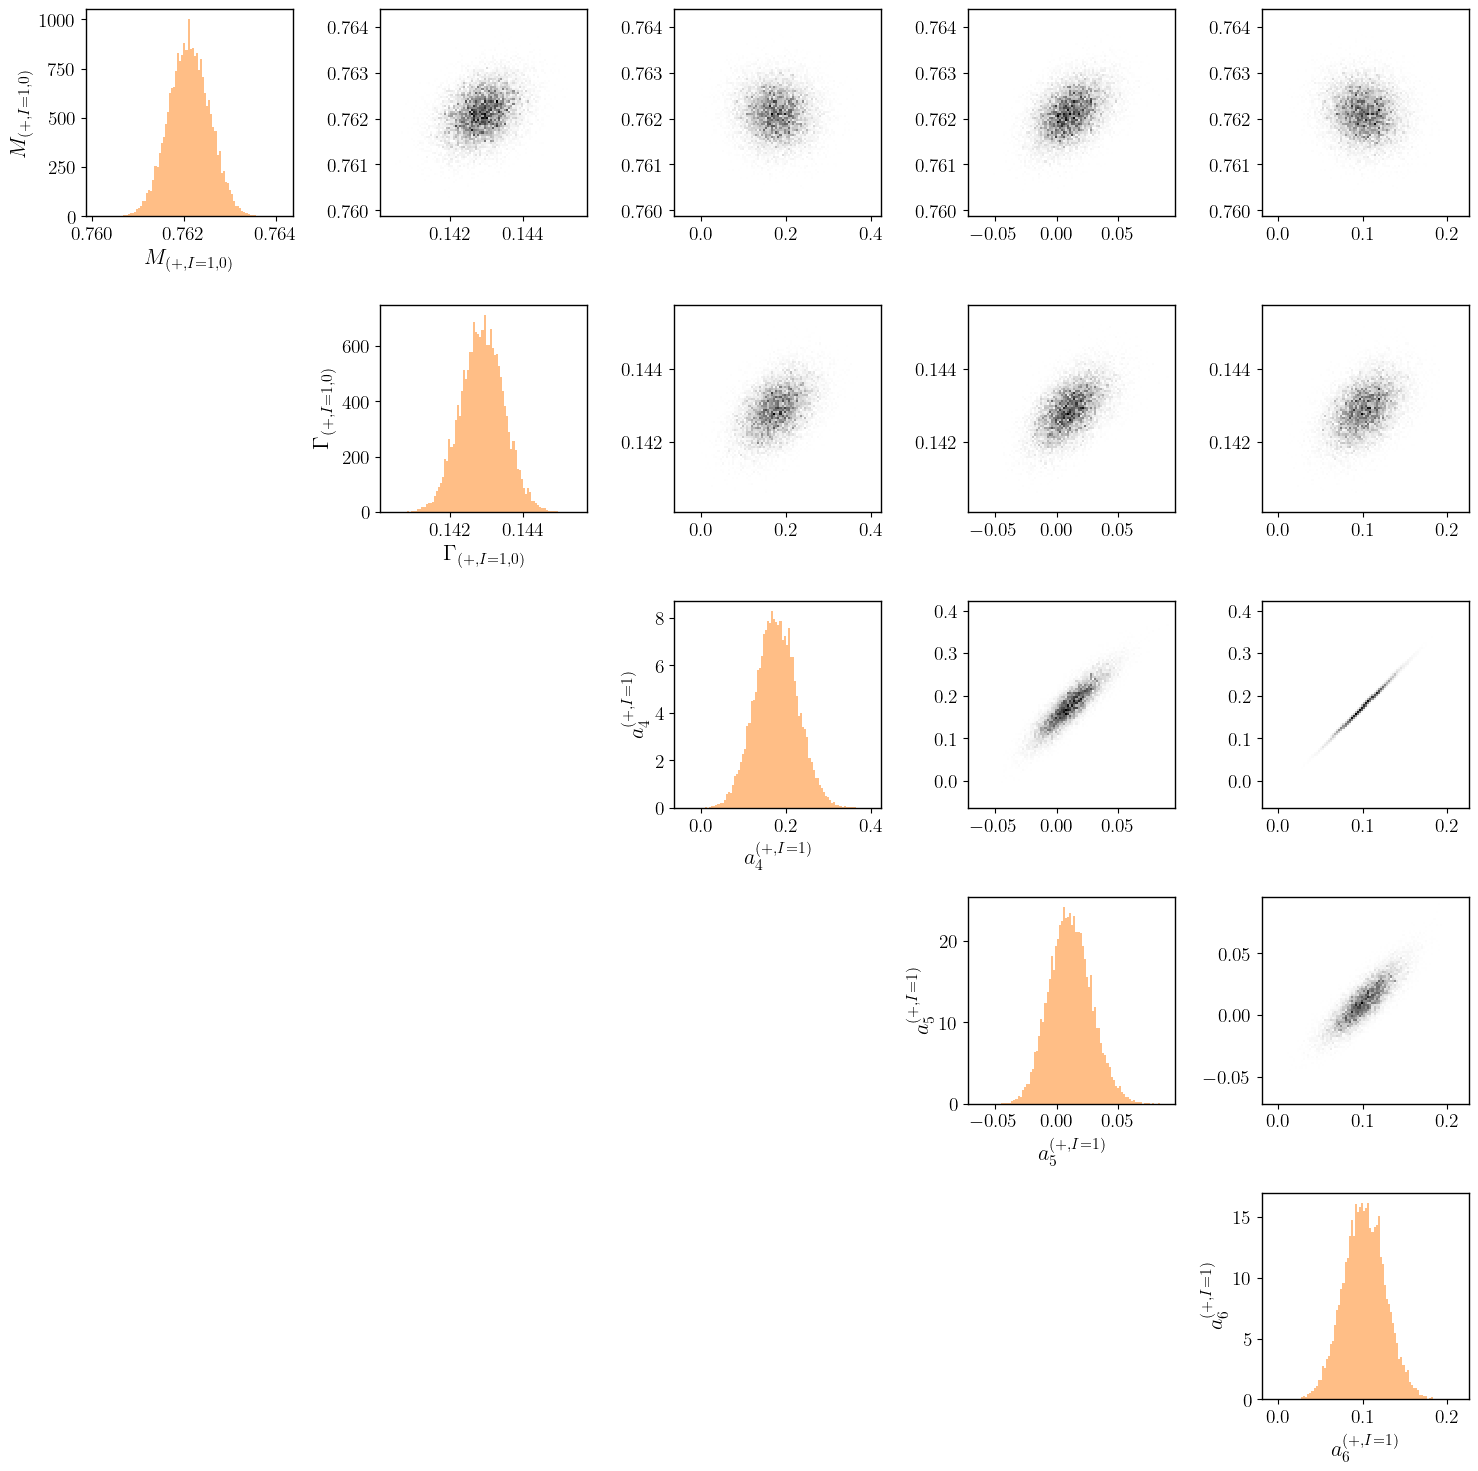

In [13]:
eos.tasks.corner_plot(af, posterior, base_directory=BASE_DIRECTORY)

In [87]:
print(f"rho mass  = {np.average(f.samples[:,0], weights=f.weights):.4f} ± {wstd(f.samples[:,0], weights=f.weights):.4f}")
print(f"rho width = {np.average(f.samples[:,1], weights=f.weights):.4f} ± {wstd(f.samples[:,1], weights=f.weights):.4f}")

rho mass  = 0.7621 ± 0.0004
rho width = 0.1429 ± 0.0006


Computing KDE for samples of variables '0->pipi::M_(+,1,0)@BHKMNR2026' and '0->pipi::Gamma_(+,1,0)@BHKMNR2026'


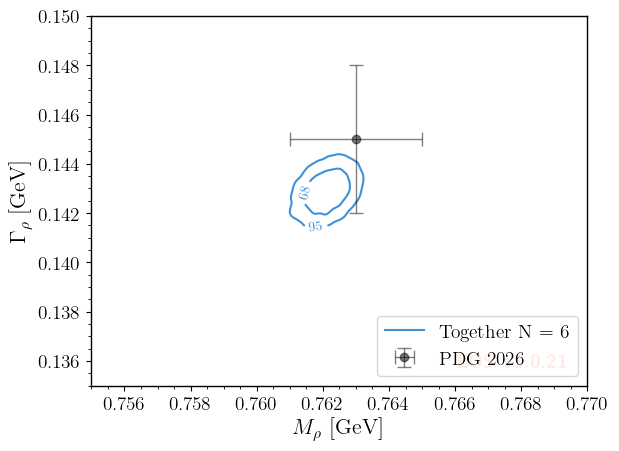

In [88]:
figure_args = {
'watermark': { 'position': 'lower right' },
'plot': {
    'xaxis': { 'label': r'$M_\rho$', 'unit': '$\\mathrm{GeV}$', 'range': [0.755, 0.77] },
    'yaxis': { 'label': r'$\Gamma_\rho$', 'unit': '$\\mathrm{GeV}$', 'range': [ 0.135, 0.15] },
    'legend': { 'position': 'lower right' },
    'items': [
    { 'type': 'kde2D', 'label': 'Together N = 6', 'color': colors[0],
      'levels': [68, 95], 'contours': ['lines', 'labels'],
      'datafile': 'data/'+posterior+'/samples',
      'variables': ['0->pipi::M_(+,1,0)@BHKMNR2026', '0->pipi::Gamma_(+,1,0)@BHKMNR2026']
    },
    {'type': 'errorbars', 'positions': [[0.763, 0.145]], 'xerrors': [0.002], 'yerrors': [0.003], 'label': 'PDG 2026', 'color': 'black'}
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

In [121]:
# Dispersive bound computation
eos.tasks.predict_observables(af, posterior, "FF-fp-I1-dispersive-bound", base_directory=BASE_DIRECTORY)
preds = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-FF-fp-I1-dispersive-bound'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order6-to…

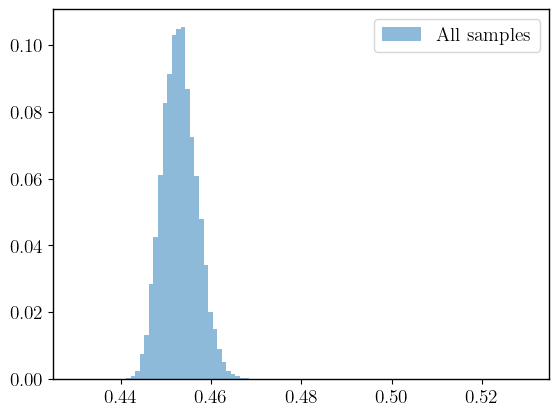

In [122]:
plt.hist(preds.samples, weights=preds.weights, bins=np.linspace(0.43,0.53,100), alpha=0.5, label='All samples')
plt.legend()
plt.show()

In [123]:
disp_values = np.array(preds.samples[:,0])
disp_mean   = np.average(disp_values, weights=preds.weights)
disp_std    = wstd(disp_values, weights=preds.weights)
print(f"Dispersive bound is {disp_mean:.4f} ± {disp_std:.4f}")

Dispersive bound is 0.4530 ± 0.0038


In [20]:
eos.tasks.predict_observables(af, posterior, "FF-fp2-I1-all", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order6-to…

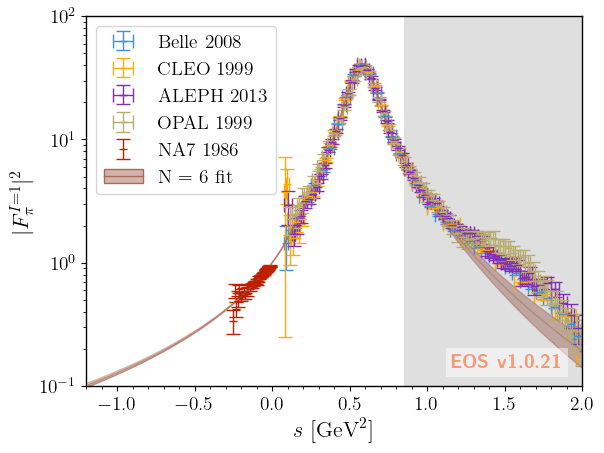

In [21]:
figure_args = {
'watermark': { 'position': 'lower right' },
'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [-1.2, 2.0] },
    'yaxis': { 'label': r'$|F^{I=1}_\pi|^2$', 'range': [ 0.1, 100.0], 'scale': 'log' },
    'legend': { 'position': 'upper left' },
    'items': [
    { 'type': 'constraint', 'label': 'Belle 2008', 'color': colors[0],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',
        'constraints': '0->pipi::Abs{f_+}^2@Belle:2008C',
    },
    { 'type': 'constraint', 'label': 'CLEO 1999', 'color': colors[1],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',
        'constraints': '0->pipi::Abs{f_+}^2@CLEO:2000B',
    },
    { 'type': 'constraint', 'label': 'ALEPH 2013', 'color': colors[4],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',
        'constraints': '0->pipi::Abs{f_+}^2@ALEPH:2013A',
    },
    { 'type': 'constraint', 'label': 'OPAL 1999', 'color': colors[7],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',
        'constraints': '0->pipi::Abs{f_+}^2@OPAL:1999A',
    },
    { 'type': 'constraint', 'label': 'NA7 1986', 'color': colors[2],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2)',
        'constraints': '0->pipi::Abs{f_+}^2@NA7:1986A',
    },
    { 'type': 'uncertainty', 'label': 'N = 6 fit', 'color': colors[5],
        'variable': 'q2', 'range': [-1.2, 2.0], 'interpolation': 'cubic',
        'datafile': 'data/'+posterior+'/pred-FF-fp2-I1-all', 'resolution': 300
    },
    { 'type': 'band', 'color': 'gray', 'alpha': 0.25, 'x': [sIn, 2.0], 'y': [0.0, 100]}
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

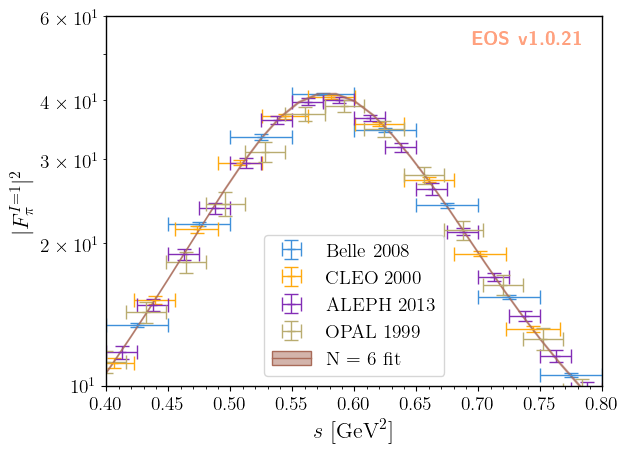

In [22]:
figure_args = {
'watermark': { 'position': 'upper right' },
'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [0.4, 0.8] },
    'yaxis': { 'label': r'$|F^{I=1}_\pi|^2$', 'range': [ 10.0, 60.0], 'scale': 'log' },
    'legend': { 'position': 'lower center' },
    'items': [
    { 'type': 'constraint', 'label': 'Belle 2008', 'color': colors[0],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',
        'constraints': '0->pipi::Abs{f_+}^2@Belle:2008C',
    },
    { 'type': 'constraint', 'label': 'CLEO 2000', 'color': colors[1],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',
        'constraints': '0->pipi::Abs{f_+}^2@CLEO:2000B',
    },
    { 'type': 'constraint', 'label': 'ALEPH 2013', 'color': colors[4],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',
        'constraints': '0->pipi::Abs{f_+}^2@ALEPH:2013A',
    },
    { 'type': 'constraint', 'label': 'OPAL 1999', 'color': colors[7],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',
        'constraints': '0->pipi::Abs{f_+}^2@OPAL:1999A',
    },
    { 'type': 'uncertainty', 'label': 'N = 6 fit', 'color': colors[5],
        'variable': 'q2', 'range': [-1.2, 2.0], 'interpolation': 'cubic',
        'datafile': 'data/'+posterior+'/pred-FF-fp2-I1-all', 'resolution': 300
    }
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

In [127]:
get_gof(analysis, start_point)
param_dict = {p.name(): p.evaluate() for p in analysis.parameters}

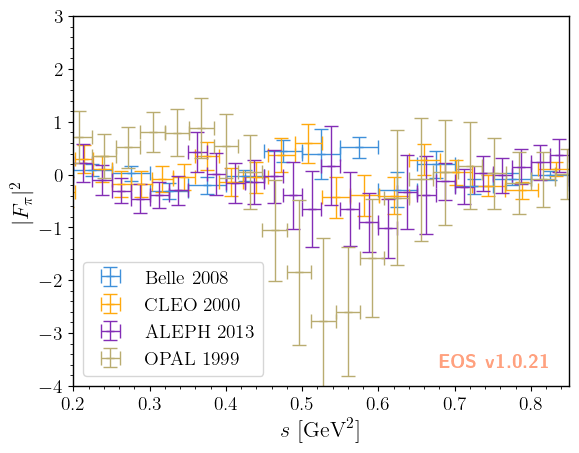

In [128]:
figure_args = {
'watermark': { 'position': 'lower right' },
'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [0.2, sIn] },
    'yaxis': { 'label': r'$|F_\pi|^2$', 'range': [ -4, 3], 'scale': 'linear' },
    'legend': { 'position': 'lower left' },
    'items': [
        { 'type': 'constraint-residue', 'label': 'Belle 2008', 'parameters': param_dict, 'options': {"form-factors": "BHKMNR2026"},
          'color': colors[0],  'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)', 'style': 'delta', 'constraints': '0->pipi::Abs{f_+}^2@Belle:2008C',
        },
        { 'type': 'constraint-residue', 'label': 'CLEO 2000', 'parameters': param_dict, 'options': {"form-factors": "BHKMNR2026"},
          'color': colors[1], 'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)', 'style': 'delta', 'constraints': '0->pipi::Abs{f_+}^2@CLEO:2000B',
        },
        { 'type': 'constraint-residue', 'label': 'ALEPH 2013', 'parameters': param_dict, 'options': {"form-factors": "BHKMNR2026"},
          'color': colors[4], 'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',  'style': 'delta', 'constraints': '0->pipi::Abs{f_+}^2@ALEPH:2013A',
        },
        { 'type': 'constraint-residue', 'label': 'OPAL 1999', 'parameters': param_dict, 'options': {"form-factors": "BHKMNR2026"},
          'color': colors[7], 'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)', 'style': 'delta', 'constraints': '0->pipi::Abs{f_+}^2@OPAL:1999A',
        }
        ]
        }
        }
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

In [129]:
eos.tasks.predict_observables(af, posterior, "FF-arg-fp-I1-timelike", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order6-to…

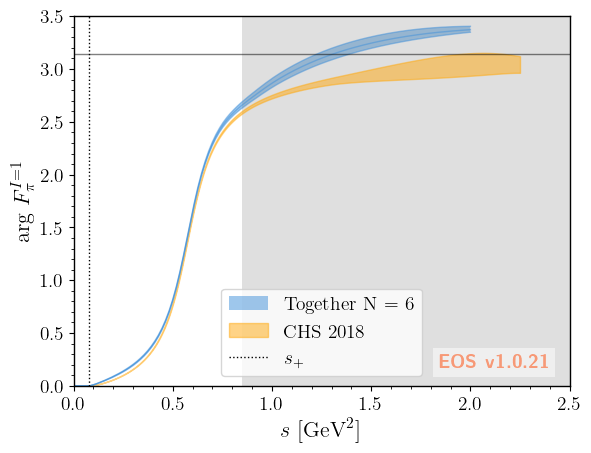

In [25]:
figure_args = {
  'watermark': { 'position': 'lower right' },
  'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [0.0, 2.5] },
    'yaxis': { 'label': r'arg $F^{I=1}_\pi$', 'range': [0.0 , 3.5] },
    'legend': { 'position': 'lower right' },
    'items': [
      { 'type': 'uncertainty', 'label': 'Together N = 6', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-FF-arg-fp-I1-timelike', 'color': colors[0]
      },
      { 'type': 'band', 'color': 'gray', 'alpha': 0.25, 'x': [sIn, 2.5], 'y': [0.0, 3.5]},
      { 'type': 'expression', 'expression': 'np.pi', 'range': [0, 2.5], 'color': 'k'}
    ]
  }
}

figure = eos.figure.FigureFactory.from_dict(**figure_args)

q2_over_mpisquared, phase, err = np.loadtxt("scripts/d11-central.txt", skiprows=1, unpack=True)
q2 = q2_over_mpisquared * mpi**2
figure.draw()

ax = figure._ax
ax.fill_between(q2, phase - err, phase + err, label="CHS 2018", alpha=0.5, color=colors[1])

ax.axvline(x=sPlus, color='k', linestyle=':', linewidth=1.0, label=r'$s_+$')

ax.legend(loc="lower center")

In [131]:
get_gof(analysis, start_point)
analysis.parameters.dump('data/'+posterior+'/mode-default/parameters.yaml')

Handling item to plot 0->pipi::Arg{f_+}(Re{psi},Im{psi})@BHKMNR2026 in the complex plane
Overriding parameters from file
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,2)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(0,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(0,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,2)@KSvD2025' with central value '0'
[parameters.override] Overriding existing p

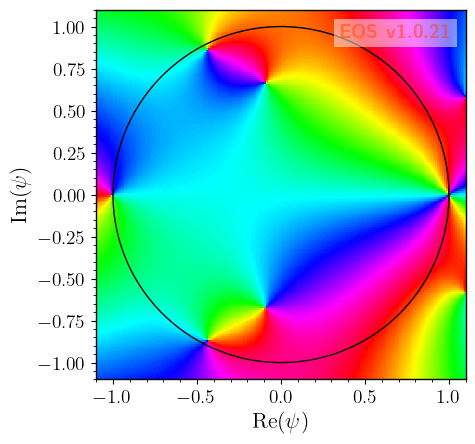

In [ ]:
figure_args = {
'plot': {
    'xaxis': { 'label': r'$\mathrm{Re}(\psi)$', 'range': [-1.1, 1.1] },
    'yaxis': { 'label': r'$\mathrm{Im}(\psi)$', 'range': [-1.1, 1.1] },
    # 'legend': { 'position': 'upper left' },
    'items': [
    { 'type': 'complex-plane', 'colormap': 'hsv', 'ranges': ((-1.1, +1.1), (-1.1, +1.1)),
        'variables': ["Re{psi}", "Im{psi}"], 'observable': "0->pipi::Arg{f_+}(Re{psi},Im{psi})@BHKMNR2026",
        'fixed_parameters_from_file': 'data/'+posterior+'/mode-default/parameters.yaml', 'resolution': 200
    }
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()
circle = plt.Circle((0, 0), 1.0, color='k', fill=False)
figure._ax.add_patch(circle)
figure._ax.set_aspect("equal", adjustable="box")


In [28]:
eos.tasks.predict_observables(af, posterior, "real-partial-wave-I1", base_directory=BASE_DIRECTORY)
eos.tasks.predict_observables(af, posterior, "imag-partial-wave-I1", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order6-to…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order6-to…

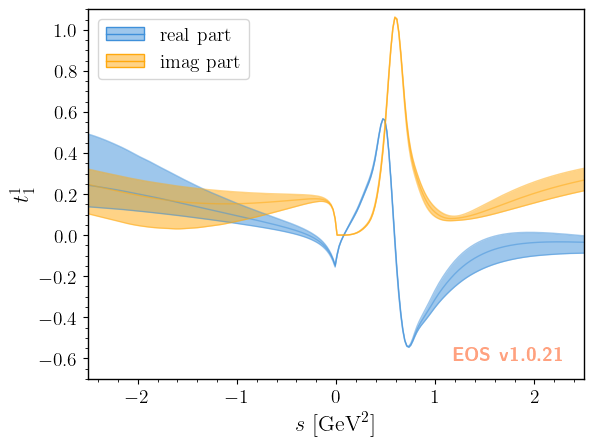

In [29]:
figure_args = {
  'watermark': { 'position': 'lower right' },
  'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [-2.5, 2.5] },
    'yaxis': { 'label': '$t_1^1$', 'range': [-0.7, 1.1]},
    'legend': { 'position': 'upper left' },
    'items': [
      { 'type': 'uncertainty', 'label': 'real part', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-real-partial-wave-I1'
      },
      { 'type': 'uncertainty', 'label': 'imag part', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-imag-partial-wave-I1'
      },
    ]
  }
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

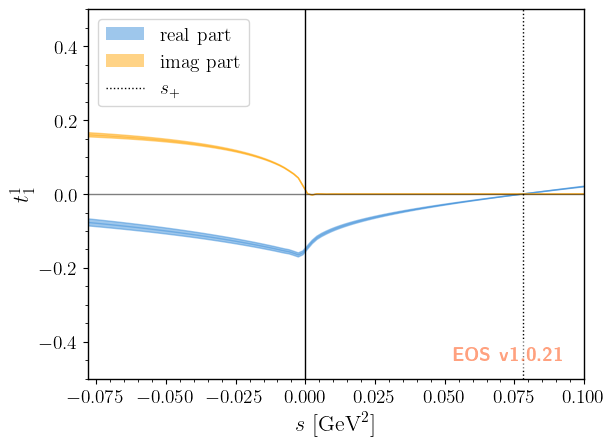

In [30]:
figure_args = {
  'watermark': { 'position': 'lower right' },
  'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [-sPlus, 0.1] },
    'yaxis': { 'label': '$t_1^1$', 'range': [-0.5, 0.5]},
    'legend': { 'position': 'upper left' },
    'items': [
      { 'type': 'uncertainty', 'label': 'real part', 'interpolation': 'cubic', 'resolution': 3000,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-real-partial-wave-I1'
      },
      { 'type': 'uncertainty', 'label': 'imag part', 'interpolation': 'cubic', 'resolution': 3000,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-imag-partial-wave-I1'
      },
      { 'type': 'expression', 'expression': '0', 'range': [-sPlus, 0.1], 'color': 'k'}
    ]
  }
}

figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()
ax = figure._ax
ax.axvline( x=0.0, color='k', linewidth=1.0)
ax.axvline( x=sPlus, color='k', linestyle=':', linewidth=1.0, label=r'$s_+$')
ax.legend(loc='upper left')

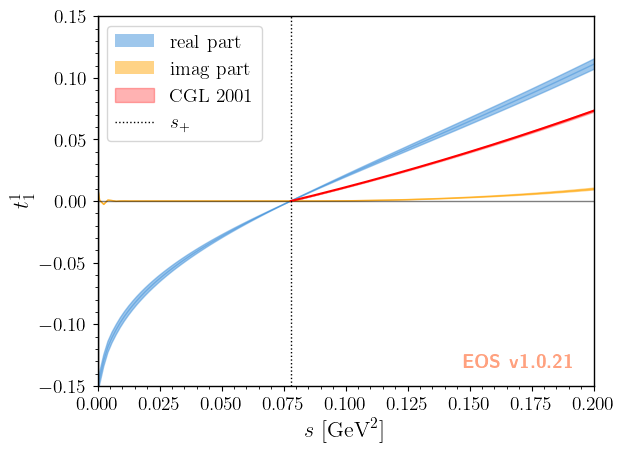

In [45]:
with np.load(theory_path) as saved:
    s_theory = saved['s']
    t_theory_samples = saved['t11']

# Calculate the band; the theory samples have equal weights.
t_lower, t_median, t_upper = np.quantile(
    t_theory_samples,
    [0.15865, 0.5, 0.84135],
    axis=0
)


figure_args = {
  'watermark': { 'position': 'lower right' },
  'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [0, 0.2] },
    'yaxis': { 'label': '$t_1^1$', 'range': [-0.15, 0.15]},
    'legend': { 'position': 'upper left' },
    'items': [
      { 'type': 'uncertainty', 'label': 'real part', 'interpolation': 'cubic', 'resolution': 3000,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-real-partial-wave-I1'
      },
      { 'type': 'uncertainty', 'label': 'imag part', 'interpolation': 'cubic', 'resolution': 3000,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-imag-partial-wave-I1'
      },
      { 'type': 'expression', 'expression': '0', 'range': [0, 0.2], 'color': 'k'}
    ]
  }
}

figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()
ax = figure._ax
# Add the theory band and median to the same axes.
ax.fill_between(
    s_theory,
    t_lower,
    t_upper,
    color='red',
    alpha=0.3,
    label='CGL 2001'
)

ax.plot(
    s_theory,
    t_median,
    color='red',
    linewidth=1.5
)

ax.axvline(x=0.0, color='k', linewidth=1.0)
ax.axvline(
    x=sPlus,
    color='k',
    linestyle=':',
    linewidth=1.0,
    label=r'$s_+$'
)

# Include the theory band and reference line in the legend.
ax.legend(loc='upper left')

In [154]:
# Analytic value of a11 and b11
eos.tasks.predict_observables(af, posterior, "FF-fp-I1-scattering-length-params", base_directory=BASE_DIRECTORY)
sl_params = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-FF-fp-I1-scattering-length-params'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order6-to…

In [155]:
a11_values, b11_values = calculate_sl_values(sl_params)
(a11_mean, a11_std, b11_mean, b11_std) = summarize_sl_values("Together N =6", a11_values, b11_values, sl_params.weights)

Together N =6 a11 = 0.0741 ± 0.0033
Together N =6 b11 = -0.0094 ± 0.0009


In [156]:
sl_samples_path = save_sl_samples(posterior, a11_values, b11_values, sl_params.weights)

Computing KDE for samples of variables 'derived::a11' and 'derived::b11'


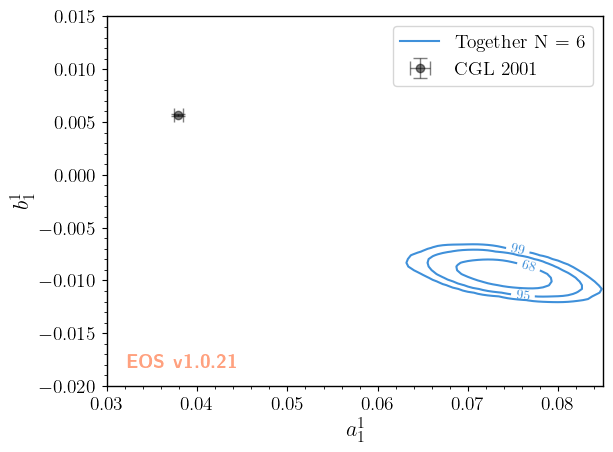

In [157]:
xrange = [0.03, 0.085]
yrange = [-0.02, 0.015]

figure_args = {
'watermark': { 'position': 'lower left' },
'plot': {
    'xaxis': { 'label': r'$a_1^1$', 'range': xrange },
    'yaxis': { 'label': r'$b_1^1$', 'range': yrange },
    'legend': { 'position': 'upper right' },
    'items': [
    { 'type': 'kde2D', 'label': 'Together N = 6', 'color': colors[0],
      'levels': [68, 95, 99], 'contours': ['lines', 'labels'], 'bandwidth': 1.5,
      'datafile': sl_samples_path, 'xrange': xrange, 'yrange': yrange,
      'variables': ['derived::a11', 'derived::b11']
    },
    {'type': 'errorbars', 'positions': [[0.0379, 0.00567]], 'xerrors': [0.0005], 'yerrors': [0.00013], 'label': 'CGL 2001', 'color': 'black'}
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

In [139]:
# Charge radius
eos.tasks.predict_observables(af, posterior, "FF-fp-I1-pion-charge-radius-param", base_directory=BASE_DIRECTORY)
fprime_values = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-FF-fp-I1-pion-charge-radius-param'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order6-to…

In [140]:
charge_radius_squared_values = np.array(list(map(charge_radius_squared_calculator, fprime_values.samples[:, 0])))
radius_mean = np.average(charge_radius_squared_values, weights=fprime_values.weights)
radius_std  = wstd(charge_radius_squared_values, weights=fprime_values.weights)
print(f"<r^2> = {radius_mean:.4f} ± {radius_std:.4f} fm^2")

<r^2> = 0.4350 ± 0.0040 fm^2


In [18]:
# Residue at the rho pole
eos.tasks.predict_observables(af, posterior, "re-rho-residue-psi", base_directory=BASE_DIRECTORY)
re_res_psi = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-re-rho-residue-psi'))
eos.tasks.predict_observables(af, posterior, "im-rho-residue-psi", base_directory=BASE_DIRECTORY)
im_res_psi = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-im-rho-residue-psi'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order6-to…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order6-to…

In [19]:
re_res = re_res_psi.samples[:,0]
im_res = im_res_psi.samples[:,0]
M      = f.samples[:,0]
Gamma  = f.samples[:,1]

print(len(re_res), len(im_res), len(M), len(Gamma)) # check that they have the same length

13746 13746 13746 13746


In [123]:
data = []

for r, i, m, g in zip(re_res, im_res, M, Gamma):
    data.append([r, i, m, g])
with open("residues_psi_together6.wl", "w") as file:
    lines = [f"{{{r}, {i}, {m}, {g}}}" for r, i, m, g in data]
    file.write("{\n" + ",\n".join(lines) + "\n}")

In [21]:
data = np.loadtxt("residues_s_together6.csv", delimiter=",", ndmin=2,)

res_s = data[:, 0] + 1j * data[:, 1]

# Weighted complex mean
res_s_mean = np.average(res_s, weights=f.weights)

# Weighted standard deviations of the real and imaginary parts
std_re = np.sqrt(np.average((res_s.real - res_s_mean.real)**2, weights=f.weights))
std_im = np.sqrt(np.average((res_s.imag - res_s_mean.imag)**2, weights=f.weights))

print(
    f"residue at s_rho is "
    f"({res_s_mean.real:.4f} ± {std_re:.4f}) "
    f"+ i * ({res_s_mean.imag:.4f} ± {std_im:.4f})"
)

residue at s_rho is (-0.6978 ± 0.0075) + i * (0.1174 ± 0.0104)


In [22]:
# Computing g_{rho pi pi} and g_{rho gamma}
f_at_s_rho       = np.array([get_f_rho(s, analysis) for s in f.samples])
f_at_s_rho_value = f_at_s_rho[:,0] + 1j * f_at_s_rho[:,1]

In [23]:
s_rho       = (M - 1j * Gamma / 2)**2
g_rho_gamma = np.sqrt(24j * np.pi * s_rho / f_at_s_rho_value / res_s / (np.sqrt(1 - sPlus / s_rho))**3)
g_rho_pi_pi = (- res_s / s_rho) * g_rho_gamma

In [24]:
g_rho_gamma_mean = np.average(g_rho_gamma, weights=f.weights)
g_rho_gamma_std  = wstd(g_rho_gamma, weights=f.weights)
print(f"g_rho_gamma =  ({np.real(g_rho_gamma_mean):.4f} ± {np.real(g_rho_gamma_std):.4f}) + i * ({np.imag(g_rho_gamma_mean):.4f} ± {np.imag(g_rho_gamma_std):.4f})")

g_rho_pi_pi_mean = np.average(g_rho_pi_pi, weights=f.weights)
g_rho_pi_pi_std  = wstd(g_rho_pi_pi, weights=f.weights)
print(f"g_rho_pi_pi =  ({np.real(g_rho_pi_pi_mean):.4f} ± {np.real(g_rho_pi_pi_std):.4f}) + i * ({np.imag(g_rho_pi_pi_mean):.4f} ± {np.imag(g_rho_pi_pi_std):.4f})")

g_rho_gamma =  (4.9235 ± 0.0034) + i * (-0.2379 ± 0.0082)
g_rho_pi_pi =  (5.9504 ± 0.0330) + i * (-0.1673 ± 0.0802)


In [118]:
eos.tasks.predict_observables(af, posterior, "a_0", base_directory=BASE_DIRECTORY)
eos.tasks.predict_observables(af, posterior, "a_1", base_directory=BASE_DIRECTORY)
eos.tasks.predict_observables(af, posterior, "a_2", base_directory=BASE_DIRECTORY)
eos.tasks.predict_observables(af, posterior, "a_3", base_directory=BASE_DIRECTORY)

a0 = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-a_0'))
a1 = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-a_1'))
a2 = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-a_2'))
a3 = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-a_3'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order6-to…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order6-to…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order6-to…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order6-to…

In [119]:
all_coefs = np.column_stack([a0.samples, a1.samples, a2.samples, a3.samples,
                                                     f.samples[:,2], f.samples[:,3], f.samples[:,4]])
np.shape(all_coefs)

(13746, 7)

In [120]:
# Compute weighted median and asymmetric 1-sigma intervals for each coefficient
n_coefs = all_coefs.shape[1]
labels = [f'$a_{i}$' for i in range(n_coefs)]

medians   = np.array([quantile_1D(all_coefs[:,i], f.weights, 0.50) for i in range(n_coefs)])
lo_1sigma = np.array([quantile_1D(all_coefs[:,i], f.weights, 0.16) for i in range(n_coefs)])
hi_1sigma = np.array([quantile_1D(all_coefs[:,i], f.weights, 0.84) for i in range(n_coefs)])

err_low  = medians - lo_1sigma   # downward bar length
err_high = hi_1sigma - medians   # upward bar length


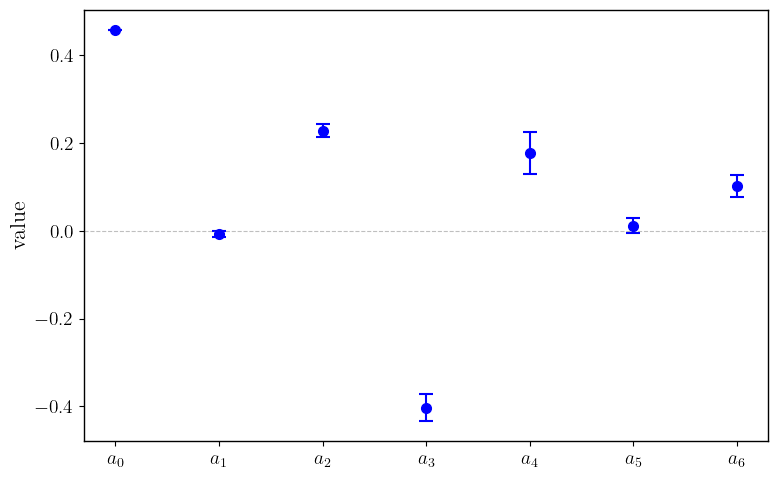

In [144]:
fig, ax = plt.subplots(figsize=(8, 5))
xs = np.arange(n_coefs)

ax.errorbar(xs, medians,
            yerr=[err_low, err_high],
            fmt='o', capsize=5, capthick=1.5, elinewidth=1.5,
            markersize=7, color='b', ecolor='b')

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xticks(xs)
ax.set_xticklabels(labels)
ax.set_ylabel('value')
plt.tight_layout()
plt.show()

## order 6  without Belle

In [26]:
posterior = 'FF-fp-I1-order6-without-Belle'
analysis  = af.analysis(posterior)

Creating analysis with 5 priors, 4 EOS-wide constraints, 2 global options, 2 manually-entered constraints and 2 fixed parameters.
likelihood probably depends on 21 parameter(s) that do not appear in the prior; check prior?


In [23]:
start_point = [0.76137161,  0.14299097,  0.06632224, -0.03039141,  0.04833503]

In [24]:
get_gof(analysis, start_point)

In [24]:
#bfp, gof = eos.tasks.find_mode(af, posterior, start_point=start_point, base_directory=BASE_DIRECTORY, optimizations=100)
bfp, gof = eos.tasks.find_mode(af, posterior, importance_samples=True, base_directory=BASE_DIRECTORY, optimizations=100)
display(gof)
bfp.point

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order6-wi…

array([ 0.76137161,  0.14299097,  0.06632224, -0.03039141,  0.04833503])

In [27]:
if resample:
    eos.tasks.sample_nested(af, posterior, base_directory=BASE_DIRECTORY, bound='multi', nlive=200)

f = eos.data.ImportanceSamples(os.path.join(BASE_DIRECTORY, 'data', posterior, 'samples'))
print(f"Collected {f.samples.shape[0]} samples") #log z = 98.42

Collected 14741 samples


In [26]:
for i, p in enumerate(analysis.varied_parameters):
    mean = np.average(f.samples[:,i], weights=f.weights)
    std  = wstd(f.samples[:,i], weights=f.weights)
    print(f"      - {{ 'parameter': '{p.name()}', 'min':  {mean - 5*std:.5f}, 'max':  {mean + 5*std:.5f}, 'type': 'uniform'}}")

      - { 'parameter': '0->pipi::M_(+,1,0)@BHKMNR2026', 'min':  0.75827, 'max':  0.76450, 'type': 'uniform'}
      - { 'parameter': '0->pipi::Gamma_(+,1,0)@BHKMNR2026', 'min':  0.13884, 'max':  0.15033, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^4@BHKMNR2026', 'min':  -0.20011, 'max':  0.39996, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^5@BHKMNR2026', 'min':  -0.13206, 'max':  0.09750, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^6@BHKMNR2026', 'min':  -0.08378, 'max':  0.21651, 'type': 'uniform'}


Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order6-wi…

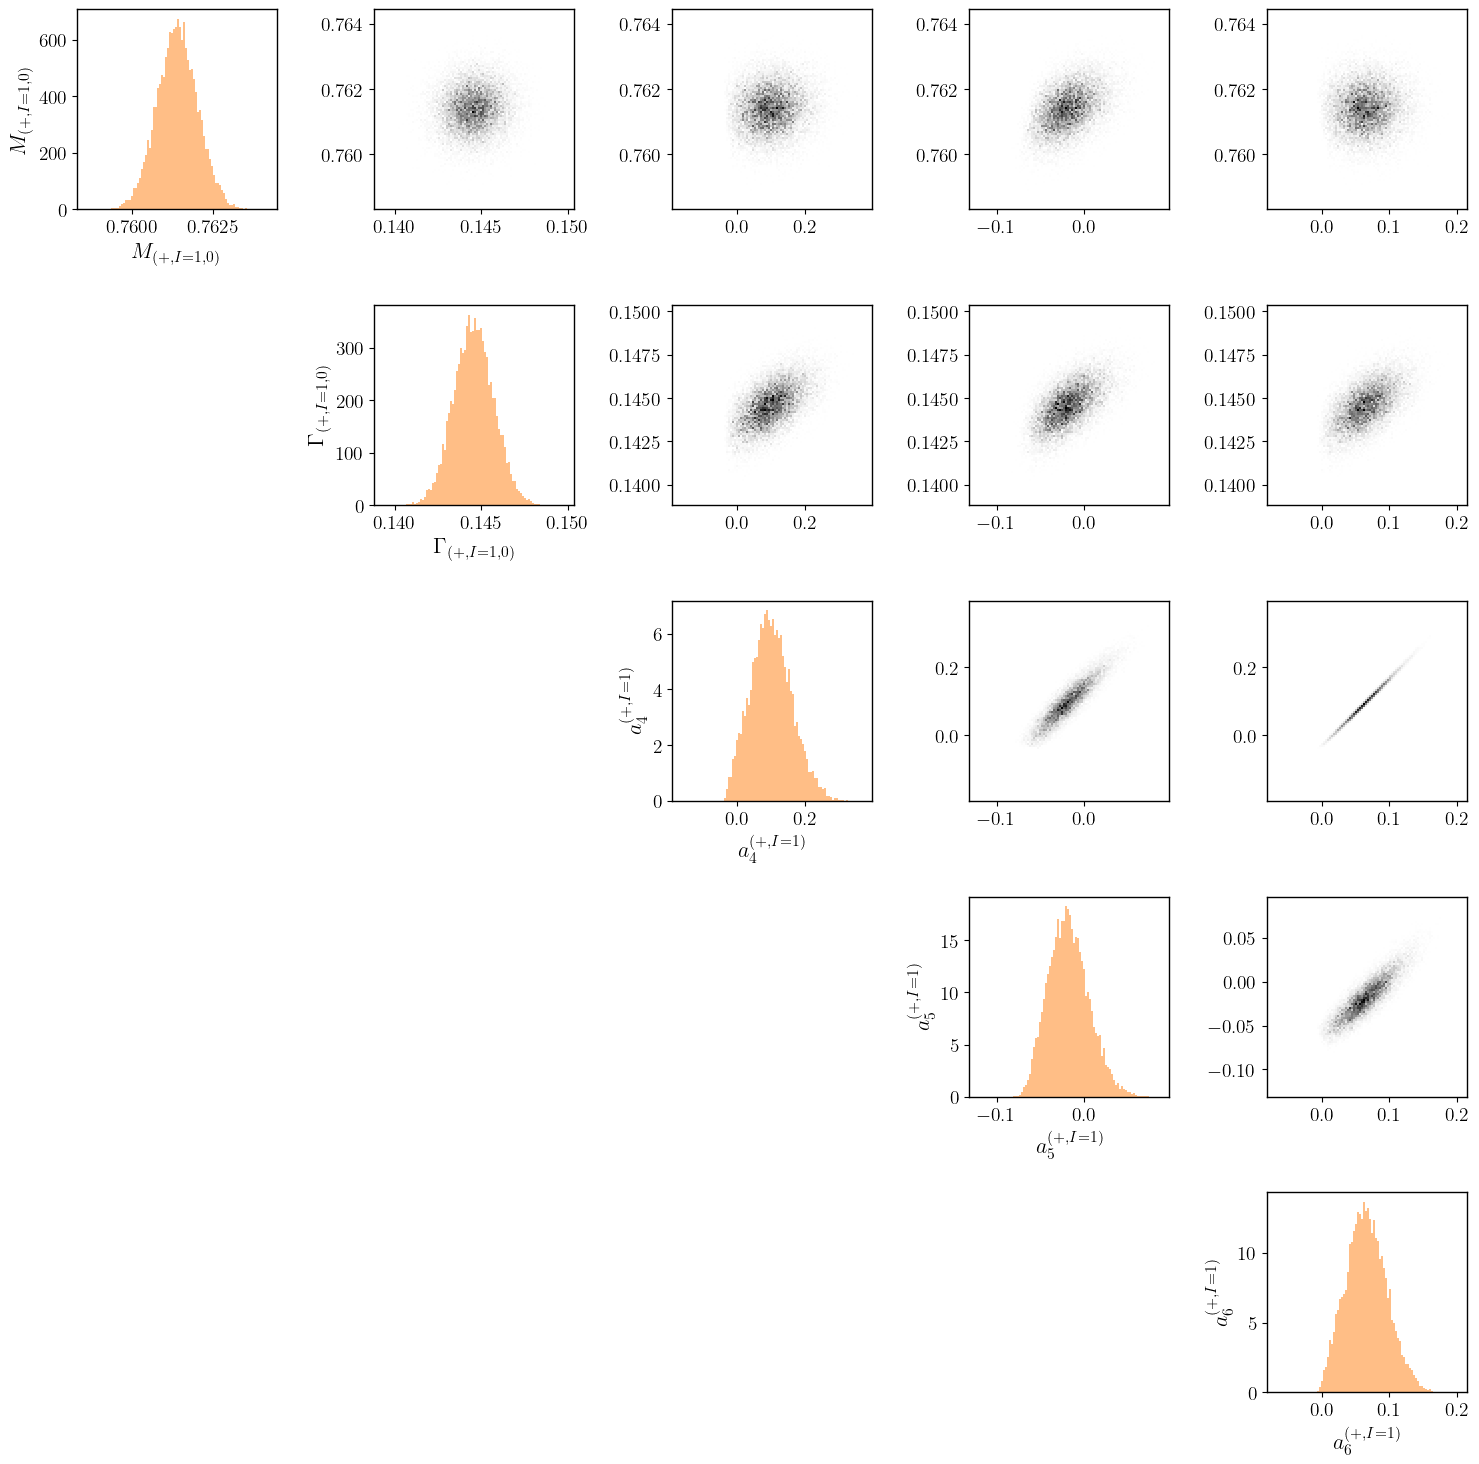

In [27]:
eos.tasks.corner_plot(af, posterior, base_directory=BASE_DIRECTORY)

In [39]:
print(f"rho mass  = {np.average(f.samples[:,0], weights=f.weights):.4f} ± {wstd(f.samples[:,0], weights=f.weights):.4f}")
print(f"rho width = {np.average(f.samples[:,1], weights=f.weights):.4f} ± {wstd(f.samples[:,1], weights=f.weights):.4f}")

rho mass  = 0.7614 ± 0.0006
rho width = 0.1446 ± 0.0011


Computing KDE for samples of variables '0->pipi::M_(+,1,0)@BHKMNR2026' and '0->pipi::Gamma_(+,1,0)@BHKMNR2026'


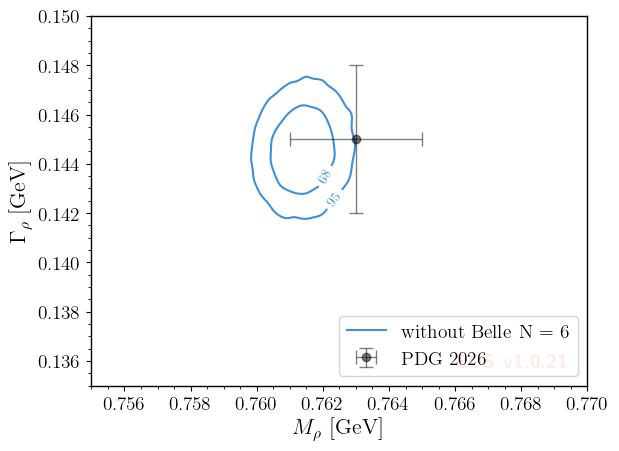

In [40]:
figure_args = {
'watermark': { 'position': 'lower right' },
'plot': {
    'xaxis': { 'label': r'$M_\rho$', 'unit': '$\\mathrm{GeV}$', 'range': [0.755, 0.77] },
    'yaxis': { 'label': r'$\Gamma_\rho$', 'unit': '$\\mathrm{GeV}$', 'range': [ 0.135, 0.15] },
    'legend': { 'position': 'lower right' },
    'items': [
    { 'type': 'kde2D', 'label': 'without Belle N = 6', 'color': colors[0],
      'levels': [68, 95], 'contours': ['lines', 'labels'],
      'datafile': 'data/'+posterior+'/samples',
      'variables': ['0->pipi::M_(+,1,0)@BHKMNR2026', '0->pipi::Gamma_(+,1,0)@BHKMNR2026']
    },
    {'type': 'errorbars', 'positions': [[0.763, 0.145]], 'xerrors': [0.002], 'yerrors': [0.003], 'label': 'PDG 2026', 'color': 'black'}
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

In [31]:
# Dispersive bound computation
eos.tasks.predict_observables(af, posterior, "FF-fp-I1-dispersive-bound", base_directory=BASE_DIRECTORY)
preds = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-FF-fp-I1-dispersive-bound'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order6-wi…

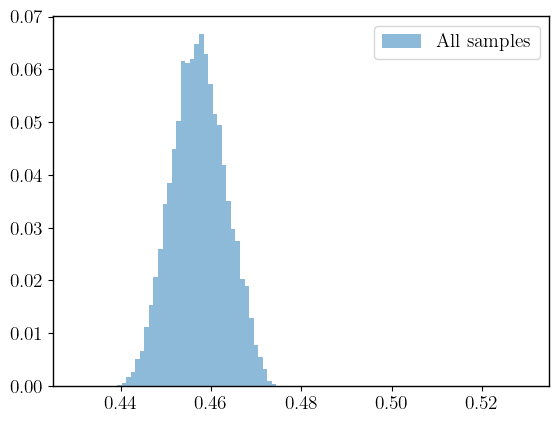

In [32]:
plt.hist(preds.samples, weights=preds.weights, bins=np.linspace(0.43,0.53,100), alpha=0.5, label='All samples')
plt.legend()
plt.show()

In [33]:
disp_values = np.array(preds.samples[:,0])
disp_mean   = np.average(disp_values, weights=preds.weights)
disp_std    = wstd(disp_values, weights=preds.weights)
print(f"Dispersive bound is {disp_mean:.4f} ± {disp_std:.4f}")

Dispersive bound is 0.4572 ± 0.0059


In [57]:
eos.tasks.predict_observables(af, posterior, "FF-fp2-I1-all", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order6-wi…

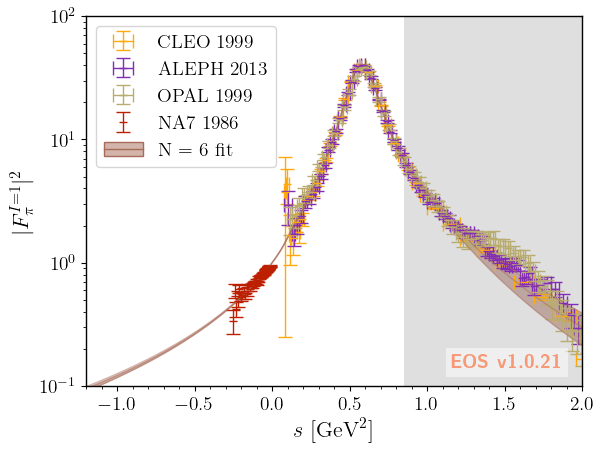

In [58]:
figure_args = {
'watermark': { 'position': 'lower right' },
'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [-1.2, 2.0] },
    'yaxis': { 'label': r'$|F^{I=1}_\pi|^2$', 'range': [ 0.1, 100.0], 'scale': 'log' },
    'legend': { 'position': 'upper left' },
    'items': [
    { 'type': 'constraint', 'label': 'CLEO 1999', 'color': colors[1],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',
        'constraints': '0->pipi::Abs{f_+}^2@CLEO:2000B',
    },
    { 'type': 'constraint', 'label': 'ALEPH 2013', 'color': colors[4],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',
        'constraints': '0->pipi::Abs{f_+}^2@ALEPH:2013A',
    },
    { 'type': 'constraint', 'label': 'OPAL 1999', 'color': colors[7],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',
        'constraints': '0->pipi::Abs{f_+}^2@OPAL:1999A',
    },
    { 'type': 'constraint', 'label': 'NA7 1986', 'color': colors[2],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2)',
        'constraints': '0->pipi::Abs{f_+}^2@NA7:1986A',
    },
    { 'type': 'uncertainty', 'label': 'N = 6 fit', 'color': colors[5],
        'variable': 'q2', 'range': [-1.2, 2.0], 'interpolation': 'cubic',
        'datafile': 'data/'+posterior+'/pred-FF-fp2-I1-all', 'resolution': 300
    },
    { 'type': 'band', 'color': 'gray', 'alpha': 0.25, 'x': [sIn, 2.0], 'y': [0.0, 100]}
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

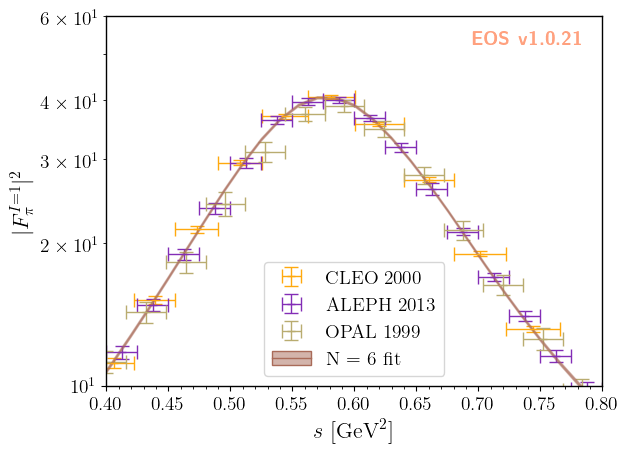

In [59]:
figure_args = {
'watermark': { 'position': 'upper right' },
'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [0.4, 0.8] },
    'yaxis': { 'label': r'$|F^{I=1}_\pi|^2$', 'range': [ 10.0, 60.0], 'scale': 'log' },
    'legend': { 'position': 'lower center' },
    'items': [
    { 'type': 'constraint', 'label': 'CLEO 2000', 'color': colors[1],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',
        'constraints': '0->pipi::Abs{f_+}^2@CLEO:2000B',
    },
    { 'type': 'constraint', 'label': 'ALEPH 2013', 'color': colors[4],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',
        'constraints': '0->pipi::Abs{f_+}^2@ALEPH:2013A',
    },
    { 'type': 'constraint', 'label': 'OPAL 1999', 'color': colors[7],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',
        'constraints': '0->pipi::Abs{f_+}^2@OPAL:1999A',
    },
    { 'type': 'uncertainty', 'label': 'N = 6 fit', 'color': colors[5],
        'variable': 'q2', 'range': [-1.2, 2.0], 'interpolation': 'cubic',
        'datafile': 'data/'+posterior+'/pred-FF-fp2-I1-all', 'resolution': 300
    }
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

In [40]:
get_gof(analysis, start_point)
param_dict = {p.name(): p.evaluate() for p in analysis.parameters}

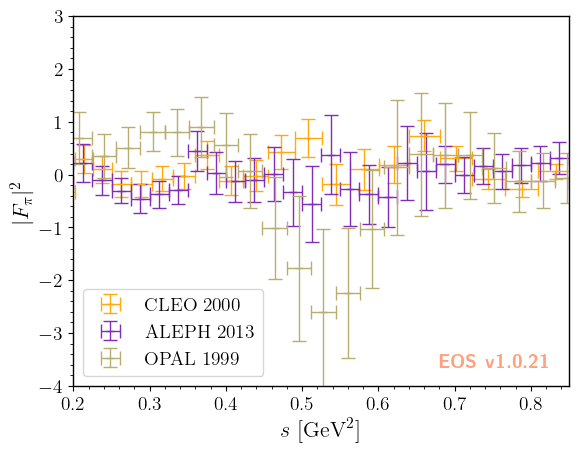

In [41]:
figure_args = {
'watermark': { 'position': 'lower right' },
'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [0.2, sIn] },
    'yaxis': { 'label': r'$|F_\pi|^2$', 'range': [ -4, 3], 'scale': 'linear' },
    'legend': { 'position': 'lower left' },
    'items': [
        { 'type': 'constraint-residue', 'label': 'CLEO 2000', 'parameters': param_dict, 'options': {"form-factors": "BHKMNR2026"},
          'color': colors[1], 'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)', 'style': 'delta', 'constraints': '0->pipi::Abs{f_+}^2@CLEO:2000B',
        },
        { 'type': 'constraint-residue', 'label': 'ALEPH 2013', 'parameters': param_dict, 'options': {"form-factors": "BHKMNR2026"},
          'color': colors[4], 'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',  'style': 'delta', 'constraints': '0->pipi::Abs{f_+}^2@ALEPH:2013A',
        },
        { 'type': 'constraint-residue', 'label': 'OPAL 1999', 'parameters': param_dict, 'options': {"form-factors": "BHKMNR2026"},
          'color': colors[7], 'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)', 'style': 'delta', 'constraints': '0->pipi::Abs{f_+}^2@OPAL:1999A',
        }
        ]
        }
        }
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

In [42]:
eos.tasks.predict_observables(af, posterior, "FF-arg-fp-I1-timelike", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order6-wi…

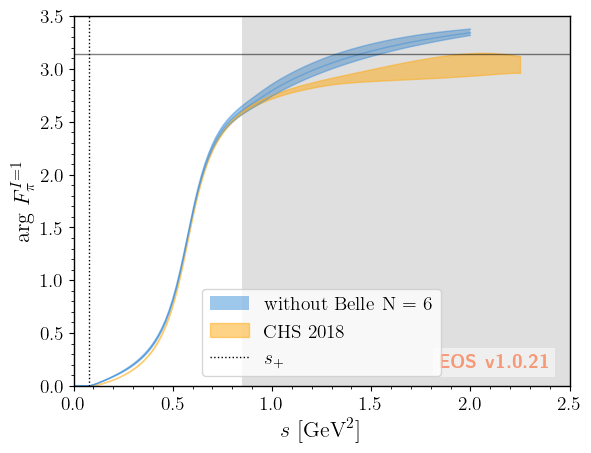

In [29]:
figure_args = {
  'watermark': { 'position': 'lower right' },
  'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [0.0, 2.5] },
    'yaxis': { 'label': r'arg $F^{I=1}_\pi$', 'range': [0.0 , 3.5] },
    'legend': { 'position': 'lower right' },
    'items': [
      { 'type': 'uncertainty', 'label': 'without Belle N = 6', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-FF-arg-fp-I1-timelike', 'color': colors[0]
      },
      { 'type': 'band', 'color': 'gray', 'alpha': 0.25, 'x': [sIn, 2.5], 'y': [0.0, 3.5]},
      { 'type': 'expression', 'expression': 'np.pi', 'range': [0, 2.5], 'color': 'k'}
    ]
  }
}

figure = eos.figure.FigureFactory.from_dict(**figure_args)

q2_over_mpisquared, phase, err = np.loadtxt("scripts/d11-central.txt", skiprows=1, unpack=True)
q2 = q2_over_mpisquared * mpi**2
figure.draw()

ax = figure._ax
ax.fill_between(q2, phase - err, phase + err, label="CHS 2018", alpha=0.5, color=colors[1])

ax.axvline(x=sPlus, color='k', linestyle=':', linewidth=1.0, label=r'$s_+$')

ax.legend(loc="lower center")

In [44]:
get_gof(analysis, start_point)
analysis.parameters.dump('data/'+posterior+'/mode-default/parameters.yaml')

Handling item to plot 0->pipi::Arg{f_+}(Re{psi},Im{psi})@BHKMNR2026 in the complex plane
Overriding parameters from file
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,2)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(0,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(0,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,2)@KSvD2025' with central value '0'
[parameters.override] Overriding existing p

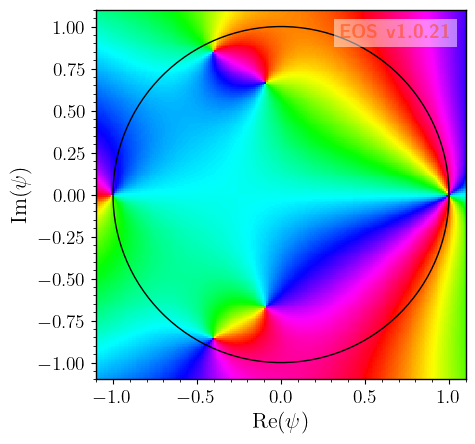

In [ ]:
figure_args = {
'plot': {
    'xaxis': { 'label': r'$\mathrm{Re}(\psi)$', 'range': [-1.1, 1.1] },
    'yaxis': { 'label': r'$\mathrm{Im}(\psi)$', 'range': [-1.1, 1.1] },
    # 'legend': { 'position': 'upper left' },
    'items': [
    { 'type': 'complex-plane', 'colormap': 'hsv', 'ranges': ((-1.1, +1.1), (-1.1, +1.1)),
        'variables': ["Re{psi}", "Im{psi}"], 'observable': "0->pipi::Arg{f_+}(Re{psi},Im{psi})@BHKMNR2026",
        'fixed_parameters_from_file': 'data/'+posterior+'/mode-default/parameters.yaml', 'resolution': 200
    }
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()
circle = plt.Circle((0, 0), 1.0, color='k', fill=False)
figure._ax.add_patch(circle)
figure._ax.set_aspect("equal", adjustable="box")


In [60]:
eos.tasks.predict_observables(af, posterior, "real-partial-wave-I1", base_directory=BASE_DIRECTORY)
eos.tasks.predict_observables(af, posterior, "imag-partial-wave-I1", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order6-wi…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order6-wi…

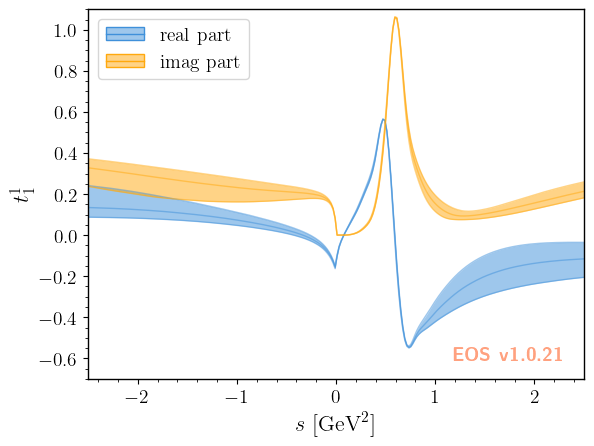

In [61]:
figure_args = {
  'watermark': { 'position': 'lower right' },
  'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [-2.5, 2.5] },
    'yaxis': { 'label': '$t_1^1$', 'range': [-0.7, 1.1]},
    'legend': { 'position': 'upper left' },
    'items': [
      { 'type': 'uncertainty', 'label': 'real part', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-real-partial-wave-I1'
      },
      { 'type': 'uncertainty', 'label': 'imag part', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-imag-partial-wave-I1'
      },
    ]
  }
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

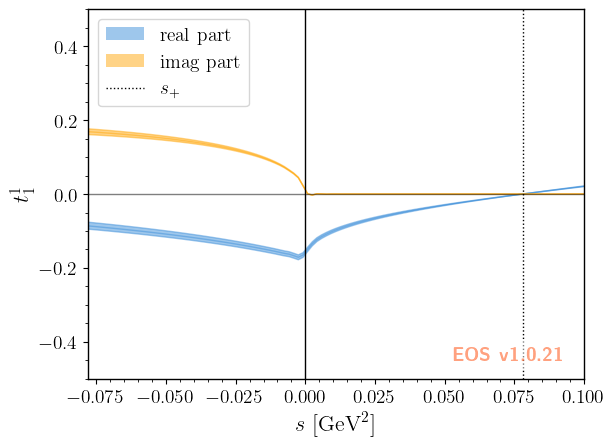

In [62]:
figure_args = {
  'watermark': { 'position': 'lower right' },
  'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [-sPlus, 0.1] },
    'yaxis': { 'label': '$t_1^1$', 'range': [-0.5, 0.5]},
    'legend': { 'position': 'upper left' },
    'items': [
      { 'type': 'uncertainty', 'label': 'real part', 'interpolation': 'cubic', 'resolution': 3000,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-real-partial-wave-I1'
      },
      { 'type': 'uncertainty', 'label': 'imag part', 'interpolation': 'cubic', 'resolution': 3000,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-imag-partial-wave-I1'
      },
      { 'type': 'expression', 'expression': '0', 'range': [-sPlus, 0.1], 'color': 'k'}
    ]
  }
}

figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()
ax = figure._ax
ax.axvline( x=0.0, color='k', linewidth=1.0)
ax.axvline( x=sPlus, color='k', linestyle=':', linewidth=1.0, label=r'$s_+$')
ax.legend(loc='upper left')

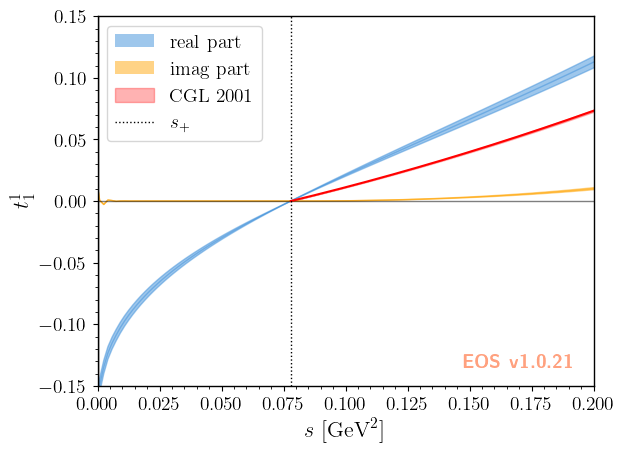

In [64]:
with np.load(theory_path) as saved:
    s_theory = saved['s']
    t_theory_samples = saved['t11']

# Calculate the band; the theory samples have equal weights.
t_lower, t_median, t_upper = np.quantile(
    t_theory_samples,
    [0.15865, 0.5, 0.84135],
    axis=0
)


figure_args = {
  'watermark': { 'position': 'lower right' },
  'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [0, 0.2] },
    'yaxis': { 'label': '$t_1^1$', 'range': [-0.15, 0.15]},
    'legend': { 'position': 'upper left' },
    'items': [
      { 'type': 'uncertainty', 'label': 'real part', 'interpolation': 'cubic', 'resolution': 3000,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-real-partial-wave-I1'
      },
      { 'type': 'uncertainty', 'label': 'imag part', 'interpolation': 'cubic', 'resolution': 3000,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-imag-partial-wave-I1'
      },
      { 'type': 'expression', 'expression': '0', 'range': [0, 0.2], 'color': 'k'}
    ]
  }
}

figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()
ax = figure._ax
# Add the theory band and median to the same axes.
ax.fill_between(
    s_theory,
    t_lower,
    t_upper,
    color='red',
    alpha=0.3,
    label='CGL 2001'
)

ax.plot(
    s_theory,
    t_median,
    color='red',
    linewidth=1.5
)

ax.axvline(x=0.0, color='k', linewidth=1.0)
ax.axvline(
    x=sPlus,
    color='k',
    linestyle=':',
    linewidth=1.0,
    label=r'$s_+$'
)

# Include the theory band and reference line in the legend.
ax.legend(loc='upper left')

In [65]:
# Analytic value of a11 and b11
eos.tasks.predict_observables(af, posterior, "FF-fp-I1-scattering-length-params", base_directory=BASE_DIRECTORY)
sl_params = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-FF-fp-I1-scattering-length-params'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order6-wi…

In [66]:
a11_values, b11_values = calculate_sl_values(sl_params)
(a11_mean, a11_std, b11_mean, b11_std) = summarize_sl_values("without Belle N =6", a11_values, b11_values, sl_params.weights)

without Belle N =6 a11 = 0.0767 ± 0.0036
without Belle N =6 b11 = -0.0105 ± 0.0012


In [67]:
sl_samples_path = save_sl_samples(posterior, a11_values, b11_values, sl_params.weights)

Computing KDE for samples of variables 'derived::a11' and 'derived::b11'


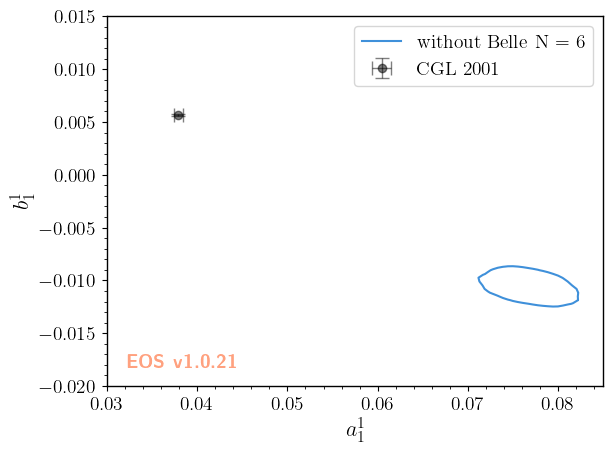

In [68]:
xrange = [0.03, 0.085]
yrange = [-0.02, 0.015]

figure_args = {
'watermark': { 'position': 'lower left' },
'plot': {
    'xaxis': { 'label': r'$a_1^1$', 'range': xrange },
    'yaxis': { 'label': r'$b_1^1$', 'range': yrange },
    'legend': { 'position': 'upper right' },
    'items': [
    { 'type': 'kde2D', 'label': 'without Belle N = 6', 'color': colors[0],
      'levels': [68], 'contours': ['lines'], 'bandwidth': 1.0,
      'datafile': sl_samples_path, 'xrange': xrange, 'yrange': yrange,
      'variables': ['derived::a11', 'derived::b11']
    },
    {'type': 'errorbars', 'positions': [[0.0379, 0.00567]], 'xerrors': [0.0005], 'yerrors': [0.00013], 'label': 'CGL 2001', 'color': 'black'}
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

In [52]:
# Charge radius
eos.tasks.predict_observables(af, posterior, "FF-fp-I1-pion-charge-radius-param", base_directory=BASE_DIRECTORY)
fprime_values = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-FF-fp-I1-pion-charge-radius-param'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order6-wi…

In [53]:
charge_radius_squared_values = np.array(list(map(charge_radius_squared_calculator, fprime_values.samples[:, 0])))
radius_mean = np.average(charge_radius_squared_values, weights=fprime_values.weights)
radius_std  = wstd(charge_radius_squared_values, weights=fprime_values.weights)
print(f"<r^2> = {radius_mean:.4f} ± {radius_std:.4f} fm^2")

<r^2> = 0.4402 ± 0.0043 fm^2


In [26]:
# Residue at the rho pole
eos.tasks.predict_observables(af, posterior, "re-rho-residue-psi", base_directory=BASE_DIRECTORY)
re_res_psi = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-re-rho-residue-psi'))
eos.tasks.predict_observables(af, posterior, "im-rho-residue-psi", base_directory=BASE_DIRECTORY)
im_res_psi = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-im-rho-residue-psi'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order6-wi…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order6-wi…

In [27]:
re_res = re_res_psi.samples[:,0]
im_res = im_res_psi.samples[:,0]
M      = f.samples[:,0]
Gamma  = f.samples[:,1]

print(len(re_res), len(im_res), len(M), len(Gamma)) # check that they have the same length

14741 14741 14741 14741


In [28]:
data = []

for r, i, m, g in zip(re_res, im_res, M, Gamma):
    data.append([r, i, m, g])
with open("residues_psi_wBelle6.wl", "w") as file:
    lines = [f"{{{r}, {i}, {m}, {g}}}" for r, i, m, g in data]
    file.write("{\n" + ",\n".join(lines) + "\n}")

In [ ]:
data = np.loadtxt("residues_s_wBelle6.csv", delimiter=",", ndmin=2,)

res_s = data[:, 0] + 1j * data[:, 1]

# Weighted complex mean
res_s_mean = np.average(res_s, weights=f.weights)

# Weighted standard deviations of the real and imaginary parts
std_re = np.sqrt(np.average((res_s.real - res_s_mean.real)**2, weights=f.weights))
std_im = np.sqrt(np.average((res_s.imag - res_s_mean.imag)**2, weights=f.weights))

print(
    f"residue at s_rho is "
    f"({res_s_mean.real:.4f} ± {std_re:.4f}) "
    f"+ i * ({res_s_mean.imag:.4f} ± {std_im:.4f})"
)

residue at s_rho is (-0.6902 ± 0.0118) + i * (0.1305 ± 0.0138)


In [31]:
# Computing g_{rho pi pi} and g_{rho gamma}
f_at_s_rho       = np.array([get_f_rho(s, analysis) for s in f.samples])
f_at_s_rho_value = f_at_s_rho[:,0] + 1j * f_at_s_rho[:,1]

In [32]:
s_rho       = (M - 1j * Gamma / 2)**2
g_rho_gamma = np.sqrt(24j * np.pi * s_rho / f_at_s_rho_value / res_s / (np.sqrt(1 - sPlus / s_rho))**3)
g_rho_pi_pi = (- res_s / s_rho) * g_rho_gamma

In [33]:
g_rho_gamma_mean = np.average(g_rho_gamma, weights=f.weights)
g_rho_gamma_std  = wstd(g_rho_gamma, weights=f.weights)
print(f"g_rho_gamma =  ({np.real(g_rho_gamma_mean):.4f} ± {np.real(g_rho_gamma_std):.4f}) + i * ({np.imag(g_rho_gamma_mean):.4f} ± {np.imag(g_rho_gamma_std):.4f})")

g_rho_pi_pi_mean = np.average(g_rho_pi_pi, weights=f.weights)
g_rho_pi_pi_std  = wstd(g_rho_pi_pi, weights=f.weights)
print(f"g_rho_pi_pi =  ({np.real(g_rho_pi_pi_mean):.4f} ± {np.real(g_rho_pi_pi_std):.4f}) + i * ({np.imag(g_rho_pi_pi_mean):.4f} ± {np.imag(g_rho_pi_pi_std):.4f})")

g_rho_gamma =  (4.9432 ± 0.0082) + i * (-0.2329 ± 0.0079)
g_rho_pi_pi =  (5.9367 ± 0.0573) + i * (-0.2651 ± 0.1111)


In [34]:
eos.tasks.predict_observables(af, posterior, "a_0", base_directory=BASE_DIRECTORY)
eos.tasks.predict_observables(af, posterior, "a_1", base_directory=BASE_DIRECTORY)
eos.tasks.predict_observables(af, posterior, "a_2", base_directory=BASE_DIRECTORY)
eos.tasks.predict_observables(af, posterior, "a_3", base_directory=BASE_DIRECTORY)

a0 = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-a_0'))
a1 = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-a_1'))
a2 = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-a_2'))
a3 = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-a_3'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order6-wi…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order6-wi…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order6-wi…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order6-wi…

In [35]:
all_coefs = np.column_stack([a0.samples, a1.samples, a2.samples, a3.samples,
                                                     f.samples[:,2], f.samples[:,3], f.samples[:,4]])
np.shape(all_coefs)

(14741, 7)

In [36]:
# Compute weighted median and asymmetric 1-sigma intervals for each coefficient
n_coefs = all_coefs.shape[1]
labels = [f'$a_{i}$' for i in range(n_coefs)]

medians   = np.array([quantile_1D(all_coefs[:,i], f.weights, 0.50) for i in range(n_coefs)])
lo_1sigma = np.array([quantile_1D(all_coefs[:,i], f.weights, 0.16) for i in range(n_coefs)])
hi_1sigma = np.array([quantile_1D(all_coefs[:,i], f.weights, 0.84) for i in range(n_coefs)])

err_low  = medians - lo_1sigma   # downward bar length
err_high = hi_1sigma - medians   # upward bar length


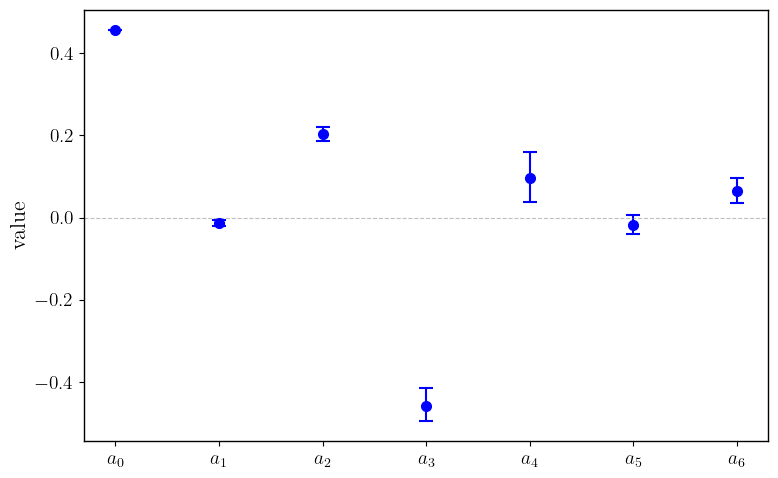

In [37]:
fig, ax = plt.subplots(figsize=(8, 5))
xs = np.arange(n_coefs)

ax.errorbar(xs, medians,
            yerr=[err_low, err_high],
            fmt='o', capsize=5, capthick=1.5, elinewidth=1.5,
            markersize=7, color='b', ecolor='b')

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xticks(xs)
ax.set_xticklabels(labels)
ax.set_ylabel('value')
plt.tight_layout()
plt.show()

## order 7 together

In [42]:
posterior = 'FF-fp-I1-order7-together'
analysis  = af.analysis(posterior)

Creating analysis with 6 priors, 5 EOS-wide constraints, 2 global options, 2 manually-entered constraints and 2 fixed parameters.
likelihood probably depends on 20 parameter(s) that do not appear in the prior; check prior?


In [43]:
start_point = [0.76162639,  0.14351682,  0.06511156, -0.17395961,  0.05851479,
       -0.07647499]

In [44]:
get_gof(analysis, start_point)

In [194]:
#bfp, gof = eos.tasks.find_mode(af, posterior, start_point=start_point, base_directory=BASE_DIRECTORY, optimizations=100)
bfp, gof = eos.tasks.find_mode(af, posterior, importance_samples=True, base_directory=BASE_DIRECTORY, optimizations=100)
display(gof)
bfp.point

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order7-to…

array([ 0.76162639,  0.14351682,  0.06511156, -0.17395961,  0.05851479,
       -0.07647499])

In [45]:
if resample:
    eos.tasks.sample_nested(af, posterior, base_directory=BASE_DIRECTORY, bound='multi', nlive=200)

f = eos.data.ImportanceSamples(os.path.join(BASE_DIRECTORY, 'data', posterior, 'samples'))
print(f"Collected {f.samples.shape[0]} samples") #log z = 80.05

Collected 15362 samples


In [196]:
for i, p in enumerate(analysis.varied_parameters):
    mean = np.average(f.samples[:,i], weights=f.weights)
    std  = wstd(f.samples[:,i], weights=f.weights)
    print(f"      - {{ 'parameter': '{p.name()}', 'min':  {mean - 5*std:.5f}, 'max':  {mean + 5*std:.5f}, 'type': 'uniform'}}")

      - { 'parameter': '0->pipi::M_(+,1,0)@BHKMNR2026', 'min':  0.75942, 'max':  0.76405, 'type': 'uniform'}
      - { 'parameter': '0->pipi::Gamma_(+,1,0)@BHKMNR2026', 'min':  0.14018, 'max':  0.14681, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^4@BHKMNR2026', 'min':  -0.10208, 'max':  0.31126, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^5@BHKMNR2026', 'min':  -0.37664, 'max':  0.11790, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^6@BHKMNR2026', 'min':  -0.02478, 'max':  0.17625, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^7@BHKMNR2026', 'min':  -0.16962, 'max':  0.04977, 'type': 'uniform'}


Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order7-to…

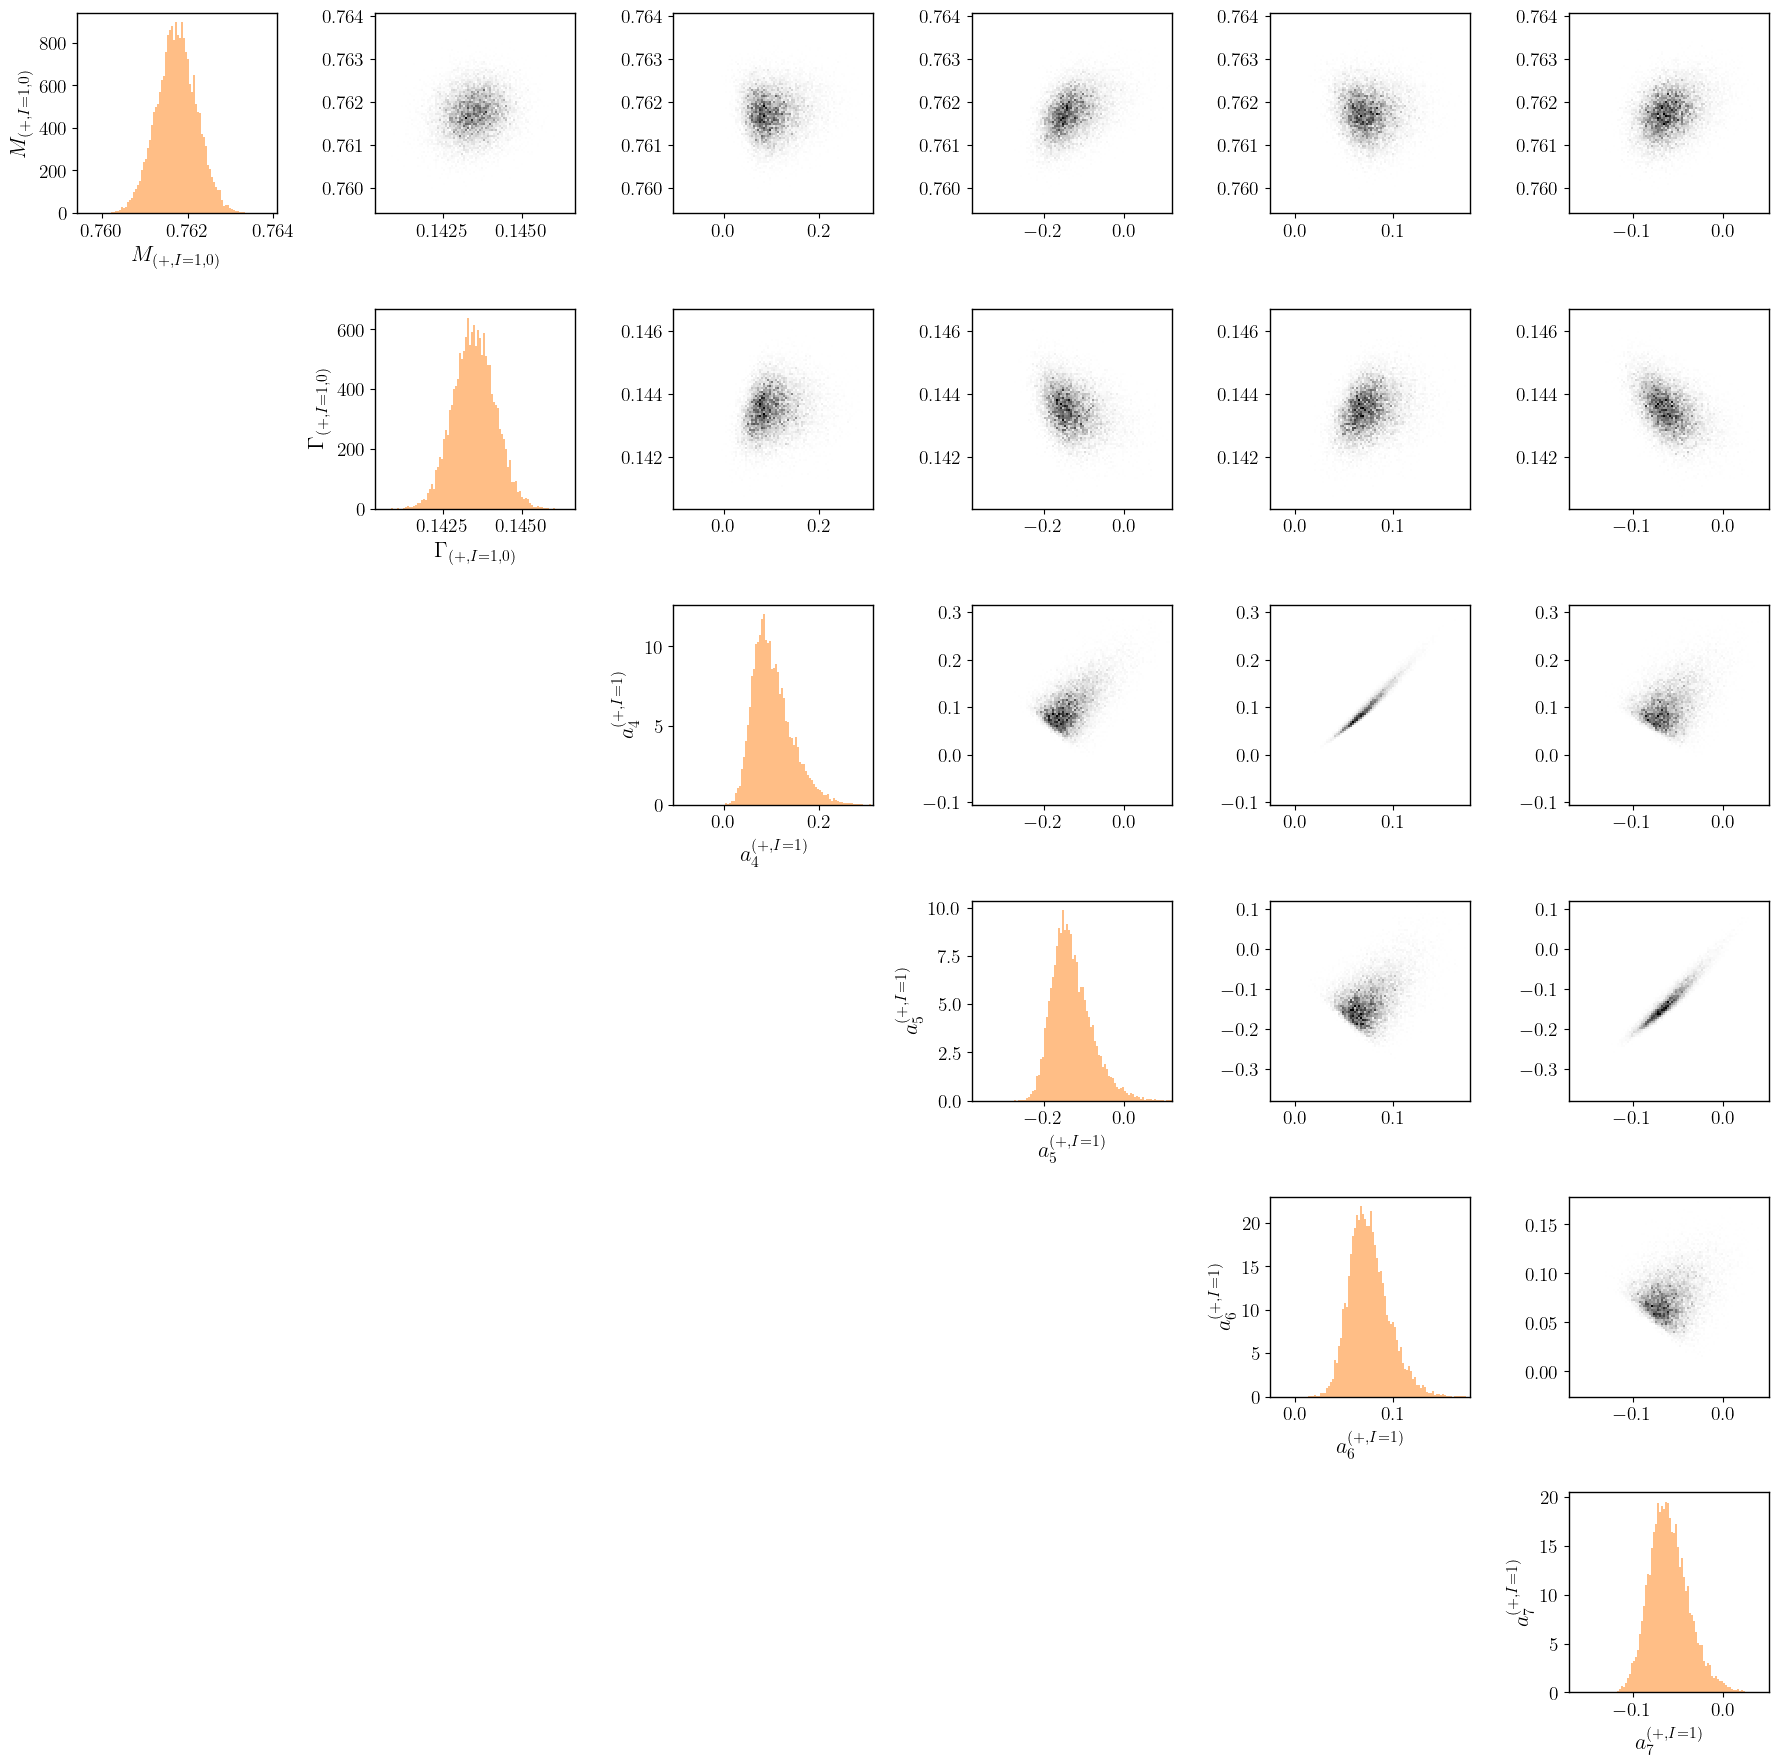

In [197]:
eos.tasks.corner_plot(af, posterior, base_directory=BASE_DIRECTORY)

In [97]:
print(f"rho mass  = {np.average(f.samples[:,0], weights=f.weights):.4f} ± {wstd(f.samples[:,0], weights=f.weights):.4f}")
print(f"rho width = {np.average(f.samples[:,1], weights=f.weights):.4f} ± {wstd(f.samples[:,1], weights=f.weights):.4f}")

rho mass  = 0.7617 ± 0.0005
rho width = 0.1435 ± 0.0007


Computing KDE for samples of variables '0->pipi::M_(+,1,0)@BHKMNR2026' and '0->pipi::Gamma_(+,1,0)@BHKMNR2026'


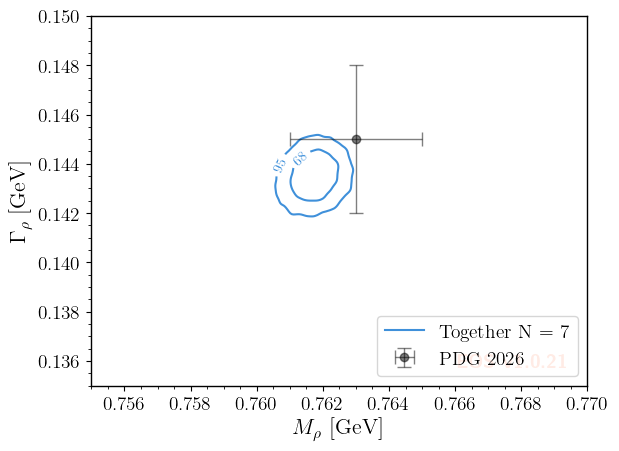

In [98]:
figure_args = {
'watermark': { 'position': 'lower right' },
'plot': {
    'xaxis': { 'label': r'$M_\rho$', 'unit': '$\\mathrm{GeV}$', 'range': [0.755, 0.77] },
    'yaxis': { 'label': r'$\Gamma_\rho$', 'unit': '$\\mathrm{GeV}$', 'range': [ 0.135, 0.15] },
    'legend': { 'position': 'lower right' },
    'items': [
    { 'type': 'kde2D', 'label': 'Together N = 7', 'color': colors[0],
      'levels': [68, 95], 'contours': ['lines', 'labels'],
      'datafile': 'data/'+posterior+'/samples',
      'variables': ['0->pipi::M_(+,1,0)@BHKMNR2026', '0->pipi::Gamma_(+,1,0)@BHKMNR2026']
    },
    {'type': 'errorbars', 'positions': [[0.763, 0.145]], 'xerrors': [0.002], 'yerrors': [0.003], 'label': 'PDG 2026', 'color': 'black'}
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

In [201]:
# Dispersive bound computation
eos.tasks.predict_observables(af, posterior, "FF-fp-I1-dispersive-bound", base_directory=BASE_DIRECTORY)
preds = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-FF-fp-I1-dispersive-bound'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order7-to…

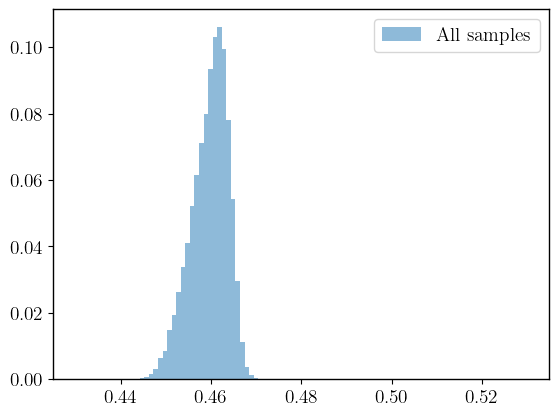

In [202]:
plt.hist(preds.samples, weights=preds.weights, bins=np.linspace(0.43,0.53,100), alpha=0.5, label='All samples')
plt.legend()
plt.show()

In [203]:
disp_values = np.array(preds.samples[:,0])
disp_mean   = np.average(disp_values, weights=preds.weights)
disp_std    = wstd(disp_values, weights=preds.weights)
print(f"Dispersive bound is {disp_mean:.4f} ± {disp_std:.4f}")

Dispersive bound is 0.4596 ± 0.0041


In [71]:
eos.tasks.predict_observables(af, posterior, "FF-fp2-I1-all", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order7-to…

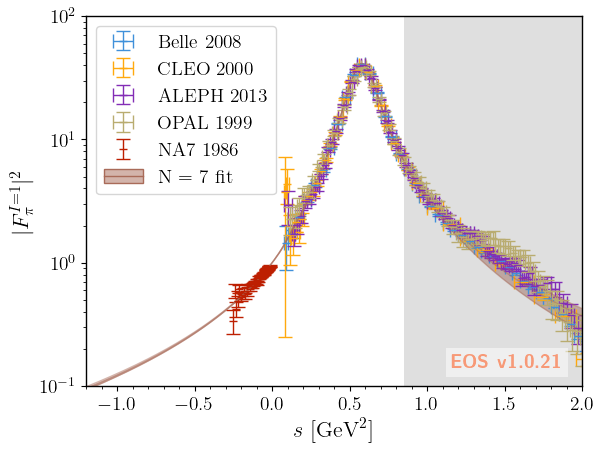

In [72]:
figure_args = {
'watermark': { 'position': 'lower right' },
'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [-1.2, 2.0] },
    'yaxis': { 'label': r'$|F^{I=1}_\pi|^2$', 'range': [ 0.1, 100.0], 'scale': 'log' },
    'legend': { 'position': 'upper left' },
    'items': [
    { 'type': 'constraint', 'label': 'Belle 2008', 'color': colors[0],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',
        'constraints': '0->pipi::Abs{f_+}^2@Belle:2008C',
    },
    { 'type': 'constraint', 'label': 'CLEO 2000', 'color': colors[1],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',
        'constraints': '0->pipi::Abs{f_+}^2@CLEO:2000B',
    },
    { 'type': 'constraint', 'label': 'ALEPH 2013', 'color': colors[4],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',
        'constraints': '0->pipi::Abs{f_+}^2@ALEPH:2013A',
    },
    { 'type': 'constraint', 'label': 'OPAL 1999', 'color': colors[7],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',
        'constraints': '0->pipi::Abs{f_+}^2@OPAL:1999A',
    },
    { 'type': 'constraint', 'label': 'NA7 1986', 'color': colors[2],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2)',
        'constraints': '0->pipi::Abs{f_+}^2@NA7:1986A',
    },
    { 'type': 'uncertainty', 'label': 'N = 7 fit', 'color': colors[5],
        'variable': 'q2', 'range': [-1.2, 2.0], 'interpolation': 'cubic',
        'datafile': 'data/'+posterior+'/pred-FF-fp2-I1-all', 'resolution': 300
    },
    { 'type': 'band', 'color': 'gray', 'alpha': 0.25, 'x': [sIn, 2.0], 'y': [0.0, 100]}
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

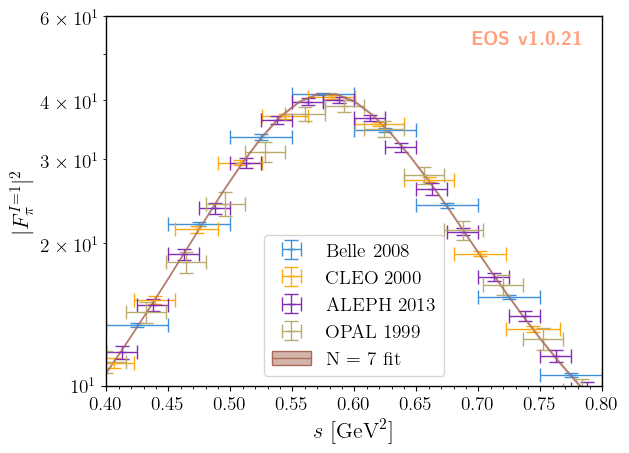

In [73]:
figure_args = {
'watermark': { 'position': 'upper right' },
'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [0.4, 0.8] },
    'yaxis': { 'label': r'$|F^{I=1}_\pi|^2$', 'range': [ 10.0, 60.0], 'scale': 'log' },
    'legend': { 'position': 'lower center' },
    'items': [
    { 'type': 'constraint', 'label': 'Belle 2008', 'color': colors[0],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',
        'constraints': '0->pipi::Abs{f_+}^2@Belle:2008C',
    },
    { 'type': 'constraint', 'label': 'CLEO 2000', 'color': colors[1],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',
        'constraints': '0->pipi::Abs{f_+}^2@CLEO:2000B',
    },
    { 'type': 'constraint', 'label': 'ALEPH 2013', 'color': colors[4],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',
        'constraints': '0->pipi::Abs{f_+}^2@ALEPH:2013A',
    },
    { 'type': 'constraint', 'label': 'OPAL 1999', 'color': colors[7],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',
        'constraints': '0->pipi::Abs{f_+}^2@OPAL:1999A',
    },
    { 'type': 'uncertainty', 'label': 'N = 7 fit', 'color': colors[5],
        'variable': 'q2', 'range': [-1.2, 2.0], 'interpolation': 'cubic',
        'datafile': 'data/'+posterior+'/pred-FF-fp2-I1-all', 'resolution': 300
    }
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

In [207]:
get_gof(analysis, start_point)
param_dict = {p.name(): p.evaluate() for p in analysis.parameters}

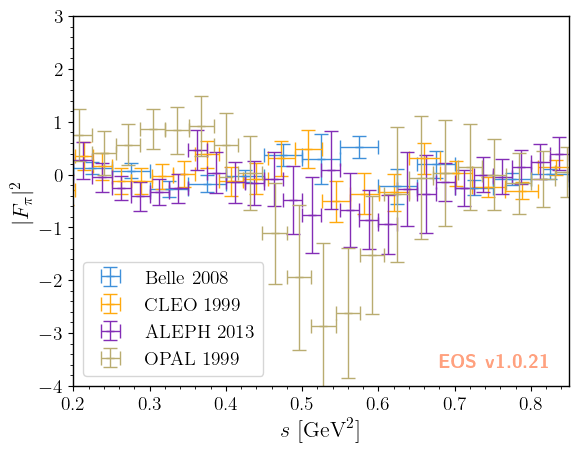

In [208]:
figure_args = {
'watermark': { 'position': 'lower right' },
'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [0.2, sIn] },
    'yaxis': { 'label': r'$|F_\pi|^2$', 'range': [ -4, 3], 'scale': 'linear' },
    'legend': { 'position': 'lower left' },
    'items': [
        { 'type': 'constraint-residue', 'label': 'Belle 2008', 'parameters': param_dict, 'options': {"form-factors": "BHKMNR2026"},
          'color': colors[0],  'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)', 'style': 'delta', 'constraints': '0->pipi::Abs{f_+}^2@Belle:2008C',
        },
        { 'type': 'constraint-residue', 'label': 'CLEO 1999', 'parameters': param_dict, 'options': {"form-factors": "BHKMNR2026"},
          'color': colors[1], 'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)', 'style': 'delta', 'constraints': '0->pipi::Abs{f_+}^2@CLEO:2000B',
        },
        { 'type': 'constraint-residue', 'label': 'ALEPH 2013', 'parameters': param_dict, 'options': {"form-factors": "BHKMNR2026"},
          'color': colors[4], 'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',  'style': 'delta', 'constraints': '0->pipi::Abs{f_+}^2@ALEPH:2013A',
        },
        { 'type': 'constraint-residue', 'label': 'OPAL 1999', 'parameters': param_dict, 'options': {"form-factors": "BHKMNR2026"},
          'color': colors[7], 'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',  'style': 'delta', 'constraints': '0->pipi::Abs{f_+}^2@OPAL:1999A',
        }
        ]
        }
        }
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

In [209]:
eos.tasks.predict_observables(af, posterior, "FF-arg-fp-I1-timelike", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order7-to…

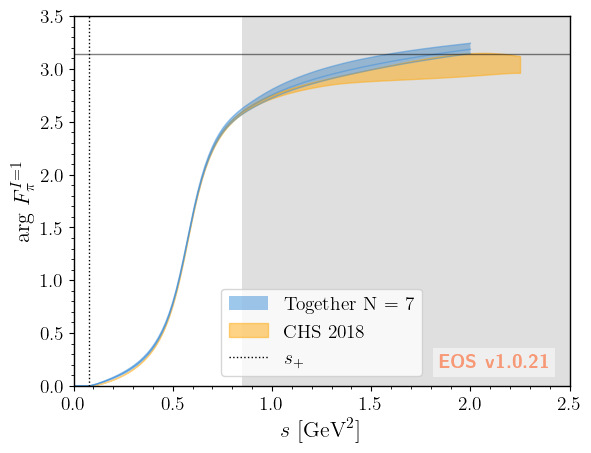

In [41]:
figure_args = {
  'watermark': { 'position': 'lower right' },
  'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [0.0, 2.5] },
    'yaxis': { 'label': r'arg $F^{I=1}_\pi$', 'range': [0.0 , 3.5] },
    'legend': { 'position': 'lower right' },
    'items': [
      { 'type': 'uncertainty', 'label': 'Together N = 7', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-FF-arg-fp-I1-timelike', 'color': colors[0]
      },
      { 'type': 'band', 'color': 'gray', 'alpha': 0.25, 'x': [sIn, 2.5], 'y': [0.0, 3.5]},
      { 'type': 'expression', 'expression': 'np.pi', 'range': [0, 2.5], 'color': 'k'}
    ]
  }
}

figure = eos.figure.FigureFactory.from_dict(**figure_args)

q2_over_mpisquared, phase, err = np.loadtxt("scripts/d11-central.txt", skiprows=1, unpack=True)
q2 = q2_over_mpisquared * mpi**2
figure.draw()

ax = figure._ax
ax.fill_between(q2, phase - err, phase + err, label="CHS 2018", alpha=0.5, color=colors[1])

ax.axvline(x=sPlus, color='k', linestyle=':', linewidth=1.0, label=r'$s_+$')

ax.legend(loc="lower center")

In [211]:
get_gof(analysis, start_point)
analysis.parameters.dump('data/'+posterior+'/mode-default/parameters.yaml')

Handling item to plot 0->pipi::Arg{f_+}(Re{psi},Im{psi})@BHKMNR2026 in the complex plane
Overriding parameters from file
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,2)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(0,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(0,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,2)@KSvD2025' with central value '0'
[parameters.override] Overriding existing p

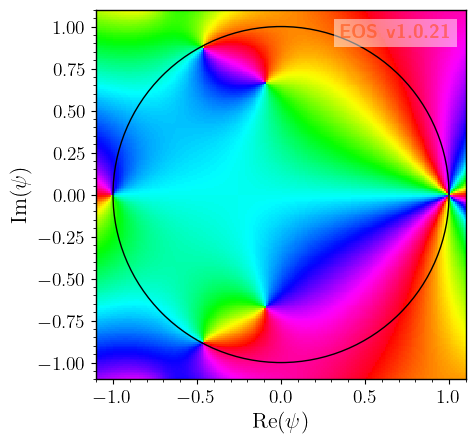

In [ ]:
figure_args = {
'plot': {
    'xaxis': { 'label': r'$\mathrm{Re}(\psi)$', 'range': [-1.1, 1.1] },
    'yaxis': { 'label': r'$\mathrm{Im}(\psi)$', 'range': [-1.1, 1.1] },
    # 'legend': { 'position': 'upper left' },
    'items': [
    { 'type': 'complex-plane', 'colormap': 'hsv', 'ranges': ((-1.1, +1.1), (-1.1, +1.1)),
        'variables': ["Re{psi}", "Im{psi}"], 'observable': "0->pipi::Arg{f_+}(Re{psi},Im{psi})@BHKMNR2026",
        'fixed_parameters_from_file': 'data/'+posterior+'/mode-default/parameters.yaml', 'resolution': 200
    }
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()
circle = plt.Circle((0, 0), 1.0, color='k', fill=False)
figure._ax.add_patch(circle)
figure._ax.set_aspect("equal", adjustable="box")


In [74]:
eos.tasks.predict_observables(af, posterior, "real-partial-wave-I1", base_directory=BASE_DIRECTORY)
eos.tasks.predict_observables(af, posterior, "imag-partial-wave-I1", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order7-to…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order7-to…

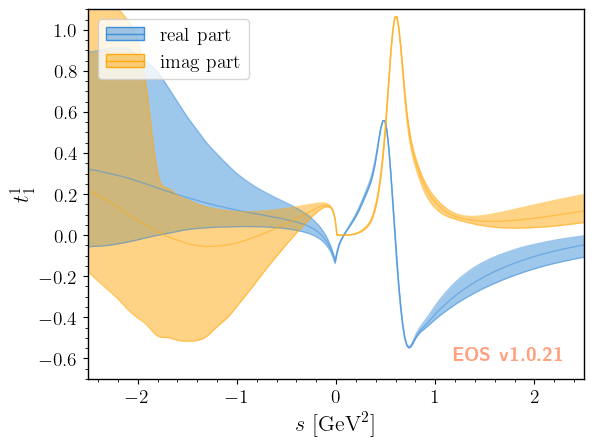

In [75]:
figure_args = {
  'watermark': { 'position': 'lower right' },
  'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [-2.5, 2.5] },
    'yaxis': { 'label': '$t_1^1$', 'range': [-0.7, 1.1]},
    'legend': { 'position': 'upper left' },
    'items': [
      { 'type': 'uncertainty', 'label': 'real part', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-real-partial-wave-I1'
      },
      { 'type': 'uncertainty', 'label': 'imag part', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-imag-partial-wave-I1'
      },
    ]
  }
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

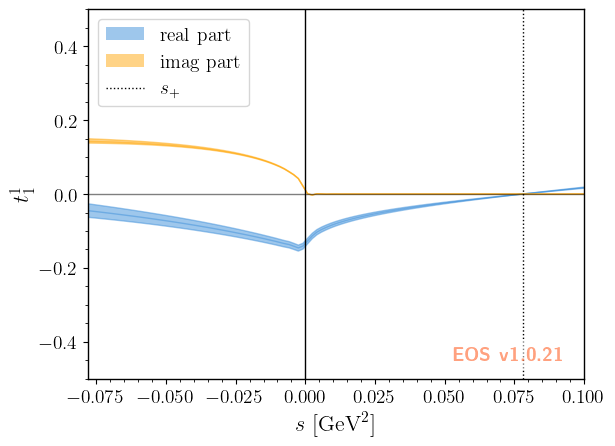

In [76]:
figure_args = {
  'watermark': { 'position': 'lower right' },
  'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [-sPlus, 0.1] },
    'yaxis': { 'label': '$t_1^1$', 'range': [-0.5, 0.5]},
    'legend': { 'position': 'upper left' },
    'items': [
      { 'type': 'uncertainty', 'label': 'real part', 'interpolation': 'cubic', 'resolution': 3000,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-real-partial-wave-I1'
      },
      { 'type': 'uncertainty', 'label': 'imag part', 'interpolation': 'cubic', 'resolution': 3000,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-imag-partial-wave-I1'
      },
      { 'type': 'expression', 'expression': '0', 'range': [-sPlus, 0.1], 'color': 'k'}
    ]
  }
}

figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()
ax = figure._ax
ax.axvline( x=0.0, color='k', linewidth=1.0)
ax.axvline( x=sPlus, color='k', linestyle=':', linewidth=1.0, label=r'$s_+$')
ax.legend(loc='upper left')

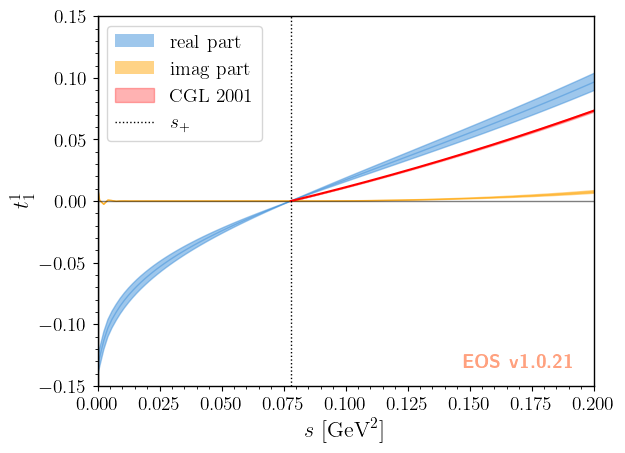

In [78]:
with np.load(theory_path) as saved:
    s_theory = saved['s']
    t_theory_samples = saved['t11']

# Calculate the band; the theory samples have equal weights.
t_lower, t_median, t_upper = np.quantile(
    t_theory_samples,
    [0.15865, 0.5, 0.84135],
    axis=0
)


figure_args = {
  'watermark': { 'position': 'lower right' },
  'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [0, 0.2] },
    'yaxis': { 'label': '$t_1^1$', 'range': [-0.15, 0.15]},
    'legend': { 'position': 'upper left' },
    'items': [
      { 'type': 'uncertainty', 'label': 'real part', 'interpolation': 'cubic', 'resolution': 3000,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-real-partial-wave-I1'
      },
      { 'type': 'uncertainty', 'label': 'imag part', 'interpolation': 'cubic', 'resolution': 3000,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-imag-partial-wave-I1'
      },
      { 'type': 'expression', 'expression': '0', 'range': [0, 0.2], 'color': 'k'}
    ]
  }
}

figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()
ax = figure._ax
# Add the theory band and median to the same axes.
ax.fill_between(
    s_theory,
    t_lower,
    t_upper,
    color='red',
    alpha=0.3,
    label='CGL 2001'
)

ax.plot(
    s_theory,
    t_median,
    color='red',
    linewidth=1.5
)

ax.axvline(x=0.0, color='k', linewidth=1.0)
ax.axvline(
    x=sPlus,
    color='k',
    linestyle=':',
    linewidth=1.0,
    label=r'$s_+$'
)

# Include the theory band and reference line in the legend.
ax.legend(loc='upper left')

In [79]:
# Analytic value of a11 and b11
eos.tasks.predict_observables(af, posterior, "FF-fp-I1-scattering-length-params", base_directory=BASE_DIRECTORY)
sl_params = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-FF-fp-I1-scattering-length-params'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order7-to…

In [80]:
a11_values, b11_values = calculate_sl_values(sl_params)
(a11_mean, a11_std, b11_mean, b11_std) = summarize_sl_values("Together N = 7", a11_values, b11_values, sl_params.weights)

Together N = 7 a11 = 0.0625 ± 0.0057
Together N = 7 b11 = -0.0079 ± 0.0010


In [81]:
sl_samples_path = save_sl_samples(posterior, a11_values, b11_values, sl_params.weights)

Computing KDE for samples of variables 'derived::a11' and 'derived::b11'


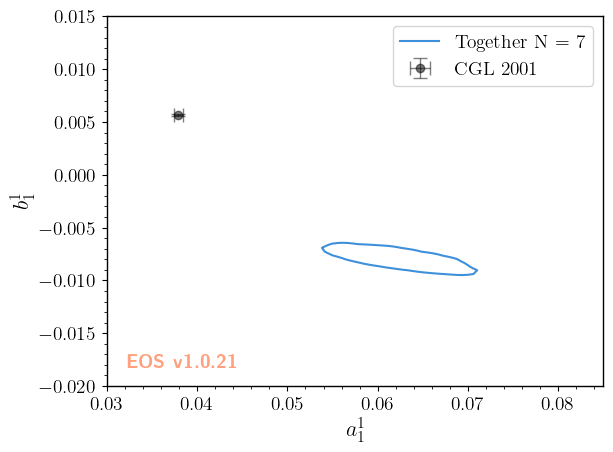

In [82]:
xrange = [0.03, 0.085]
yrange = [-0.02, 0.015]

figure_args = {
'watermark': { 'position': 'lower left' },
'plot': {
    'xaxis': { 'label': r'$a_1^1$', 'range': xrange },
    'yaxis': { 'label': r'$b_1^1$', 'range': yrange },
    'legend': { 'position': 'upper right' },
    'items': [
    { 'type': 'kde2D', 'label': 'Together N = 7', 'color': colors[0],
      'levels': [68], 'contours': ['lines'], 'bandwidth': 1.0,
      'datafile': sl_samples_path, 'xrange': xrange, 'yrange': yrange,
      'variables': ['derived::a11', 'derived::b11']
    },
    {'type': 'errorbars', 'positions': [[0.0379, 0.00567]], 'xerrors': [0.0005], 'yerrors': [0.00013], 'label': 'CGL 2001', 'color': 'black'}
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

In [219]:
# Charge radius
eos.tasks.predict_observables(af, posterior, "FF-fp-I1-pion-charge-radius-param", base_directory=BASE_DIRECTORY)
fprime_values = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-FF-fp-I1-pion-charge-radius-param'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order7-to…

In [220]:
charge_radius_squared_values = np.array(list(map(charge_radius_squared_calculator, fprime_values.samples[:, 0])))
radius_mean = np.average(charge_radius_squared_values, weights=fprime_values.weights)
radius_std  = wstd(charge_radius_squared_values, weights=fprime_values.weights)
print(f"<r^2> = {radius_mean:.4f} ± {radius_std:.4f} fm^2")

<r^2> = 0.4309 ± 0.0043 fm^2


In [46]:
# Residue at the rho pole
eos.tasks.predict_observables(af, posterior, "re-rho-residue-psi", base_directory=BASE_DIRECTORY)
re_res_psi = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-re-rho-residue-psi'))
eos.tasks.predict_observables(af, posterior, "im-rho-residue-psi", base_directory=BASE_DIRECTORY)
im_res_psi = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-im-rho-residue-psi'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order7-to…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order7-to…

In [47]:
re_res = re_res_psi.samples[:,0]
im_res = im_res_psi.samples[:,0]
M      = f.samples[:,0]
Gamma  = f.samples[:,1]

print(len(re_res), len(im_res), len(M), len(Gamma)) # check that they have the same length

15362 15362 15362 15362


In [48]:
data = []

for r, i, m, g in zip(re_res, im_res, M, Gamma):
    data.append([r, i, m, g])
with open("residues_psi_together7.wl", "w") as file:
    lines = [f"{{{r}, {i}, {m}, {g}}}" for r, i, m, g in data]
    file.write("{\n" + ",\n".join(lines) + "\n}")

In [ ]:
data = np.loadtxt("residues_s_together7.csv", delimiter=",", ndmin=2,)

res_s = data[:, 0] + 1j * data[:, 1]

# Weighted complex mean
res_s_mean = np.average(res_s, weights=f.weights)

# Weighted standard deviations of the real and imaginary parts
std_re = np.sqrt(np.average((res_s.real - res_s_mean.real)**2, weights=f.weights))
std_im = np.sqrt(np.average((res_s.imag - res_s_mean.imag)**2, weights=f.weights))

print(
    f"residue at s_rho is "
    f"({res_s_mean.real:.4f} ± {std_re:.4f}) "
    f"+ i * ({res_s_mean.imag:.4f} ± {std_im:.4f})"
)

residue at s_rho is (-0.6907 ± 0.0069) + i * (0.1465 ± 0.0136)


In [50]:
# Computing g_{rho pi pi} and g_{rho gamma}
f_at_s_rho       = np.array([get_f_rho(s, analysis) for s in f.samples])
f_at_s_rho_value = f_at_s_rho[:,0] + 1j * f_at_s_rho[:,1]

In [51]:
s_rho       = (M - 1j * Gamma / 2)**2
g_rho_gamma = np.sqrt(24j * np.pi * s_rho / f_at_s_rho_value / res_s / (np.sqrt(1 - sPlus / s_rho))**3)
g_rho_pi_pi = (- res_s / s_rho) * g_rho_gamma

In [52]:
g_rho_gamma_mean = np.average(g_rho_gamma, weights=f.weights)
g_rho_gamma_std  = wstd(g_rho_gamma, weights=f.weights)
print(f"g_rho_gamma =  ({np.real(g_rho_gamma_mean):.4f} ± {np.real(g_rho_gamma_std):.4f}) + i * ({np.imag(g_rho_gamma_mean):.4f} ± {np.imag(g_rho_gamma_std):.4f})")

g_rho_pi_pi_mean = np.average(g_rho_pi_pi, weights=f.weights)
g_rho_pi_pi_std  = wstd(g_rho_pi_pi, weights=f.weights)
print(f"g_rho_pi_pi =  ({np.real(g_rho_pi_pi_mean):.4f} ± {np.real(g_rho_pi_pi_std):.4f}) + i * ({np.imag(g_rho_pi_pi_mean):.4f} ± {np.imag(g_rho_pi_pi_std):.4f})")

g_rho_gamma =  (4.9108 ± 0.0001) + i * (-0.2255 ± -0.0066)
g_rho_pi_pi =  (5.9158 ± 0.0225) + i * (-0.3971 ± 0.1022)


In [53]:
eos.tasks.predict_observables(af, posterior, "a_0", base_directory=BASE_DIRECTORY)
eos.tasks.predict_observables(af, posterior, "a_1", base_directory=BASE_DIRECTORY)
eos.tasks.predict_observables(af, posterior, "a_2", base_directory=BASE_DIRECTORY)
eos.tasks.predict_observables(af, posterior, "a_3", base_directory=BASE_DIRECTORY)

a0 = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-a_0'))
a1 = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-a_1'))
a2 = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-a_2'))
a3 = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-a_3'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order7-to…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order7-to…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order7-to…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order7-to…

In [54]:
all_coefs = np.column_stack([a0.samples, a1.samples, a2.samples, a3.samples,
                                                     f.samples[:,2], f.samples[:,3], f.samples[:,4], f.samples[:,5]])
np.shape(all_coefs)

(15362, 8)

In [55]:
# Compute weighted median and asymmetric 1-sigma intervals for each coefficient
n_coefs = all_coefs.shape[1]
labels = [f'$a_{i}$' for i in range(n_coefs)]

medians   = np.array([quantile_1D(all_coefs[:,i], f.weights, 0.50) for i in range(n_coefs)])
lo_1sigma = np.array([quantile_1D(all_coefs[:,i], f.weights, 0.16) for i in range(n_coefs)])
hi_1sigma = np.array([quantile_1D(all_coefs[:,i], f.weights, 0.84) for i in range(n_coefs)])

err_low  = medians - lo_1sigma   # downward bar length
err_high = hi_1sigma - medians   # upward bar length


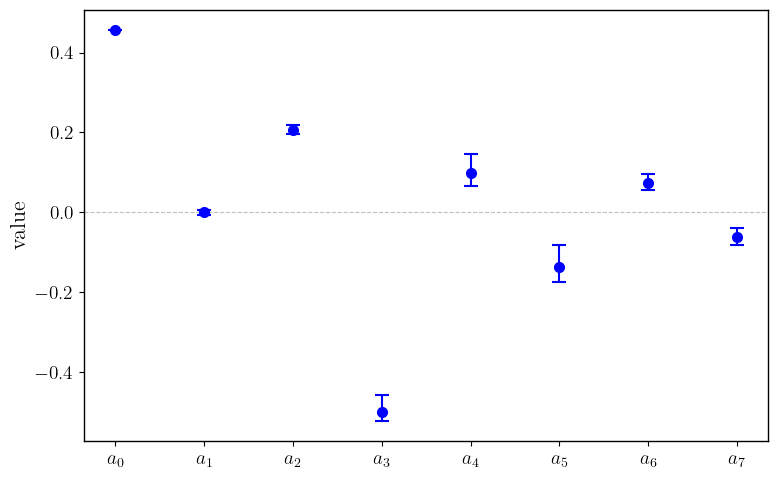

In [56]:
fig, ax = plt.subplots(figsize=(8, 5))
xs = np.arange(n_coefs)

ax.errorbar(xs, medians,
            yerr=[err_low, err_high],
            fmt='o', capsize=5, capthick=1.5, elinewidth=1.5,
            markersize=7, color='b', ecolor='b')

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xticks(xs)
ax.set_xticklabels(labels)
ax.set_ylabel('value')
plt.tight_layout()
plt.show()

## order 7 without Belle

In [57]:
posterior = 'FF-fp-I1-order7-without-Belle'
analysis  = af.analysis(posterior)

Creating analysis with 6 priors, 4 EOS-wide constraints, 2 global options, 2 manually-entered constraints and 2 fixed parameters.


likelihood probably depends on 20 parameter(s) that do not appear in the prior; check prior?


In [58]:
start_point = [0.76129127,  0.14340076,  0.02817282, -0.1033208 ,  0.0338824 ,
       -0.03249369]

In [59]:
get_gof(analysis, start_point)

In [80]:
#bfp, gof = eos.tasks.find_mode(af, posterior, start_point=start_point, base_directory=BASE_DIRECTORY, optimizations=100)
bfp, gof = eos.tasks.find_mode(af, posterior, importance_samples=True, base_directory=BASE_DIRECTORY, optimizations=100)
display(gof)
bfp.point

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order7-wi…

array([ 0.76129127,  0.14340076,  0.02817282, -0.1033208 ,  0.0338824 ,
       -0.03249369])

In [60]:
if resample:
    eos.tasks.sample_nested(af, posterior, base_directory=BASE_DIRECTORY, bound='multi', nlive=200)

f = eos.data.ImportanceSamples(os.path.join(BASE_DIRECTORY, 'data', posterior, 'samples'))
print(f"Collected {f.samples.shape[0]} samples") #log z = 96.92

Collected 14090 samples


In [82]:
for i, p in enumerate(analysis.varied_parameters):
    mean = np.average(f.samples[:,i], weights=f.weights)
    std  = wstd(f.samples[:,i], weights=f.weights)
    print(f"      - {{ 'parameter': '{p.name()}', 'min':  {mean - 5*std:.5f}, 'max':  {mean + 5*std:.5f}, 'type': 'uniform'}}")

      - { 'parameter': '0->pipi::M_(+,1,0)@BHKMNR2026', 'min':  0.75828, 'max':  0.76449, 'type': 'uniform'}
      - { 'parameter': '0->pipi::Gamma_(+,1,0)@BHKMNR2026', 'min':  0.13817, 'max':  0.15186, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^4@BHKMNR2026', 'min':  -0.18221, 'max':  0.38046, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^5@BHKMNR2026', 'min':  -0.42663, 'max':  0.33229, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^6@BHKMNR2026', 'min':  -0.06771, 'max':  0.20436, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^7@BHKMNR2026', 'min':  -0.19897, 'max':  0.16675, 'type': 'uniform'}


Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order7-wi…

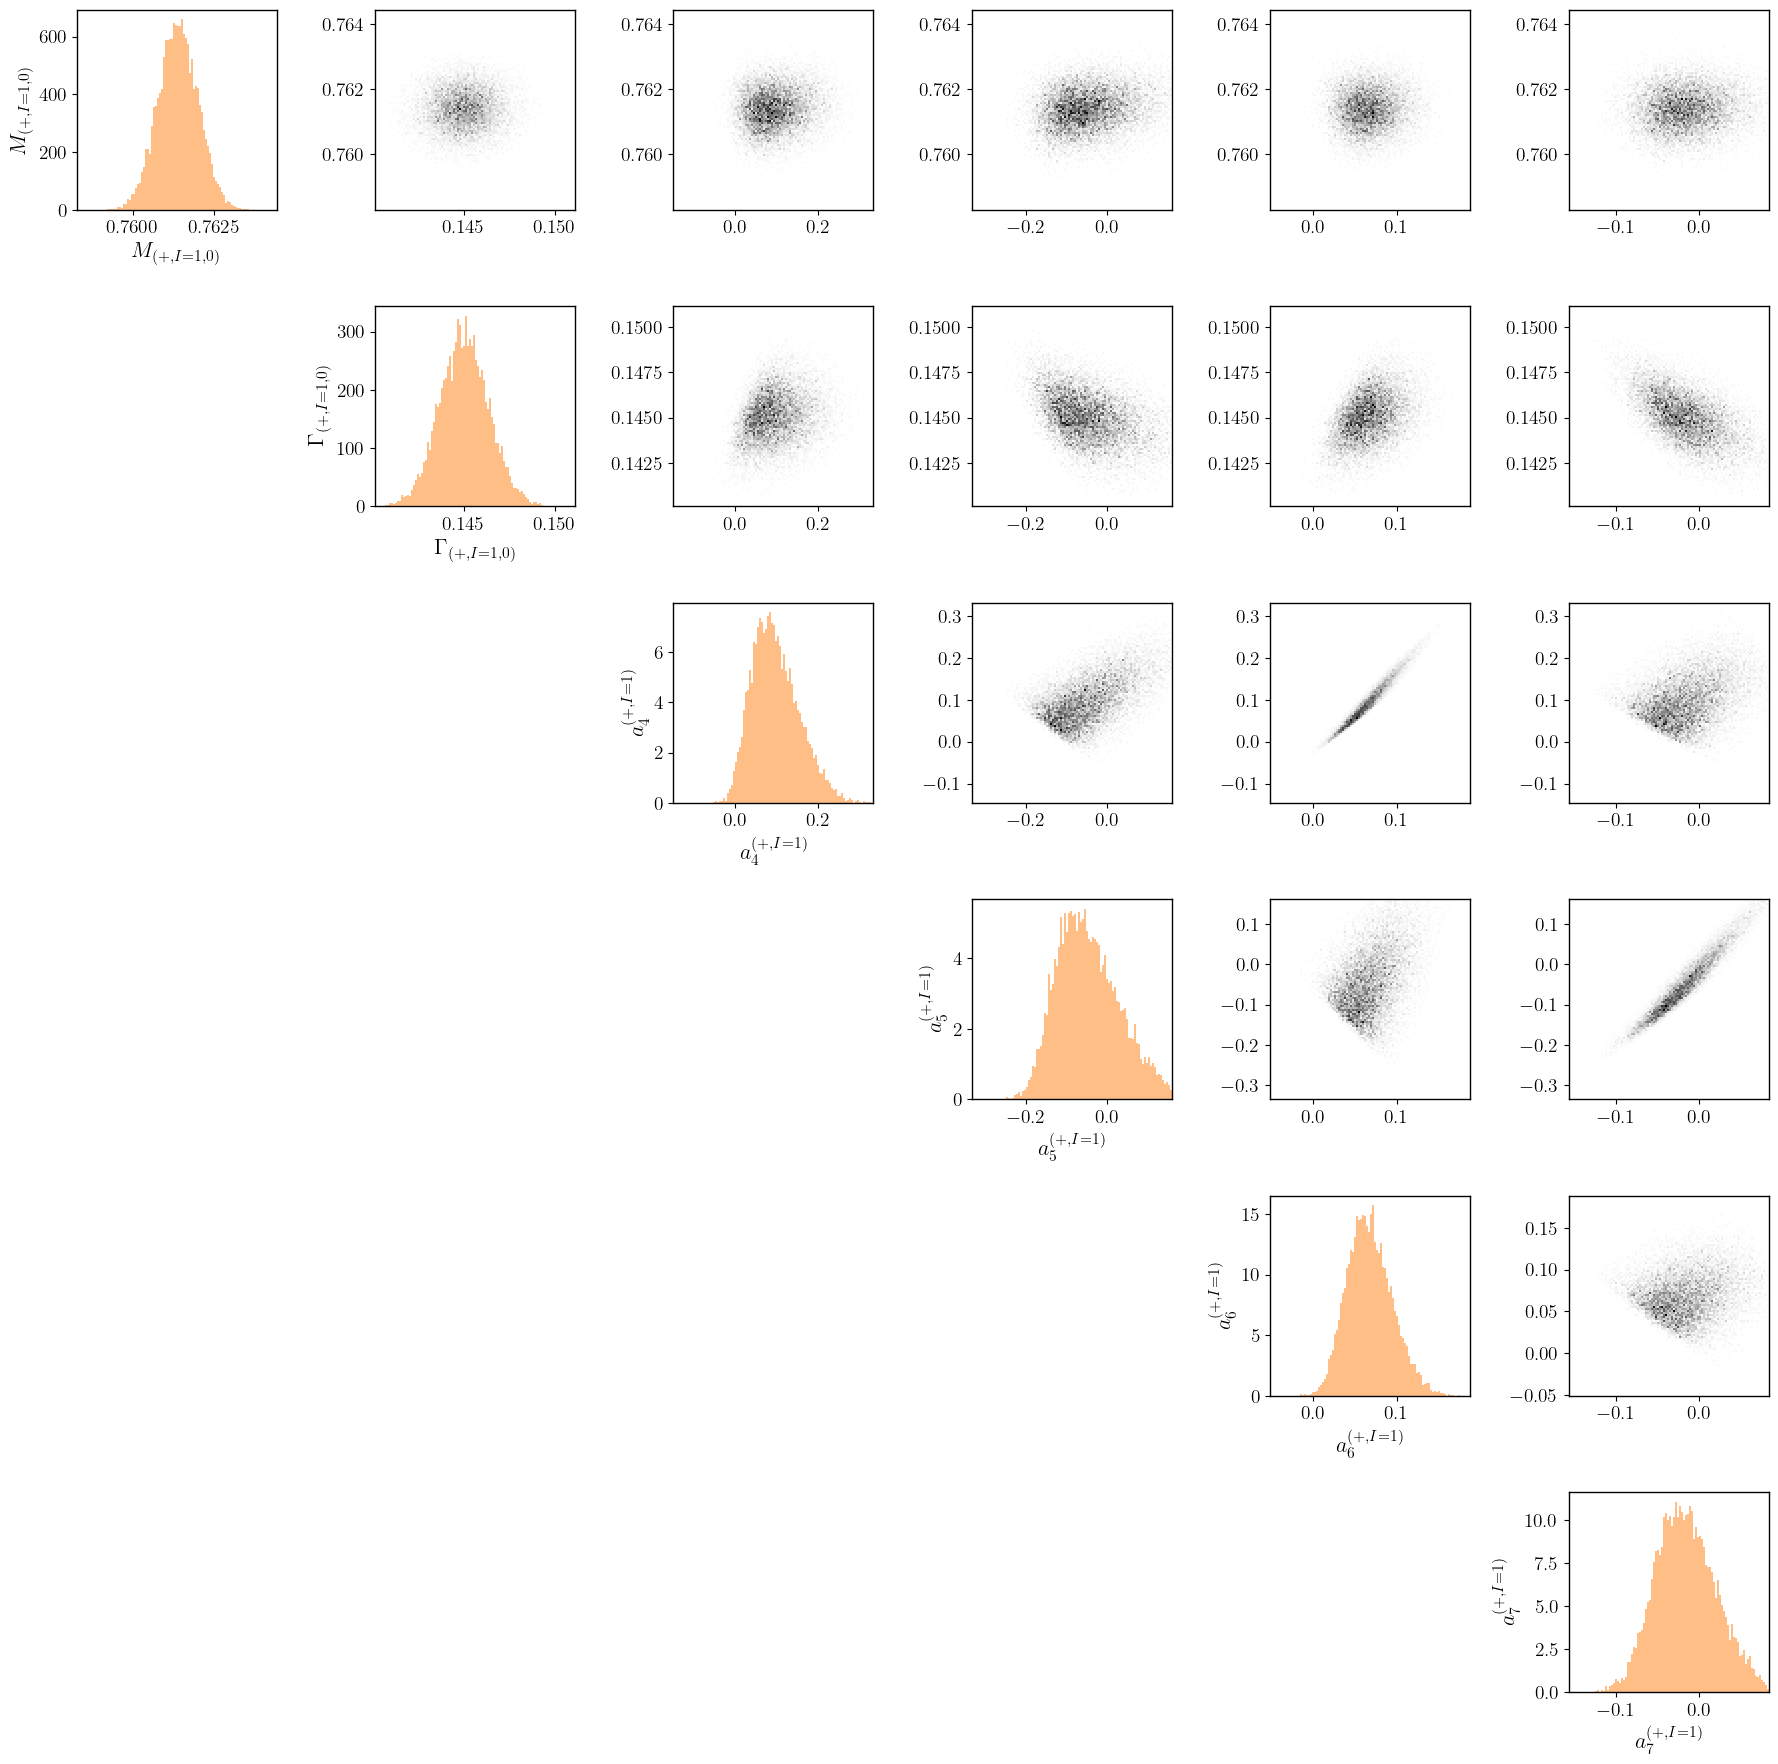

In [83]:
eos.tasks.corner_plot(af, posterior, base_directory=BASE_DIRECTORY)

In [57]:
print(f"rho mass  = {np.average(f.samples[:,0], weights=f.weights):.4f} ± {wstd(f.samples[:,0], weights=f.weights):.4f}")
print(f"rho width = {np.average(f.samples[:,1], weights=f.weights):.4f} ± {wstd(f.samples[:,1], weights=f.weights):.4f}")

rho mass  = 0.7614 ± 0.0006
rho width = 0.1450 ± 0.0014


Computing KDE for samples of variables '0->pipi::M_(+,1,0)@BHKMNR2026' and '0->pipi::Gamma_(+,1,0)@BHKMNR2026'


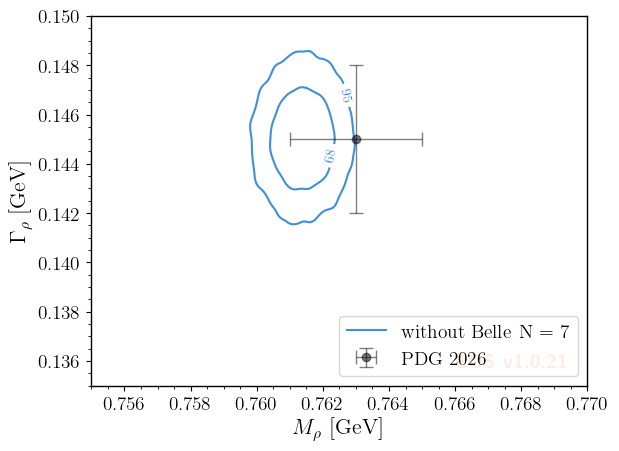

In [58]:
figure_args = {
'watermark': { 'position': 'lower right' },
'plot': {
    'xaxis': { 'label': r'$M_\rho$', 'unit': '$\\mathrm{GeV}$', 'range': [0.755, 0.77] },
    'yaxis': { 'label': r'$\Gamma_\rho$', 'unit': '$\\mathrm{GeV}$', 'range': [ 0.135, 0.15] },
    'legend': { 'position': 'lower right' },
    'items': [
    { 'type': 'kde2D', 'label': 'without Belle N = 7', 'color': colors[0],
      'levels': [68, 95], 'contours': ['lines', 'labels'],
      'datafile': 'data/'+posterior+'/samples',
      'variables': ['0->pipi::M_(+,1,0)@BHKMNR2026', '0->pipi::Gamma_(+,1,0)@BHKMNR2026']
    },
    {'type': 'errorbars', 'positions': [[0.763, 0.145]], 'xerrors': [0.002], 'yerrors': [0.003], 'label': 'PDG 2026', 'color': 'black'}
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

In [87]:
# Dispersive bound computation
eos.tasks.predict_observables(af, posterior, "FF-fp-I1-dispersive-bound", base_directory=BASE_DIRECTORY)
preds = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-FF-fp-I1-dispersive-bound'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order7-wi…

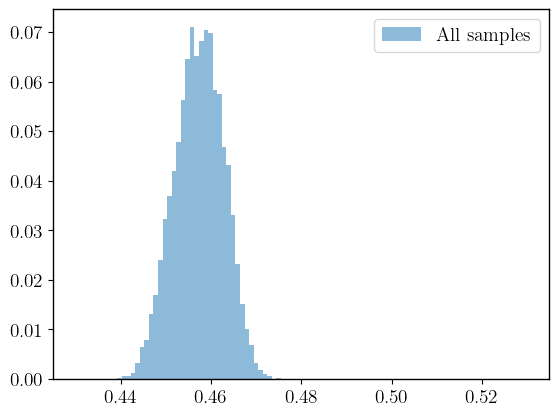

In [88]:
plt.hist(preds.samples, weights=preds.weights, bins=np.linspace(0.43,0.53,100), alpha=0.5, label='All samples')
plt.legend()
plt.show()

In [89]:
disp_values = np.array(preds.samples[:,0])
disp_mean   = np.average(disp_values, weights=preds.weights)
disp_std    = wstd(disp_values, weights=preds.weights)
print(f"Dispersive bound is {disp_mean:.4f} ± {disp_std:.4f}")

Dispersive bound is 0.4573 ± 0.0054


In [86]:
eos.tasks.predict_observables(af, posterior, "FF-fp2-I1-all", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order7-wi…

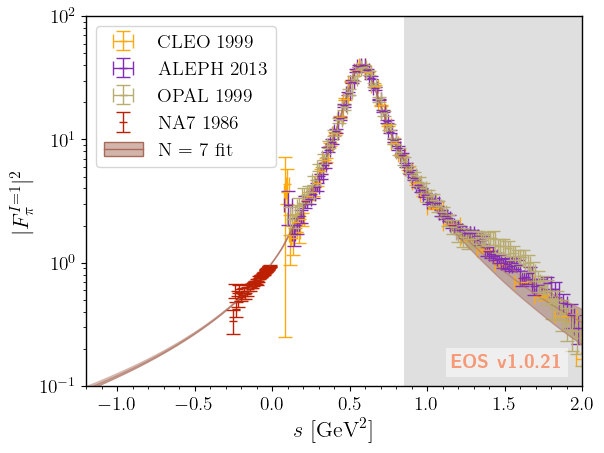

In [87]:
figure_args = {
'watermark': { 'position': 'lower right' },
'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [-1.2, 2.0] },
    'yaxis': { 'label': r'$|F^{I=1}_\pi|^2$', 'range': [ 0.1, 100.0], 'scale': 'log' },
    'legend': { 'position': 'upper left' },
    'items': [
    { 'type': 'constraint', 'label': 'CLEO 1999', 'color': colors[1],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',
        'constraints': '0->pipi::Abs{f_+}^2@CLEO:2000B',
    },
    { 'type': 'constraint', 'label': 'ALEPH 2013', 'color': colors[4],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',
        'constraints': '0->pipi::Abs{f_+}^2@ALEPH:2013A',
    },
    { 'type': 'constraint', 'label': 'OPAL 1999', 'color': colors[7],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',
        'constraints': '0->pipi::Abs{f_+}^2@OPAL:1999A',
    },
    { 'type': 'constraint', 'label': 'NA7 1986', 'color': colors[2],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2)',
        'constraints': '0->pipi::Abs{f_+}^2@NA7:1986A',
    },
    { 'type': 'uncertainty', 'label': 'N = 7 fit', 'color': colors[5],
        'variable': 'q2', 'range': [-1.2, 2.0], 'interpolation': 'cubic',
        'datafile': 'data/'+posterior+'/pred-FF-fp2-I1-all', 'resolution': 300
    },
    { 'type': 'band', 'color': 'gray', 'alpha': 0.25, 'x': [sIn, 2.0], 'y': [0.0, 100]}
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

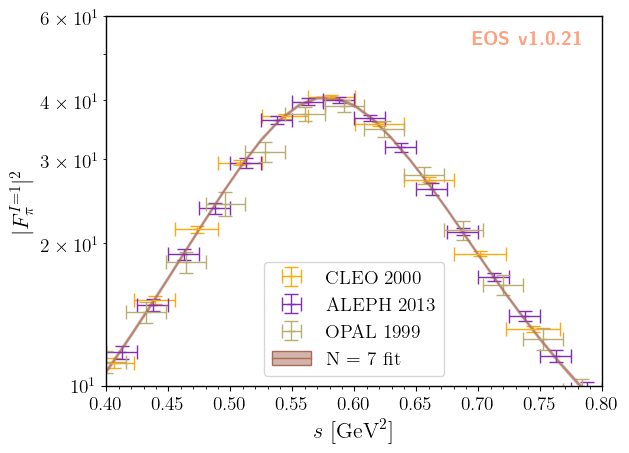

In [88]:
figure_args = {
'watermark': { 'position': 'upper right' },
'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [0.4, 0.8] },
    'yaxis': { 'label': r'$|F^{I=1}_\pi|^2$', 'range': [ 10.0, 60.0], 'scale': 'log' },
    'legend': { 'position': 'lower center' },
    'items': [
    { 'type': 'constraint', 'label': 'CLEO 2000', 'color': colors[1],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',
        'constraints': '0->pipi::Abs{f_+}^2@CLEO:2000B',
    },
    { 'type': 'constraint', 'label': 'ALEPH 2013', 'color': colors[4],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',
        'constraints': '0->pipi::Abs{f_+}^2@ALEPH:2013A',
    },
    { 'type': 'constraint', 'label': 'OPAL 1999', 'color': colors[7],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',
        'constraints': '0->pipi::Abs{f_+}^2@OPAL:1999A',
    },
    { 'type': 'uncertainty', 'label': 'N = 7 fit', 'color': colors[5],
        'variable': 'q2', 'range': [-1.2, 2.0], 'interpolation': 'cubic',
        'datafile': 'data/'+posterior+'/pred-FF-fp2-I1-all', 'resolution': 300
    }
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

In [94]:
get_gof(analysis, start_point)
param_dict = {p.name(): p.evaluate() for p in analysis.parameters}

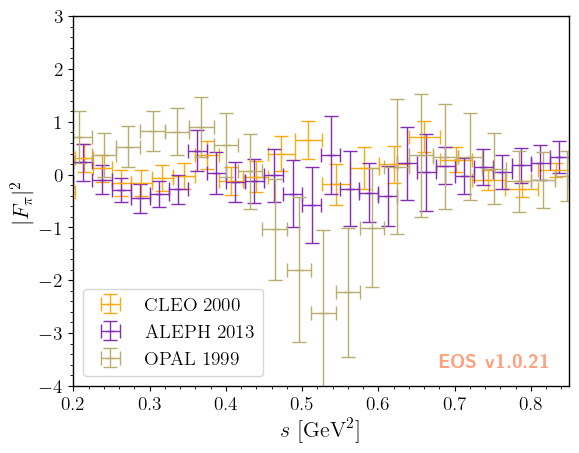

In [95]:
figure_args = {
'watermark': { 'position': 'lower right' },
'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [0.2, sIn] },
    'yaxis': { 'label': r'$|F_\pi|^2$', 'range': [ -4, 3], 'scale': 'linear' },
    'legend': { 'position': 'lower left' },
    'items': [
        { 'type': 'constraint-residue', 'label': 'CLEO 2000', 'parameters': param_dict, 'options': {"form-factors": "BHKMNR2026"},
          'color': colors[1], 'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)', 'style': 'delta', 'constraints': '0->pipi::Abs{f_+}^2@CLEO:2000B',
        },
        { 'type': 'constraint-residue', 'label': 'ALEPH 2013', 'parameters': param_dict, 'options': {"form-factors": "BHKMNR2026"},
          'color': colors[4], 'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',  'style': 'delta', 'constraints': '0->pipi::Abs{f_+}^2@ALEPH:2013A',
        },
        { 'type': 'constraint-residue', 'label': 'OPAL 1999', 'parameters': param_dict, 'options': {"form-factors": "BHKMNR2026"},
          'color': colors[7], 'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)', 'style': 'delta', 'constraints': '0->pipi::Abs{f_+}^2@OPAL:1999A',
        }
        ]
        }
        }
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

In [96]:
eos.tasks.predict_observables(af, posterior, "FF-arg-fp-I1-timelike", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order7-wi…

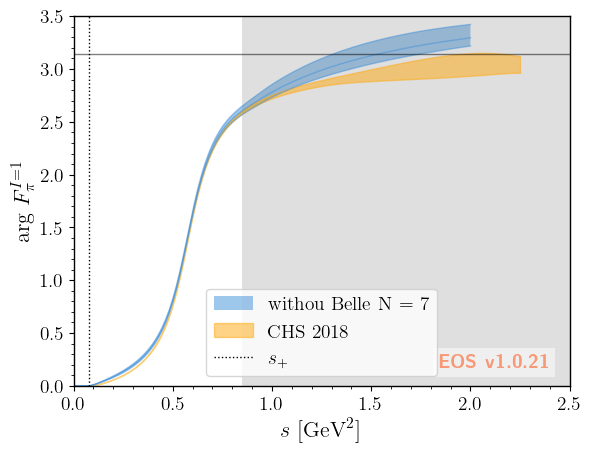

In [61]:
figure_args = {
  'watermark': { 'position': 'lower right' },
  'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [0.0, 2.5] },
    'yaxis': { 'label': r'arg $F^{I=1}_\pi$', 'range': [0.0 , 3.5] },
    'legend': { 'position': 'lower right' },
    'items': [
      { 'type': 'uncertainty', 'label': 'withou Belle N = 7', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-FF-arg-fp-I1-timelike', 'color': colors[0]
      },
      { 'type': 'band', 'color': 'gray', 'alpha': 0.25, 'x': [sIn, 2.5], 'y': [0.0, 3.5]},
      { 'type': 'expression', 'expression': 'np.pi', 'range': [0, 2.5], 'color': 'k'}
    ]
  }
}

figure = eos.figure.FigureFactory.from_dict(**figure_args)

q2_over_mpisquared, phase, err = np.loadtxt("scripts/d11-central.txt", skiprows=1, unpack=True)
q2 = q2_over_mpisquared * mpi**2
figure.draw()

ax = figure._ax
ax.fill_between(q2, phase - err, phase + err, label="CHS 2018", alpha=0.5, color=colors[1])

ax.axvline(x=sPlus, color='k', linestyle=':', linewidth=1.0, label=r'$s_+$')

ax.legend(loc="lower center")

In [98]:
get_gof(analysis, start_point)
analysis.parameters.dump('data/'+posterior+'/mode-default/parameters.yaml')

Handling item to plot 0->pipi::Arg{f_+}(Re{psi},Im{psi})@BHKMNR2026 in the complex plane
Overriding parameters from file
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,2)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(0,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(0,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,2)@KSvD2025' with central value '0'
[parameters.override] Overriding existing p

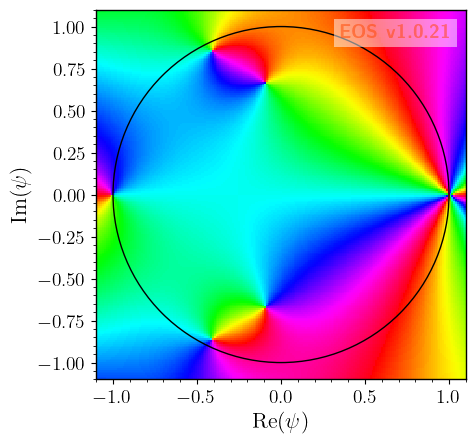

In [ ]:
figure_args = {
'plot': {
    'xaxis': { 'label': r'$\mathrm{Re}(\psi)$', 'range': [-1.1, 1.1] },
    'yaxis': { 'label': r'$\mathrm{Im}(\psi)$', 'range': [-1.1, 1.1] },
    # 'legend': { 'position': 'upper left' },
    'items': [
    { 'type': 'complex-plane', 'colormap': 'hsv', 'ranges': ((-1.1, +1.1), (-1.1, +1.1)),
        'variables': ["Re{psi}", "Im{psi}"], 'observable': "0->pipi::Arg{f_+}(Re{psi},Im{psi})@BHKMNR2026",
        'fixed_parameters_from_file': 'data/'+posterior+'/mode-default/parameters.yaml', 'resolution': 200
    }
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()
circle = plt.Circle((0, 0), 1.0, color='k', fill=False)
figure._ax.add_patch(circle)
figure._ax.set_aspect("equal", adjustable="box")


In [89]:
eos.tasks.predict_observables(af, posterior, "real-partial-wave-I1", base_directory=BASE_DIRECTORY)
eos.tasks.predict_observables(af, posterior, "imag-partial-wave-I1", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order7-wi…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order7-wi…

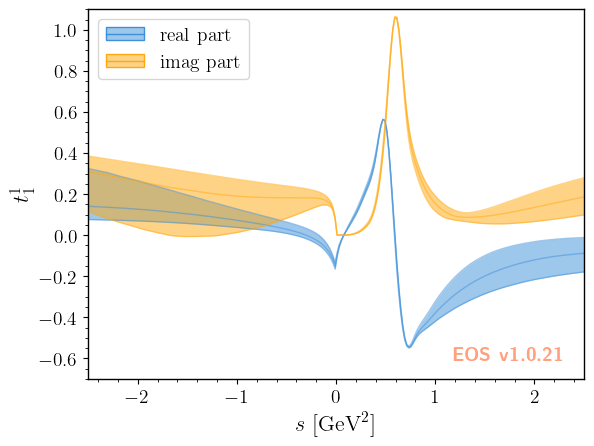

In [90]:
figure_args = {
  'watermark': { 'position': 'lower right' },
  'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [-2.5, 2.5] },
    'yaxis': { 'label': '$t_1^1$', 'range': [-0.7, 1.1]},
    'legend': { 'position': 'upper left' },
    'items': [
      { 'type': 'uncertainty', 'label': 'real part', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-real-partial-wave-I1'
      },
      { 'type': 'uncertainty', 'label': 'imag part', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-imag-partial-wave-I1'
      },
    ]
  }
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

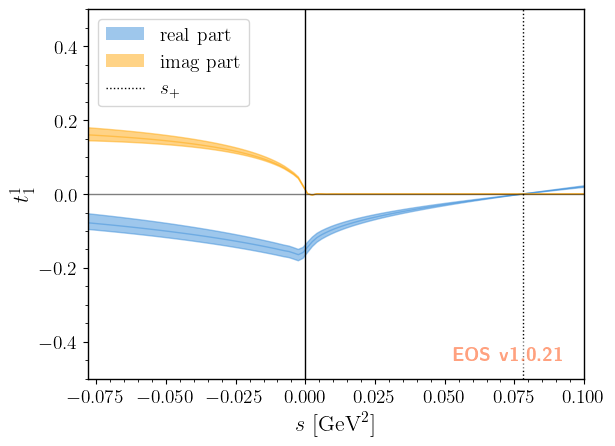

In [91]:
figure_args = {
  'watermark': { 'position': 'lower right' },
  'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [-sPlus, 0.1] },
    'yaxis': { 'label': '$t_1^1$', 'range': [-0.5, 0.5]},
    'legend': { 'position': 'upper left' },
    'items': [
      { 'type': 'uncertainty', 'label': 'real part', 'interpolation': 'cubic', 'resolution': 3000,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-real-partial-wave-I1'
      },
      { 'type': 'uncertainty', 'label': 'imag part', 'interpolation': 'cubic', 'resolution': 3000,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-imag-partial-wave-I1'
      },
      { 'type': 'expression', 'expression': '0', 'range': [-sPlus, 0.1], 'color': 'k'}
    ]
  }
}

figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()
ax = figure._ax
ax.axvline( x=0.0, color='k', linewidth=1.0)
ax.axvline( x=sPlus, color='k', linestyle=':', linewidth=1.0, label=r'$s_+$')
ax.legend(loc='upper left')

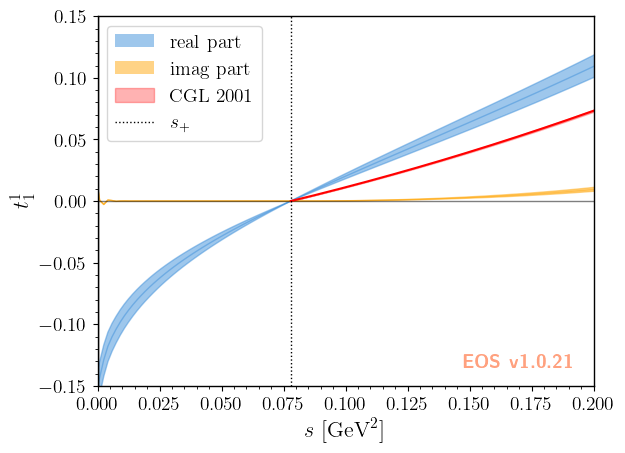

In [93]:
with np.load(theory_path) as saved:
    s_theory = saved['s']
    t_theory_samples = saved['t11']

# Calculate the band; the theory samples have equal weights.
t_lower, t_median, t_upper = np.quantile(
    t_theory_samples,
    [0.15865, 0.5, 0.84135],
    axis=0
)


figure_args = {
  'watermark': { 'position': 'lower right' },
  'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [0, 0.2] },
    'yaxis': { 'label': '$t_1^1$', 'range': [-0.15, 0.15]},
    'legend': { 'position': 'upper left' },
    'items': [
      { 'type': 'uncertainty', 'label': 'real part', 'interpolation': 'cubic', 'resolution': 3000,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-real-partial-wave-I1'
      },
      { 'type': 'uncertainty', 'label': 'imag part', 'interpolation': 'cubic', 'resolution': 3000,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-imag-partial-wave-I1'
      },
      { 'type': 'expression', 'expression': '0', 'range': [0, 0.2], 'color': 'k'}
    ]
  }
}

figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()
ax = figure._ax
# Add the theory band and median to the same axes.
ax.fill_between(
    s_theory,
    t_lower,
    t_upper,
    color='red',
    alpha=0.3,
    label='CGL 2001'
)

ax.plot(
    s_theory,
    t_median,
    color='red',
    linewidth=1.5
)

ax.axvline(x=0.0, color='k', linewidth=1.0)
ax.axvline(
    x=sPlus,
    color='k',
    linestyle=':',
    linewidth=1.0,
    label=r'$s_+$'
)

# Include the theory band and reference line in the legend.
ax.legend(loc='upper left')

In [94]:
# Analytic value of a11 and b11
eos.tasks.predict_observables(af, posterior, "FF-fp-I1-scattering-length-params", base_directory=BASE_DIRECTORY)
sl_params = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-FF-fp-I1-scattering-length-params'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order7-wi…

In [95]:
a11_values, b11_values = calculate_sl_values(sl_params)
(a11_mean, a11_std, b11_mean, b11_std) = summarize_sl_values("without Belle N = 7", a11_values, b11_values, sl_params.weights)

without Belle N = 7 a11 = 0.0734 ± 0.0078
without Belle N = 7 b11 = -0.0097 ± 0.0019


In [96]:
sl_samples_path = save_sl_samples(posterior, a11_values, b11_values, sl_params.weights)

Computing KDE for samples of variables 'derived::a11' and 'derived::b11'


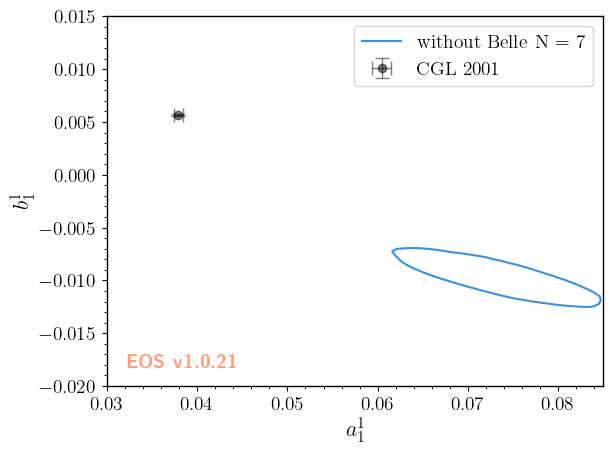

In [98]:
xrange = [0.03, 0.085]
yrange = [-0.02, 0.015]

figure_args = {
'watermark': { 'position': 'lower left' },
'plot': {
    'xaxis': { 'label': r'$a_1^1$', 'range': xrange },
    'yaxis': { 'label': r'$b_1^1$', 'range': yrange },
    'legend': { 'position': 'upper right' },
    'items': [
    { 'type': 'kde2D', 'label': 'without Belle N = 7', 'color': colors[0],
      'levels': [68], 'contours': ['lines'], 'bandwidth': 1.0,
      'datafile': sl_samples_path, 'xrange': xrange, 'yrange': yrange,
      'variables': ['derived::a11', 'derived::b11']
    },
    {'type': 'errorbars', 'positions': [[0.0379, 0.00567]], 'xerrors': [0.0005], 'yerrors': [0.00013], 'label': 'CGL 2001', 'color': 'black'}
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

In [106]:
# Charge radius
eos.tasks.predict_observables(af, posterior, "FF-fp-I1-pion-charge-radius-param", base_directory=BASE_DIRECTORY)
fprime_values = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-FF-fp-I1-pion-charge-radius-param'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order7-wi…

In [107]:
charge_radius_squared_values = np.array(list(map(charge_radius_squared_calculator, fprime_values.samples[:, 0])))
radius_mean = np.average(charge_radius_squared_values, weights=fprime_values.weights)
radius_std  = wstd(charge_radius_squared_values, weights=fprime_values.weights)
print(f"<r^2> = {radius_mean:.4f} ± {radius_std:.4f} fm^2")

<r^2> = 0.4387 ± 0.0050 fm^2


In [62]:
# Residue at the rho pole
eos.tasks.predict_observables(af, posterior, "re-rho-residue-psi", base_directory=BASE_DIRECTORY)
re_res_psi = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-re-rho-residue-psi'))
eos.tasks.predict_observables(af, posterior, "im-rho-residue-psi", base_directory=BASE_DIRECTORY)
im_res_psi = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-im-rho-residue-psi'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order7-wi…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order7-wi…

In [63]:
re_res = re_res_psi.samples[:,0]
im_res = im_res_psi.samples[:,0]
M      = f.samples[:,0]
Gamma  = f.samples[:,1]

print(len(re_res), len(im_res), len(M), len(Gamma)) # check that they have the same length

14090 14090 14090 14090


In [64]:
data = []

for r, i, m, g in zip(re_res, im_res, M, Gamma):
    data.append([r, i, m, g])
with open("residues_psi_wBelle7.wl", "w") as file:
    lines = [f"{{{r}, {i}, {m}, {g}}}" for r, i, m, g in data]
    file.write("{\n" + ",\n".join(lines) + "\n}")

In [ ]:
data = np.loadtxt("residues_s_wBelle7.csv", delimiter=",", ndmin=2,)

res_s = data[:, 0] + 1j * data[:, 1]

# Weighted complex mean
res_s_mean = np.average(res_s, weights=f.weights)

# Weighted standard deviations of the real and imaginary parts
std_re = np.sqrt(np.average((res_s.real - res_s_mean.real)**2, weights=f.weights))
std_im = np.sqrt(np.average((res_s.imag - res_s_mean.imag)**2, weights=f.weights))

print(
    f"residue at s_rho is "
    f"({res_s_mean.real:.4f} ± {std_re:.4f}) "
    f"+ i * ({res_s_mean.imag:.4f} ± {std_im:.4f})"
)

residue at s_rho is (-0.6923 ± 0.0114) + i * (0.1344 ± 0.0172)


In [66]:
# Computing g_{rho pi pi} and g_{rho gamma}
f_at_s_rho       = np.array([get_f_rho(s, analysis) for s in f.samples])
f_at_s_rho_value = f_at_s_rho[:,0] + 1j * f_at_s_rho[:,1]

In [67]:
s_rho       = (M - 1j * Gamma / 2)**2
g_rho_gamma = np.sqrt(24j * np.pi * s_rho / f_at_s_rho_value / res_s / (np.sqrt(1 - sPlus / s_rho))**3)
g_rho_pi_pi = (- res_s / s_rho) * g_rho_gamma

In [68]:
g_rho_gamma_mean = np.average(g_rho_gamma, weights=f.weights)
g_rho_gamma_std  = wstd(g_rho_gamma, weights=f.weights)
print(f"g_rho_gamma =  ({np.real(g_rho_gamma_mean):.4f} ± {np.real(g_rho_gamma_std):.4f}) + i * ({np.imag(g_rho_gamma_mean):.4f} ± {np.imag(g_rho_gamma_std):.4f})")

g_rho_pi_pi_mean = np.average(g_rho_pi_pi, weights=f.weights)
g_rho_pi_pi_std  = wstd(g_rho_pi_pi, weights=f.weights)
print(f"g_rho_pi_pi =  ({np.real(g_rho_pi_pi_mean):.4f} ± {np.real(g_rho_pi_pi_std):.4f}) + i * ({np.imag(g_rho_pi_pi_mean):.4f} ± {np.imag(g_rho_pi_pi_std):.4f})")

g_rho_gamma =  (4.9356 ± 0.0136) + i * (-0.2320 ± 0.0015)
g_rho_pi_pi =  (5.9497 ± 0.0359) + i * (-0.2909 ± 0.1258)


In [69]:
eos.tasks.predict_observables(af, posterior, "a_0", base_directory=BASE_DIRECTORY)
eos.tasks.predict_observables(af, posterior, "a_1", base_directory=BASE_DIRECTORY)
eos.tasks.predict_observables(af, posterior, "a_2", base_directory=BASE_DIRECTORY)
eos.tasks.predict_observables(af, posterior, "a_3", base_directory=BASE_DIRECTORY)

a0 = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-a_0'))
a1 = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-a_1'))
a2 = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-a_2'))
a3 = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-a_3'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order7-wi…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order7-wi…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order7-wi…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order7-wi…

In [70]:
all_coefs = np.column_stack([a0.samples, a1.samples, a2.samples, a3.samples,
                                                     f.samples[:,2], f.samples[:,3], f.samples[:,4], f.samples[:,5]])
np.shape(all_coefs)

(14090, 8)

In [71]:
# Compute weighted median and asymmetric 1-sigma intervals for each coefficient
n_coefs = all_coefs.shape[1]
labels = [f'$a_{i}$' for i in range(n_coefs)]

medians   = np.array([quantile_1D(all_coefs[:,i], f.weights, 0.50) for i in range(n_coefs)])
lo_1sigma = np.array([quantile_1D(all_coefs[:,i], f.weights, 0.16) for i in range(n_coefs)])
hi_1sigma = np.array([quantile_1D(all_coefs[:,i], f.weights, 0.84) for i in range(n_coefs)])

err_low  = medians - lo_1sigma   # downward bar length
err_high = hi_1sigma - medians   # upward bar length


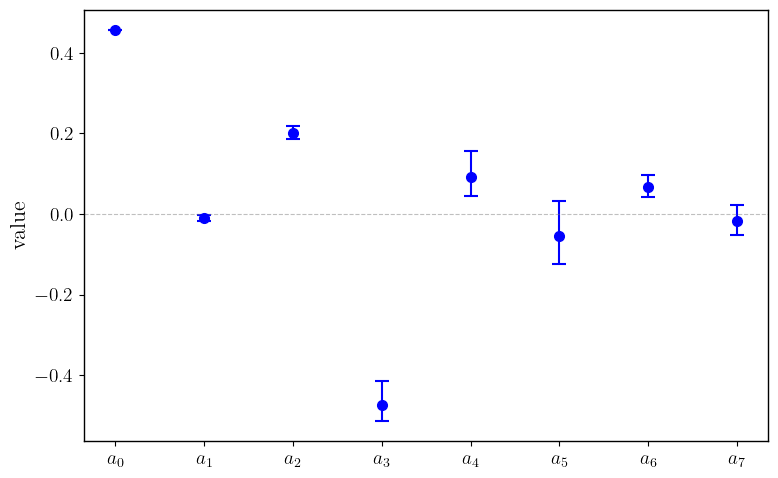

In [72]:
fig, ax = plt.subplots(figsize=(8, 5))
xs = np.arange(n_coefs)

ax.errorbar(xs, medians,
            yerr=[err_low, err_high],
            fmt='o', capsize=5, capthick=1.5, elinewidth=1.5,
            markersize=7, color='b', ecolor='b')

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xticks(xs)
ax.set_xticklabels(labels)
ax.set_ylabel('value')
plt.tight_layout()
plt.show()

## order 8 together

In [73]:
posterior = 'FF-fp-I1-order8-together'
analysis  = af.analysis(posterior)

Creating analysis with 7 priors, 5 EOS-wide constraints, 2 global options, 2 manually-entered constraints and 2 fixed parameters.
likelihood probably depends on 19 parameter(s) that do not appear in the prior; check prior?


In [74]:
start_point = [0.76182659,  0.1436174 ,  0.03605309, -0.23843887,  0.17031905,
       -0.10452357,  0.08303443]

In [75]:
get_gof(analysis, start_point)

In [137]:
bfp, gof = eos.tasks.find_mode(af, posterior, start_point=start_point, base_directory=BASE_DIRECTORY, optimizations=100)
#bfp, gof = eos.tasks.find_mode(af, posterior, importance_samples=True, base_directory=BASE_DIRECTORY, optimizations=100)
display(gof)
bfp.point

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8-to…

array([ 0.76182658,  0.14361735,  0.03606836, -0.23840291,  0.17025865,
       -0.10450803,  0.08299017])

In [76]:
if resample:
    eos.tasks.sample_nested(af, posterior, base_directory=BASE_DIRECTORY, bound='multi', nlive=200)

f = eos.data.ImportanceSamples(os.path.join(BASE_DIRECTORY, 'data', posterior, 'samples'))
print(f"Collected {f.samples.shape[0]} samples") #log z = 76.43

Collected 14738 samples


In [77]:
for i, p in enumerate(analysis.varied_parameters):
    mean = np.average(f.samples[:,i], weights=f.weights)
    std  = wstd(f.samples[:,i], weights=f.weights)
    print(f"      - {{ 'parameter': '{p.name()}', 'min':  {mean - 5*std:.5f}, 'max':  {mean + 5*std:.5f}, 'type': 'uniform'}}")

      - { 'parameter': '0->pipi::M_(+,1,0)@BHKMNR2026', 'min':  0.75930, 'max':  0.76482, 'type': 'uniform'}
      - { 'parameter': '0->pipi::Gamma_(+,1,0)@BHKMNR2026', 'min':  0.14024, 'max':  0.14700, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^4@BHKMNR2026', 'min':  -0.17548, 'max':  0.34448, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^5@BHKMNR2026', 'min':  -0.66037, 'max':  0.26939, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^6@BHKMNR2026', 'min':  -0.56989, 'max':  0.99482, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^7@BHKMNR2026', 'min':  -0.29965, 'max':  0.11768, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^8@BHKMNR2026', 'min':  -0.45749, 'max':  0.65134, 'type': 'uniform'}


Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8-to…

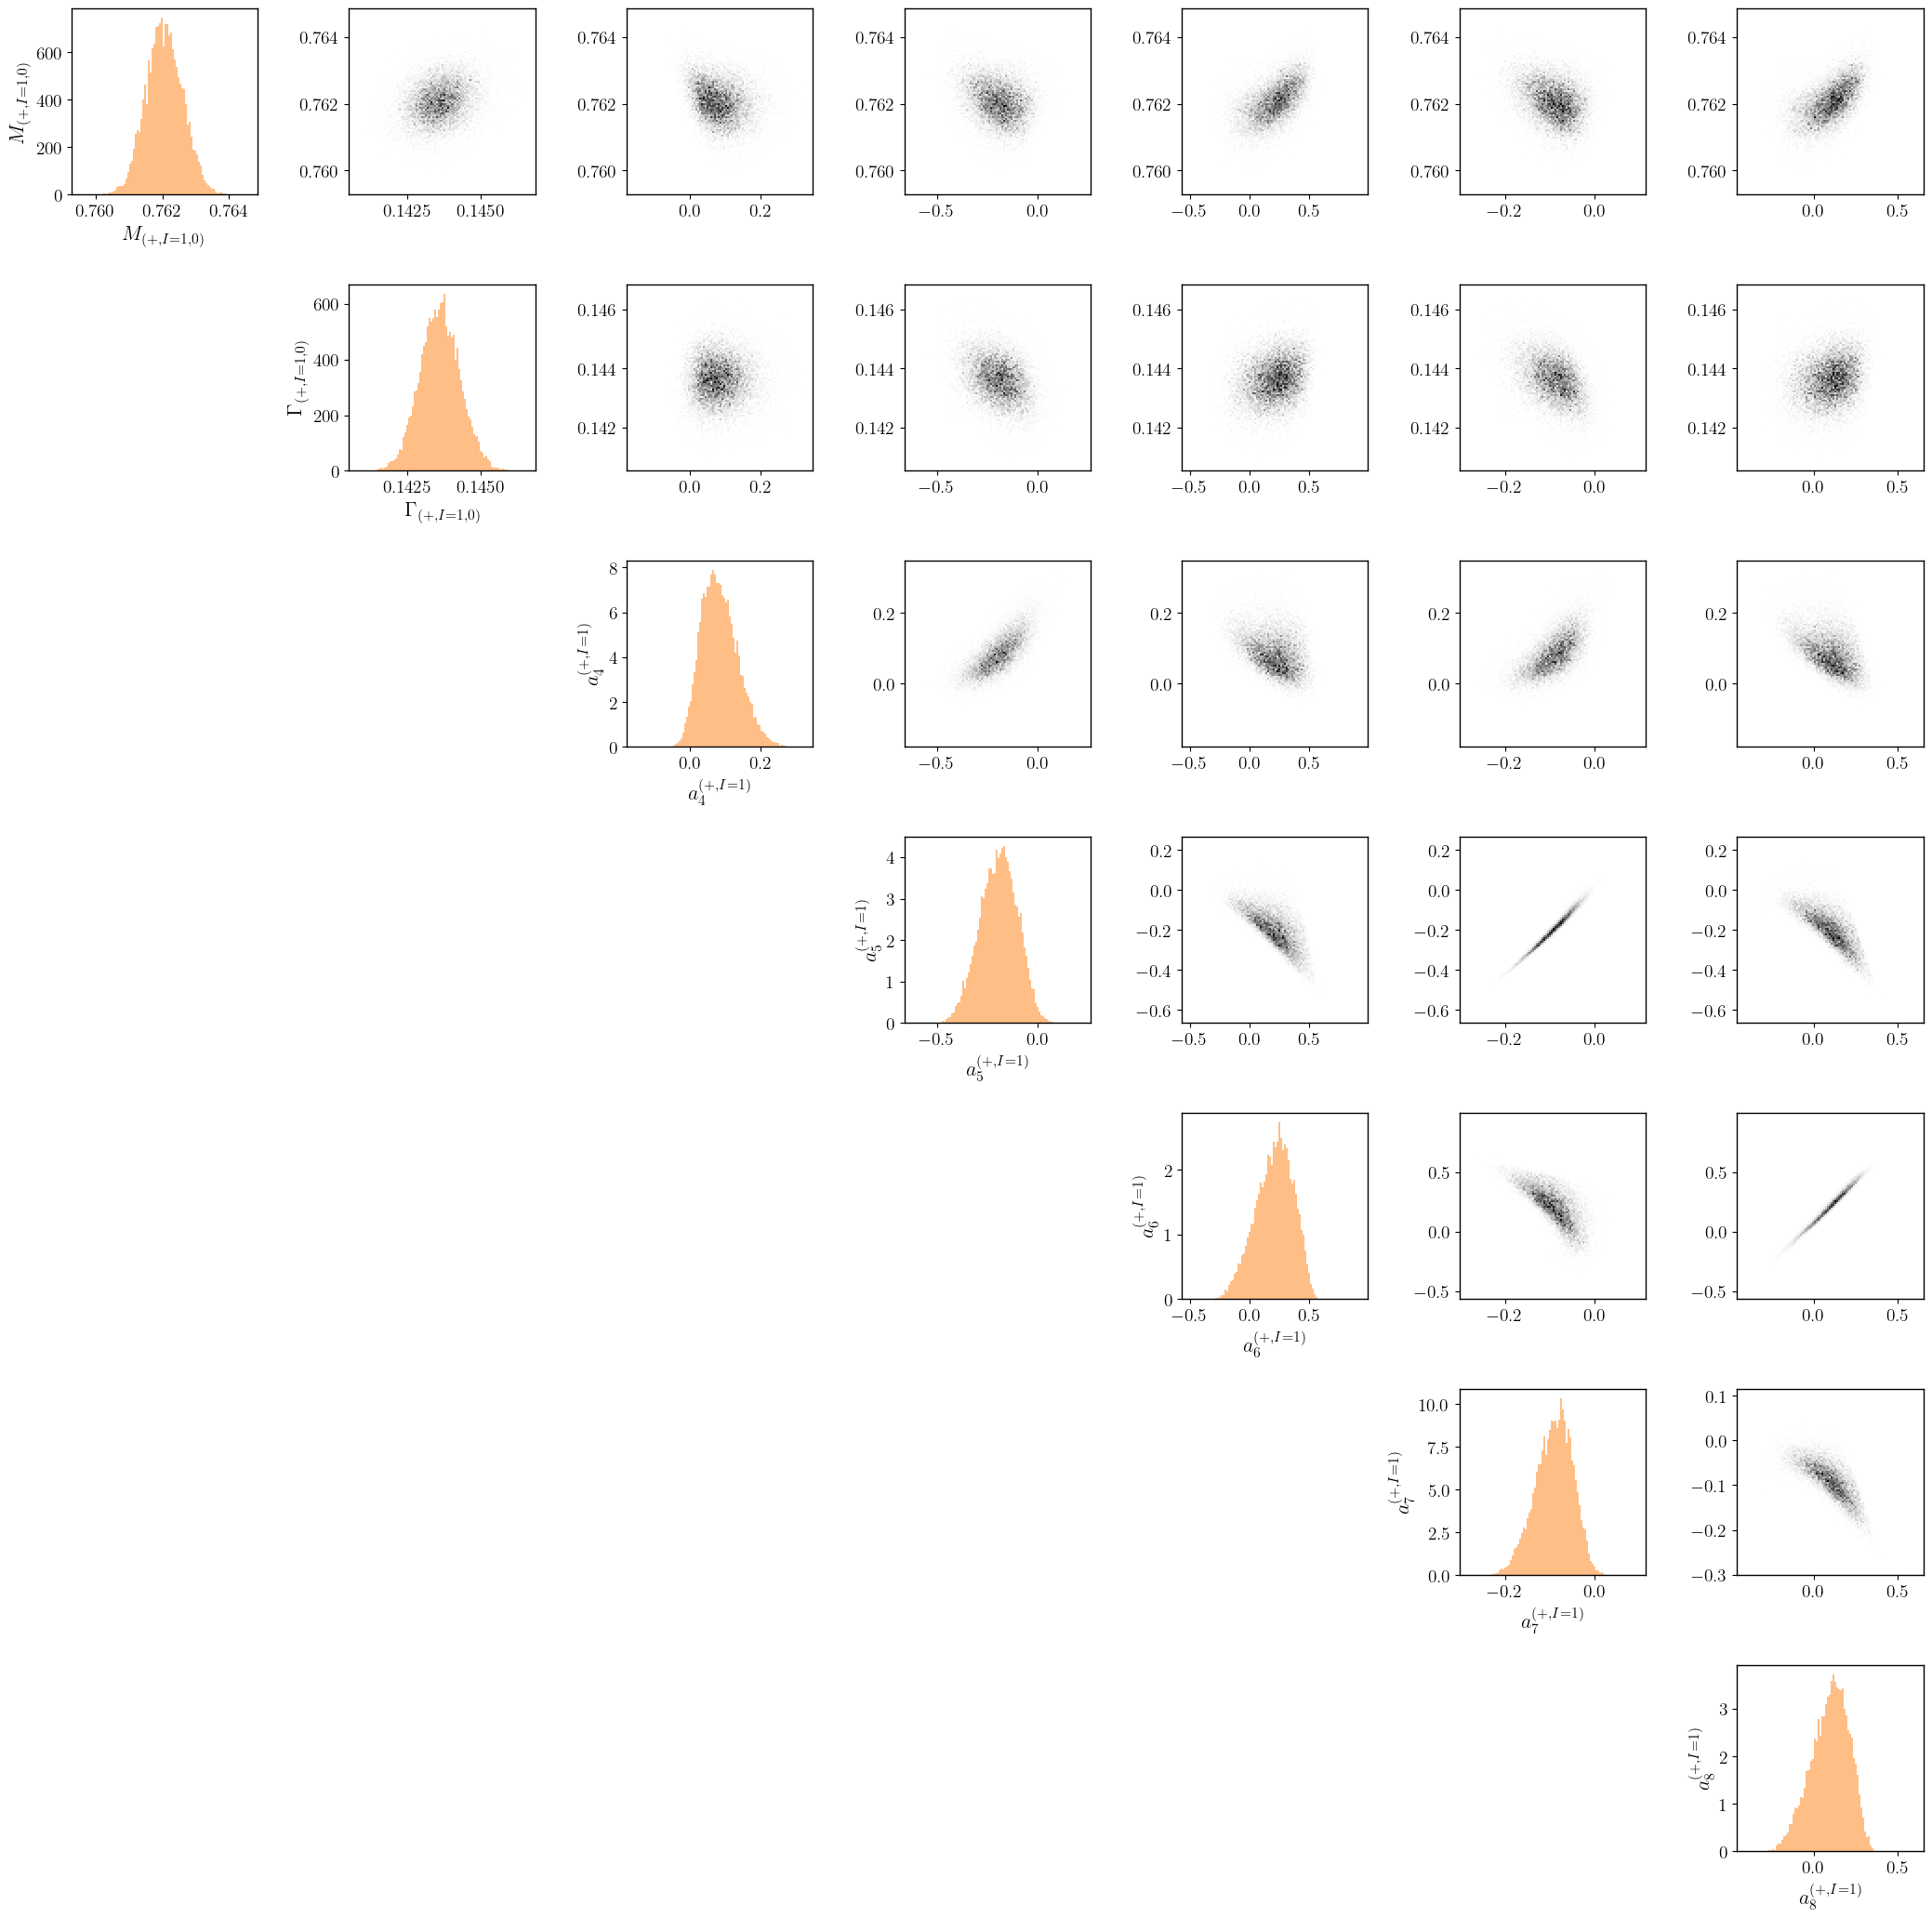

In [78]:
eos.tasks.corner_plot(af, posterior, base_directory=BASE_DIRECTORY)

In [79]:
print(f"rho mass  = {np.average(f.samples[:,0], weights=f.weights):.4f} ± {wstd(f.samples[:,0], weights=f.weights):.4f}")
print(f"rho width = {np.average(f.samples[:,1], weights=f.weights):.4f} ± {wstd(f.samples[:,1], weights=f.weights):.4f}")

rho mass  = 0.7621 ± 0.0006
rho width = 0.1436 ± 0.0007


Computing KDE for samples of variables '0->pipi::M_(+,1,0)@BHKMNR2026' and '0->pipi::Gamma_(+,1,0)@BHKMNR2026'


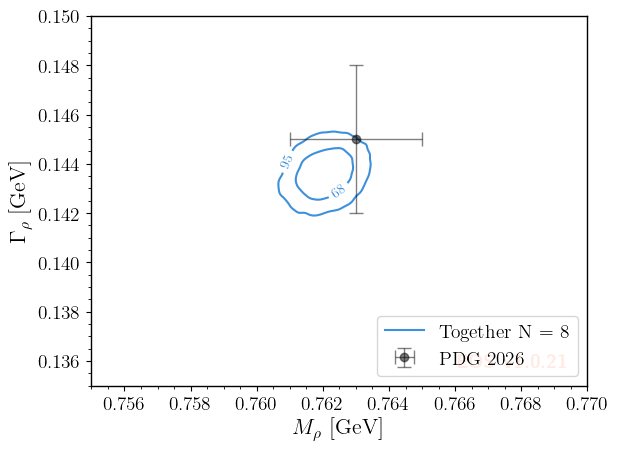

In [80]:
figure_args = {
'watermark': { 'position': 'lower right' },
'plot': {
    'xaxis': { 'label': r'$M_\rho$', 'unit': '$\\mathrm{GeV}$', 'range': [0.755, 0.77] },
    'yaxis': { 'label': r'$\Gamma_\rho$', 'unit': '$\\mathrm{GeV}$', 'range': [ 0.135, 0.15] },
    'legend': { 'position': 'lower right' },
    'items': [
    { 'type': 'kde2D', 'label': 'Together N = 8', 'color': colors[0],
      'levels': [68, 95], 'contours': ['lines', 'labels'],
      'datafile': 'data/'+posterior+'/samples',
      'variables': ['0->pipi::M_(+,1,0)@BHKMNR2026', '0->pipi::Gamma_(+,1,0)@BHKMNR2026']
    },
    {'type': 'errorbars', 'positions': [[0.763, 0.145]], 'xerrors': [0.002], 'yerrors': [0.003], 'label': 'PDG 2026', 'color': 'black'}
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

In [81]:
# Dispersive bound computation
eos.tasks.predict_observables(af, posterior, "FF-fp-I1-dispersive-bound", base_directory=BASE_DIRECTORY)
preds = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-FF-fp-I1-dispersive-bound'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8-to…

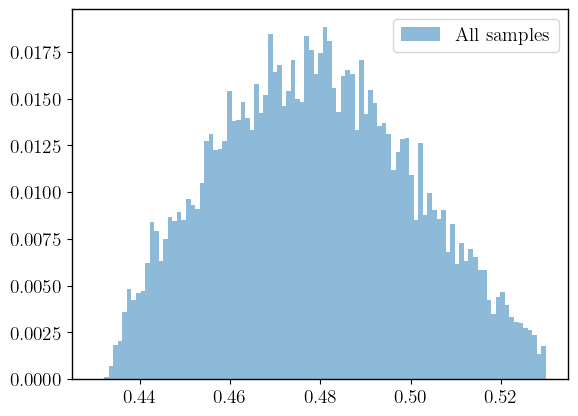

In [82]:
plt.hist(preds.samples, weights=preds.weights, bins=np.linspace(0.43,0.53,100), alpha=0.5, label='All samples')
plt.legend()
plt.show()

In [83]:
disp_values = np.array(preds.samples[:,0])
disp_mean   = np.average(disp_values, weights=preds.weights)
disp_std    = wstd(disp_values, weights=preds.weights)
print(f"Dispersive bound is {disp_mean:.4f} ± {disp_std:.4f}")

Dispersive bound is 0.4797 ± 0.0223


In [84]:
eos.tasks.predict_observables(af, posterior, "FF-fp2-I1-all", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8-to…

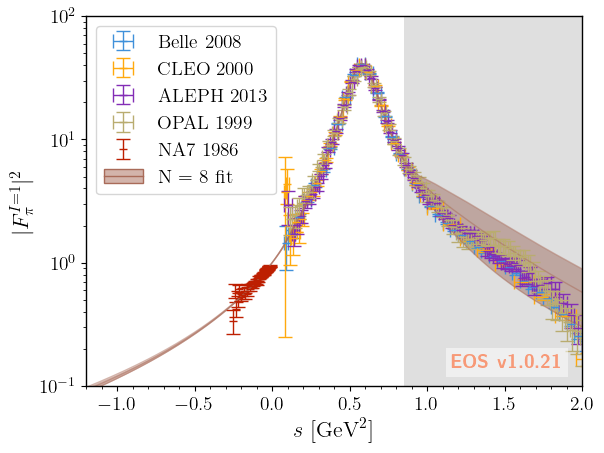

In [85]:
figure_args = {
'watermark': { 'position': 'lower right' },
'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [-1.2, 2.0] },
    'yaxis': { 'label': r'$|F^{I=1}_\pi|^2$', 'range': [ 0.1, 100.0], 'scale': 'log' },
    'legend': { 'position': 'upper left' },
    'items': [
    { 'type': 'constraint', 'label': 'Belle 2008', 'color': colors[0],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',
        'constraints': '0->pipi::Abs{f_+}^2@Belle:2008C',
    },
    { 'type': 'constraint', 'label': 'CLEO 2000', 'color': colors[1],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',
        'constraints': '0->pipi::Abs{f_+}^2@CLEO:2000B',
    },
    { 'type': 'constraint', 'label': 'ALEPH 2013', 'color': colors[4],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',
        'constraints': '0->pipi::Abs{f_+}^2@ALEPH:2013A',
    },
    { 'type': 'constraint', 'label': 'OPAL 1999', 'color': colors[7],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',
        'constraints': '0->pipi::Abs{f_+}^2@OPAL:1999A',
    },
    { 'type': 'constraint', 'label': 'NA7 1986', 'color': colors[2],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2)',
        'constraints': '0->pipi::Abs{f_+}^2@NA7:1986A',
    },
    { 'type': 'uncertainty', 'label': 'N = 8 fit', 'color': colors[5],
        'variable': 'q2', 'range': [-1.2, 2.0], 'interpolation': 'cubic',
        'datafile': 'data/'+posterior+'/pred-FF-fp2-I1-all', 'resolution': 300
    },
    { 'type': 'band', 'color': 'gray', 'alpha': 0.25, 'x': [sIn, 2.0], 'y': [0.0, 100]}
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

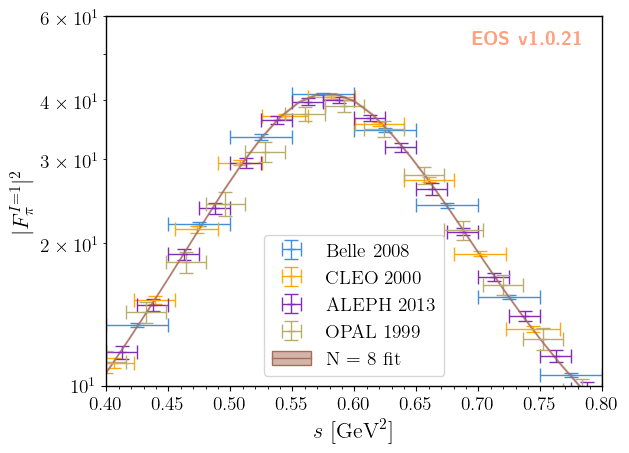

In [86]:
figure_args = {
'watermark': { 'position': 'upper right' },
'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [0.4, 0.8] },
    'yaxis': { 'label': r'$|F^{I=1}_\pi|^2$', 'range': [ 10.0, 60.0], 'scale': 'log' },
    'legend': { 'position': 'lower center' },
    'items': [
    { 'type': 'constraint', 'label': 'Belle 2008', 'color': colors[0],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',
        'constraints': '0->pipi::Abs{f_+}^2@Belle:2008C',
    },
    { 'type': 'constraint', 'label': 'CLEO 2000', 'color': colors[1],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',
        'constraints': '0->pipi::Abs{f_+}^2@CLEO:2000B',
    },
    { 'type': 'constraint', 'label': 'ALEPH 2013', 'color': colors[4],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',
        'constraints': '0->pipi::Abs{f_+}^2@ALEPH:2013A',
    },
    { 'type': 'constraint', 'label': 'OPAL 1999', 'color': colors[7],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',
        'constraints': '0->pipi::Abs{f_+}^2@OPAL:1999A',
    },
    { 'type': 'uncertainty', 'label': 'N = 8 fit', 'color': colors[5],
        'variable': 'q2', 'range': [-1.2, 2.0], 'interpolation': 'cubic',
        'datafile': 'data/'+posterior+'/pred-FF-fp2-I1-all', 'resolution': 300
    }
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

In [87]:
get_gof(analysis, start_point)
param_dict = {p.name(): p.evaluate() for p in analysis.parameters}

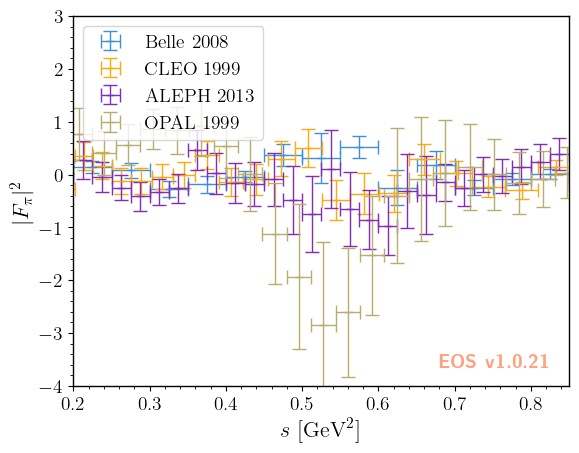

In [88]:
figure_args = {
'watermark': { 'position': 'lower right' },
'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [0.2, sIn] },
    'yaxis': { 'label': r'$|F_\pi|^2$', 'range': [-4, 3], 'scale': 'linear' },
    'legend': { 'position': 'upper left' },
    'items': [
        { 'type': 'constraint-residue', 'label': 'Belle 2008', 'parameters': param_dict, 'options': {"form-factors": "BHKMNR2026"},
          'color': colors[0],  'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)', 'style': 'delta', 'constraints': '0->pipi::Abs{f_+}^2@Belle:2008C',
        },
        { 'type': 'constraint-residue', 'label': 'CLEO 1999', 'parameters': param_dict, 'options': {"form-factors": "BHKMNR2026"},
          'color': colors[1], 'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)', 'style': 'delta', 'constraints': '0->pipi::Abs{f_+}^2@CLEO:2000B',
        },
        { 'type': 'constraint-residue', 'label': 'ALEPH 2013', 'parameters': param_dict, 'options': {"form-factors": "BHKMNR2026"},
          'color': colors[4], 'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',  'style': 'delta', 'constraints': '0->pipi::Abs{f_+}^2@ALEPH:2013A',
        },
        { 'type': 'constraint-residue', 'label': 'OPAL 1999', 'parameters': param_dict, 'options': {"form-factors": "BHKMNR2026"},
          'color': colors[7], 'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',  'style': 'delta', 'constraints': '0->pipi::Abs{f_+}^2@OPAL:1999A',
        }
        ]
        }
        }
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

In [89]:
eos.tasks.predict_observables(af, posterior, "FF-arg-fp-I1-timelike", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8-to…

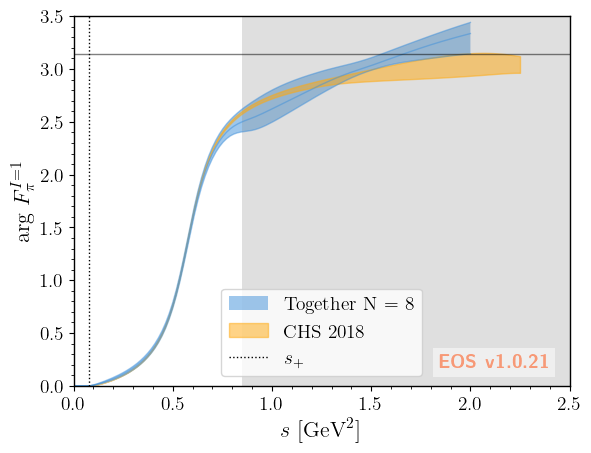

In [93]:
figure_args = {
  'watermark': { 'position': 'lower right' },
  'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [0.0, 2.5] },
    'yaxis': { 'label': r'arg $F^{I=1}_\pi$', 'range': [0.0 , 3.5] },
    'legend': { 'position': 'lower right' },
    'items': [
      { 'type': 'uncertainty', 'label': 'Together N = 8', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-FF-arg-fp-I1-timelike', 'color': colors[0]
      },
      { 'type': 'band', 'color': 'gray', 'alpha': 0.25, 'x': [sIn, 2.5], 'y': [0.0, 3.5]},
      { 'type': 'expression', 'expression': 'np.pi', 'range': [0, 2.5], 'color': 'k'}
    ]
  }
}

figure = eos.figure.FigureFactory.from_dict(**figure_args)

q2_over_mpisquared, phase, err = np.loadtxt("scripts/d11-central.txt", skiprows=1, unpack=True)
q2 = q2_over_mpisquared * mpi**2
figure.draw()

ax = figure._ax
ax.fill_between(q2, phase - err, phase + err, label="CHS 2018", alpha=0.5, color=colors[1])

ax.axvline(x=sPlus, color='k', linestyle=':', linewidth=1.0, label=r'$s_+$')

ax.legend(loc="lower center")

In [91]:
get_gof(analysis, start_point)
analysis.parameters.dump('data/'+posterior+'/mode-default/parameters.yaml')

Handling item to plot 0->pipi::Arg{f_+}(Re{psi},Im{psi})@BHKMNR2026 in the complex plane
Overriding parameters from file
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,2)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(0,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(0,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,2)@KSvD2025' with central value '0'
[parameters.override] Overriding existing p

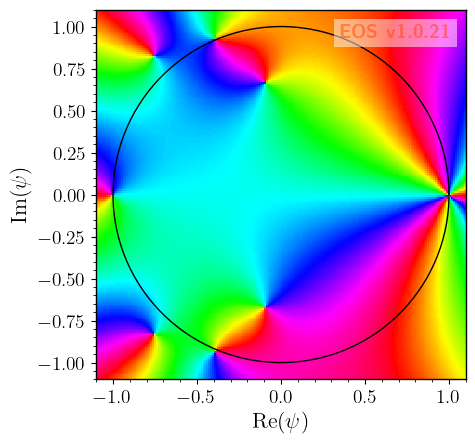

In [ ]:
figure_args = {
'plot': {
    'xaxis': { 'label': r'$\mathrm{Re}(\psi)$', 'range': [-1.1, 1.1] },
    'yaxis': { 'label': r'$\mathrm{Im}(\psi)$', 'range': [-1.1, 1.1] },
    # 'legend': { 'position': 'upper left' },
    'items': [
    { 'type': 'complex-plane', 'colormap': 'hsv', 'ranges': ((-1.1, +1.1), (-1.1, +1.1)),
        'variables': ["Re{psi}", "Im{psi}"], 'observable': "0->pipi::Arg{f_+}(Re{psi},Im{psi})@BHKMNR2026",
        'fixed_parameters_from_file': 'data/'+posterior+'/mode-default/parameters.yaml', 'resolution': 200
    }
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()
circle = plt.Circle((0, 0), 1.0, color='k', fill=False)
figure._ax.add_patch(circle)
figure._ax.set_aspect("equal", adjustable="box")


In [94]:
eos.tasks.predict_observables(af, posterior, "real-partial-wave-I1", base_directory=BASE_DIRECTORY)
eos.tasks.predict_observables(af, posterior, "imag-partial-wave-I1", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8-to…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8-to…

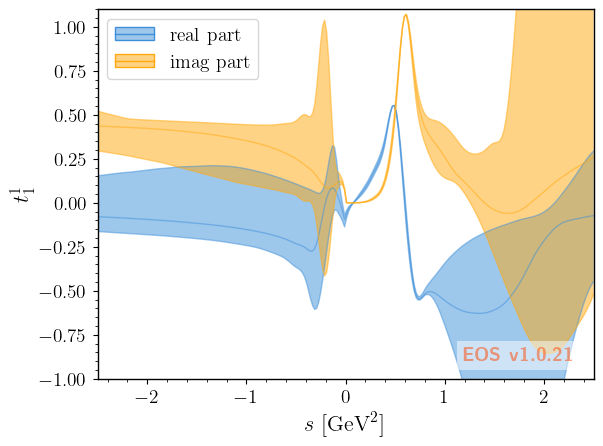

In [95]:
figure_args = {
  'watermark': { 'position': 'lower right' },
  'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [-2.5, 2.5] },
    'yaxis': { 'label': '$t_1^1$', 'range': [-1.0, 1.1]},
    'legend': { 'position': 'upper left' },
    'items': [
      { 'type': 'uncertainty', 'label': 'real part', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-real-partial-wave-I1'
      },
      { 'type': 'uncertainty', 'label': 'imag part', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-imag-partial-wave-I1'
      },
    ]
  }
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

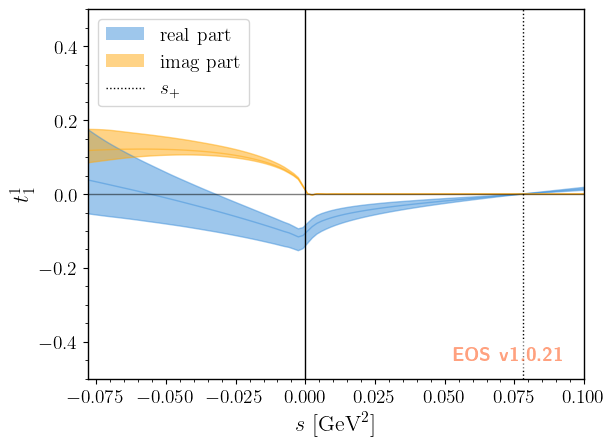

In [96]:
figure_args = {
  'watermark': { 'position': 'lower right' },
  'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [-sPlus, 0.1] },
    'yaxis': { 'label': '$t_1^1$', 'range': [-0.5, 0.5]},
    'legend': { 'position': 'upper left' },
    'items': [
      { 'type': 'uncertainty', 'label': 'real part', 'interpolation': 'cubic', 'resolution': 3000,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-real-partial-wave-I1'
      },
      { 'type': 'uncertainty', 'label': 'imag part', 'interpolation': 'cubic', 'resolution': 3000,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-imag-partial-wave-I1'
      },
      { 'type': 'expression', 'expression': '0', 'range': [-sPlus, 0.1], 'color': 'k'}
    ]
  }
}

figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()
ax = figure._ax
ax.axvline( x=0.0, color='k', linewidth=1.0)
ax.axvline( x=sPlus, color='k', linestyle=':', linewidth=1.0, label=r'$s_+$')
ax.legend(loc='upper left')

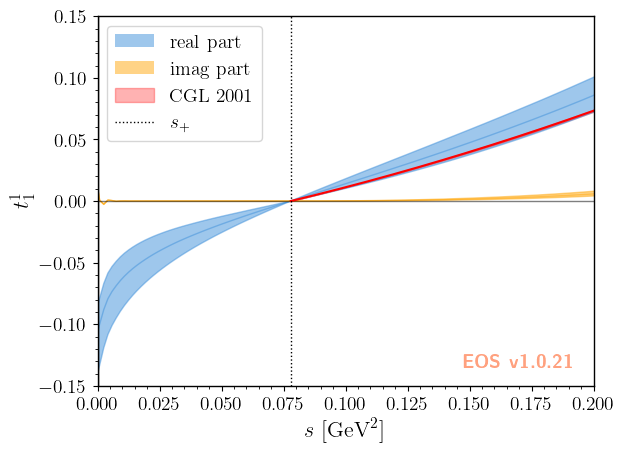

In [98]:
with np.load(theory_path) as saved:
    s_theory = saved['s']
    t_theory_samples = saved['t11']

# Calculate the band; the theory samples have equal weights.
t_lower, t_median, t_upper = np.quantile(
    t_theory_samples,
    [0.15865, 0.5, 0.84135],
    axis=0
)


figure_args = {
  'watermark': { 'position': 'lower right' },
  'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [0, 0.2] },
    'yaxis': { 'label': '$t_1^1$', 'range': [-0.15, 0.15]},
    'legend': { 'position': 'upper left' },
    'items': [
      { 'type': 'uncertainty', 'label': 'real part', 'interpolation': 'cubic', 'resolution': 3000,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-real-partial-wave-I1'
      },
      { 'type': 'uncertainty', 'label': 'imag part', 'interpolation': 'cubic', 'resolution': 3000,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-imag-partial-wave-I1'
      },
      { 'type': 'expression', 'expression': '0', 'range': [0, 0.2], 'color': 'k'}
    ]
  }
}

figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()
ax = figure._ax
# Add the theory band and median to the same axes.
ax.fill_between(
    s_theory,
    t_lower,
    t_upper,
    color='red',
    alpha=0.3,
    label='CGL 2001'
)

ax.plot(
    s_theory,
    t_median,
    color='red',
    linewidth=1.5
)

ax.axvline(x=0.0, color='k', linewidth=1.0)
ax.axvline(
    x=sPlus,
    color='k',
    linestyle=':',
    linewidth=1.0,
    label=r'$s_+$'
)

# Include the theory band and reference line in the legend.
ax.legend(loc='upper left')

In [100]:
# Analytic value of a11 and b11
eos.tasks.predict_observables(af, posterior, "FF-fp-I1-scattering-length-params", base_directory=BASE_DIRECTORY)
sl_params = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-FF-fp-I1-scattering-length-params'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8-to…

In [101]:
a11_values, b11_values = calculate_sl_values(sl_params)
(a11_mean, a11_std, b11_mean, b11_std) = summarize_sl_values("Together N = 8", a11_values, b11_values, sl_params.weights)

Together N = 8 a11 = 0.0501 ± 0.0152
Together N = 8 b11 = -0.0024 ± 0.0062


In [102]:
sl_samples_path = save_sl_samples(posterior, a11_values, b11_values, sl_params.weights)

Computing KDE for samples of variables 'derived::a11' and 'derived::b11'


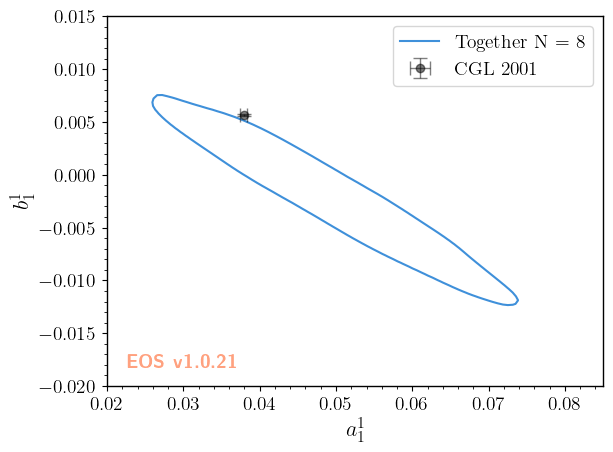

In [104]:
xrange = [0.02, 0.085]
yrange = [-0.02, 0.015]

figure_args = {
'watermark': { 'position': 'lower left' },
'plot': {
    'xaxis': { 'label': r'$a_1^1$', 'range': xrange },
    'yaxis': { 'label': r'$b_1^1$', 'range': yrange },
    'legend': { 'position': 'upper right' },
    'items': [
    { 'type': 'kde2D', 'label': 'Together N = 8', 'color': colors[0],
      'levels': [68], 'contours': ['lines'], 'bandwidth': 1.0,
      'datafile': sl_samples_path, 'xrange': xrange, 'yrange': yrange,
      'variables': ['derived::a11', 'derived::b11']
    },
    {'type': 'errorbars', 'positions': [[0.0379, 0.00567]], 'xerrors': [0.0005], 'yerrors': [0.00013], 'label': 'CGL 2001', 'color': 'black'}
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

In [105]:
# Charge radius
eos.tasks.predict_observables(af, posterior, "FF-fp-I1-pion-charge-radius-param", base_directory=BASE_DIRECTORY)
fprime_values = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-FF-fp-I1-pion-charge-radius-param'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8-to…

In [106]:
charge_radius_squared_values = np.array(list(map(charge_radius_squared_calculator, fprime_values.samples[:, 0])))
radius_mean = np.average(charge_radius_squared_values, weights=fprime_values.weights)
radius_std  = wstd(charge_radius_squared_values, weights=fprime_values.weights)
print(f"<r^2> = {radius_mean:.4f} ± {radius_std:.4f} fm^2")

<r^2> = 0.4290 ± 0.0048 fm^2


In [107]:
# Residue at the rho pole
eos.tasks.predict_observables(af, posterior, "re-rho-residue-psi", base_directory=BASE_DIRECTORY)
re_res_psi = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-re-rho-residue-psi'))
eos.tasks.predict_observables(af, posterior, "im-rho-residue-psi", base_directory=BASE_DIRECTORY)
im_res_psi = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-im-rho-residue-psi'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8-to…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8-to…

In [108]:
re_res = re_res_psi.samples[:,0]
im_res = im_res_psi.samples[:,0]
M      = f.samples[:,0]
Gamma  = f.samples[:,1]

print(len(re_res), len(im_res), len(M), len(Gamma)) # check that they have the same length

14738 14738 14738 14738


In [109]:
data = []

for r, i, m, g in zip(re_res, im_res, M, Gamma):
    data.append([r, i, m, g])
with open("residues_psi_together8.wl", "w") as file:
    lines = [f"{{{r}, {i}, {m}, {g}}}" for r, i, m, g in data]
    file.write("{\n" + ",\n".join(lines) + "\n}")

In [ ]:
data = np.loadtxt("residues_s_together8.csv", delimiter=",", ndmin=2,)

res_s = data[:, 0] + 1j * data[:, 1]


# Weighted complex mean
res_s_mean = np.average(res_s, weights=f.weights)

# Weighted standard deviations of the real and imaginary parts
std_re = np.sqrt(np.average((res_s.real - res_s_mean.real)**2, weights=f.weights))
std_im = np.sqrt(np.average((res_s.imag - res_s_mean.imag)**2, weights=f.weights))

print(
    f"residue at s_rho is "
    f"({res_s_mean.real:.4f} ± {std_re:.4f}) "
    f"+ i * ({res_s_mean.imag:.4f} ± {std_im:.4f})"
)

residue at s_rho is (-0.6828 ± 0.0123) + i * (0.1575 ± 0.0201)


In [111]:
# Computing g_{rho pi pi} and g_{rho gamma}
f_at_s_rho       = np.array([get_f_rho(s, analysis) for s in f.samples])
f_at_s_rho_value = f_at_s_rho[:,0] + 1j * f_at_s_rho[:,1]

In [112]:
s_rho       = (M - 1j * Gamma / 2)**2
g_rho_gamma = np.sqrt(24j * np.pi * s_rho / f_at_s_rho_value / res_s / (np.sqrt(1 - sPlus / s_rho))**3)
g_rho_pi_pi = (- res_s / s_rho) * g_rho_gamma

In [113]:
g_rho_gamma_mean = np.average(g_rho_gamma, weights=f.weights)
g_rho_gamma_std  = wstd(g_rho_gamma, weights=f.weights)
print(f"g_rho_gamma =  ({np.real(g_rho_gamma_mean):.4f} ± {np.real(g_rho_gamma_std):.4f}) + i * ({np.imag(g_rho_gamma_mean):.4f} ± {np.imag(g_rho_gamma_std):.4f})")

g_rho_pi_pi_mean = np.average(g_rho_pi_pi, weights=f.weights)
g_rho_pi_pi_std  = wstd(g_rho_pi_pi, weights=f.weights)
print(f"g_rho_pi_pi =  ({np.real(g_rho_pi_pi_mean):.4f} ± {np.real(g_rho_pi_pi_std):.4f}) + i * ({np.imag(g_rho_pi_pi_mean):.4f} ± {np.imag(g_rho_pi_pi_std):.4f})")

g_rho_gamma =  (4.9065 ± 0.0039) + i * (-0.2377 ± 0.0135)
g_rho_pi_pi =  (5.8527 ± 0.0778) + i * (-0.5117 ± 0.1786)


In [114]:
eos.tasks.predict_observables(af, posterior, "a_0", base_directory=BASE_DIRECTORY)
eos.tasks.predict_observables(af, posterior, "a_1", base_directory=BASE_DIRECTORY)
eos.tasks.predict_observables(af, posterior, "a_2", base_directory=BASE_DIRECTORY)
eos.tasks.predict_observables(af, posterior, "a_3", base_directory=BASE_DIRECTORY)

a0 = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-a_0'))
a1 = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-a_1'))
a2 = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-a_2'))
a3 = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-a_3'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8-to…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8-to…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8-to…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8-to…

In [115]:
all_coefs = np.column_stack([a0.samples, a1.samples, a2.samples, a3.samples,
                                                     f.samples[:,2], f.samples[:,3], f.samples[:,4], f.samples[:,5], f.samples[:,6]])
np.shape(all_coefs)

(14738, 9)

In [116]:
# Compute weighted median and asymmetric 1-sigma intervals for each coefficient
n_coefs = all_coefs.shape[1]
labels = [f'$a_{i}$' for i in range(n_coefs)]

medians   = np.array([quantile_1D(all_coefs[:,i], f.weights, 0.50) for i in range(n_coefs)])
lo_1sigma = np.array([quantile_1D(all_coefs[:,i], f.weights, 0.16) for i in range(n_coefs)])
hi_1sigma = np.array([quantile_1D(all_coefs[:,i], f.weights, 0.84) for i in range(n_coefs)])

err_low  = medians - lo_1sigma   # downward bar length
err_high = hi_1sigma - medians   # upward bar length


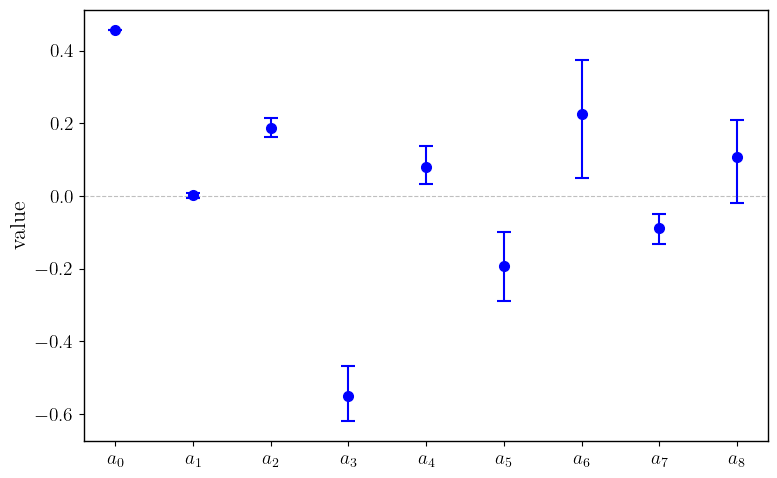

In [117]:
fig, ax = plt.subplots(figsize=(8, 5))
xs = np.arange(n_coefs)

ax.errorbar(xs, medians,
            yerr=[err_low, err_high],
            fmt='o', capsize=5, capthick=1.5, elinewidth=1.5,
            markersize=7, color='b', ecolor='b')

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xticks(xs)
ax.set_xticklabels(labels)
ax.set_ylabel('value')
plt.tight_layout()
plt.show()

## order 8 without Belle

In [118]:
posterior = 'FF-fp-I1-order8-without-Belle'
analysis  = af.analysis(posterior)

Creating analysis with 7 priors, 4 EOS-wide constraints, 2 global options, 2 manually-entered constraints and 2 fixed parameters.
likelihood probably depends on 19 parameter(s) that do not appear in the prior; check prior?


In [119]:
start_point = [0.76165068,  0.14338198,  0.03534931, -0.13345992,  0.2147269 ,
       -0.04790267,  0.11875053]

In [120]:
get_gof(analysis, start_point)

In [162]:
bfp, gof = eos.tasks.find_mode(af, posterior, start_point=start_point, base_directory=BASE_DIRECTORY, optimizations=100)
#bfp, gof = eos.tasks.find_mode(af, posterior, importance_samples=True, base_directory=BASE_DIRECTORY, optimizations=100)
display(gof)
bfp.point

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8-wi…

array([ 0.76165068,  0.14338198,  0.03534931, -0.13345992,  0.2147269 ,
       -0.04790267,  0.11875053])

In [121]:
if resample:
    eos.tasks.sample_nested(af, posterior, base_directory=BASE_DIRECTORY, bound='multi', nlive=200)

f = eos.data.ImportanceSamples(os.path.join(BASE_DIRECTORY, 'data', posterior, 'samples'))
print(f"Collected {f.samples.shape[0]} samples") #log z = 91.88

Collected 15571 samples


In [160]:
for i, p in enumerate(analysis.varied_parameters):
    mean = np.average(f.samples[:,i], weights=f.weights)
    std  = wstd(f.samples[:,i], weights=f.weights)
    print(f"      - {{ 'parameter': '{p.name()}', 'min':  {mean - 5*std:.5f}, 'max':  {mean + 5*std:.5f}, 'type': 'uniform'}}")

      - { 'parameter': '0->pipi::M_(+,1,0)@BHKMNR2026', 'min':  0.75821, 'max':  0.76495, 'type': 'uniform'}
      - { 'parameter': '0->pipi::Gamma_(+,1,0)@BHKMNR2026', 'min':  0.13824, 'max':  0.15195, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^4@BHKMNR2026', 'min':  -0.23409, 'max':  0.40881, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^5@BHKMNR2026', 'min':  -0.68750, 'max':  0.49770, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^6@BHKMNR2026', 'min':  -0.77665, 'max':  1.08723, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^7@BHKMNR2026', 'min':  -0.31036, 'max':  0.23119, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^8@BHKMNR2026', 'min':  -0.59802, 'max':  0.72061, 'type': 'uniform'}


Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8-wi…

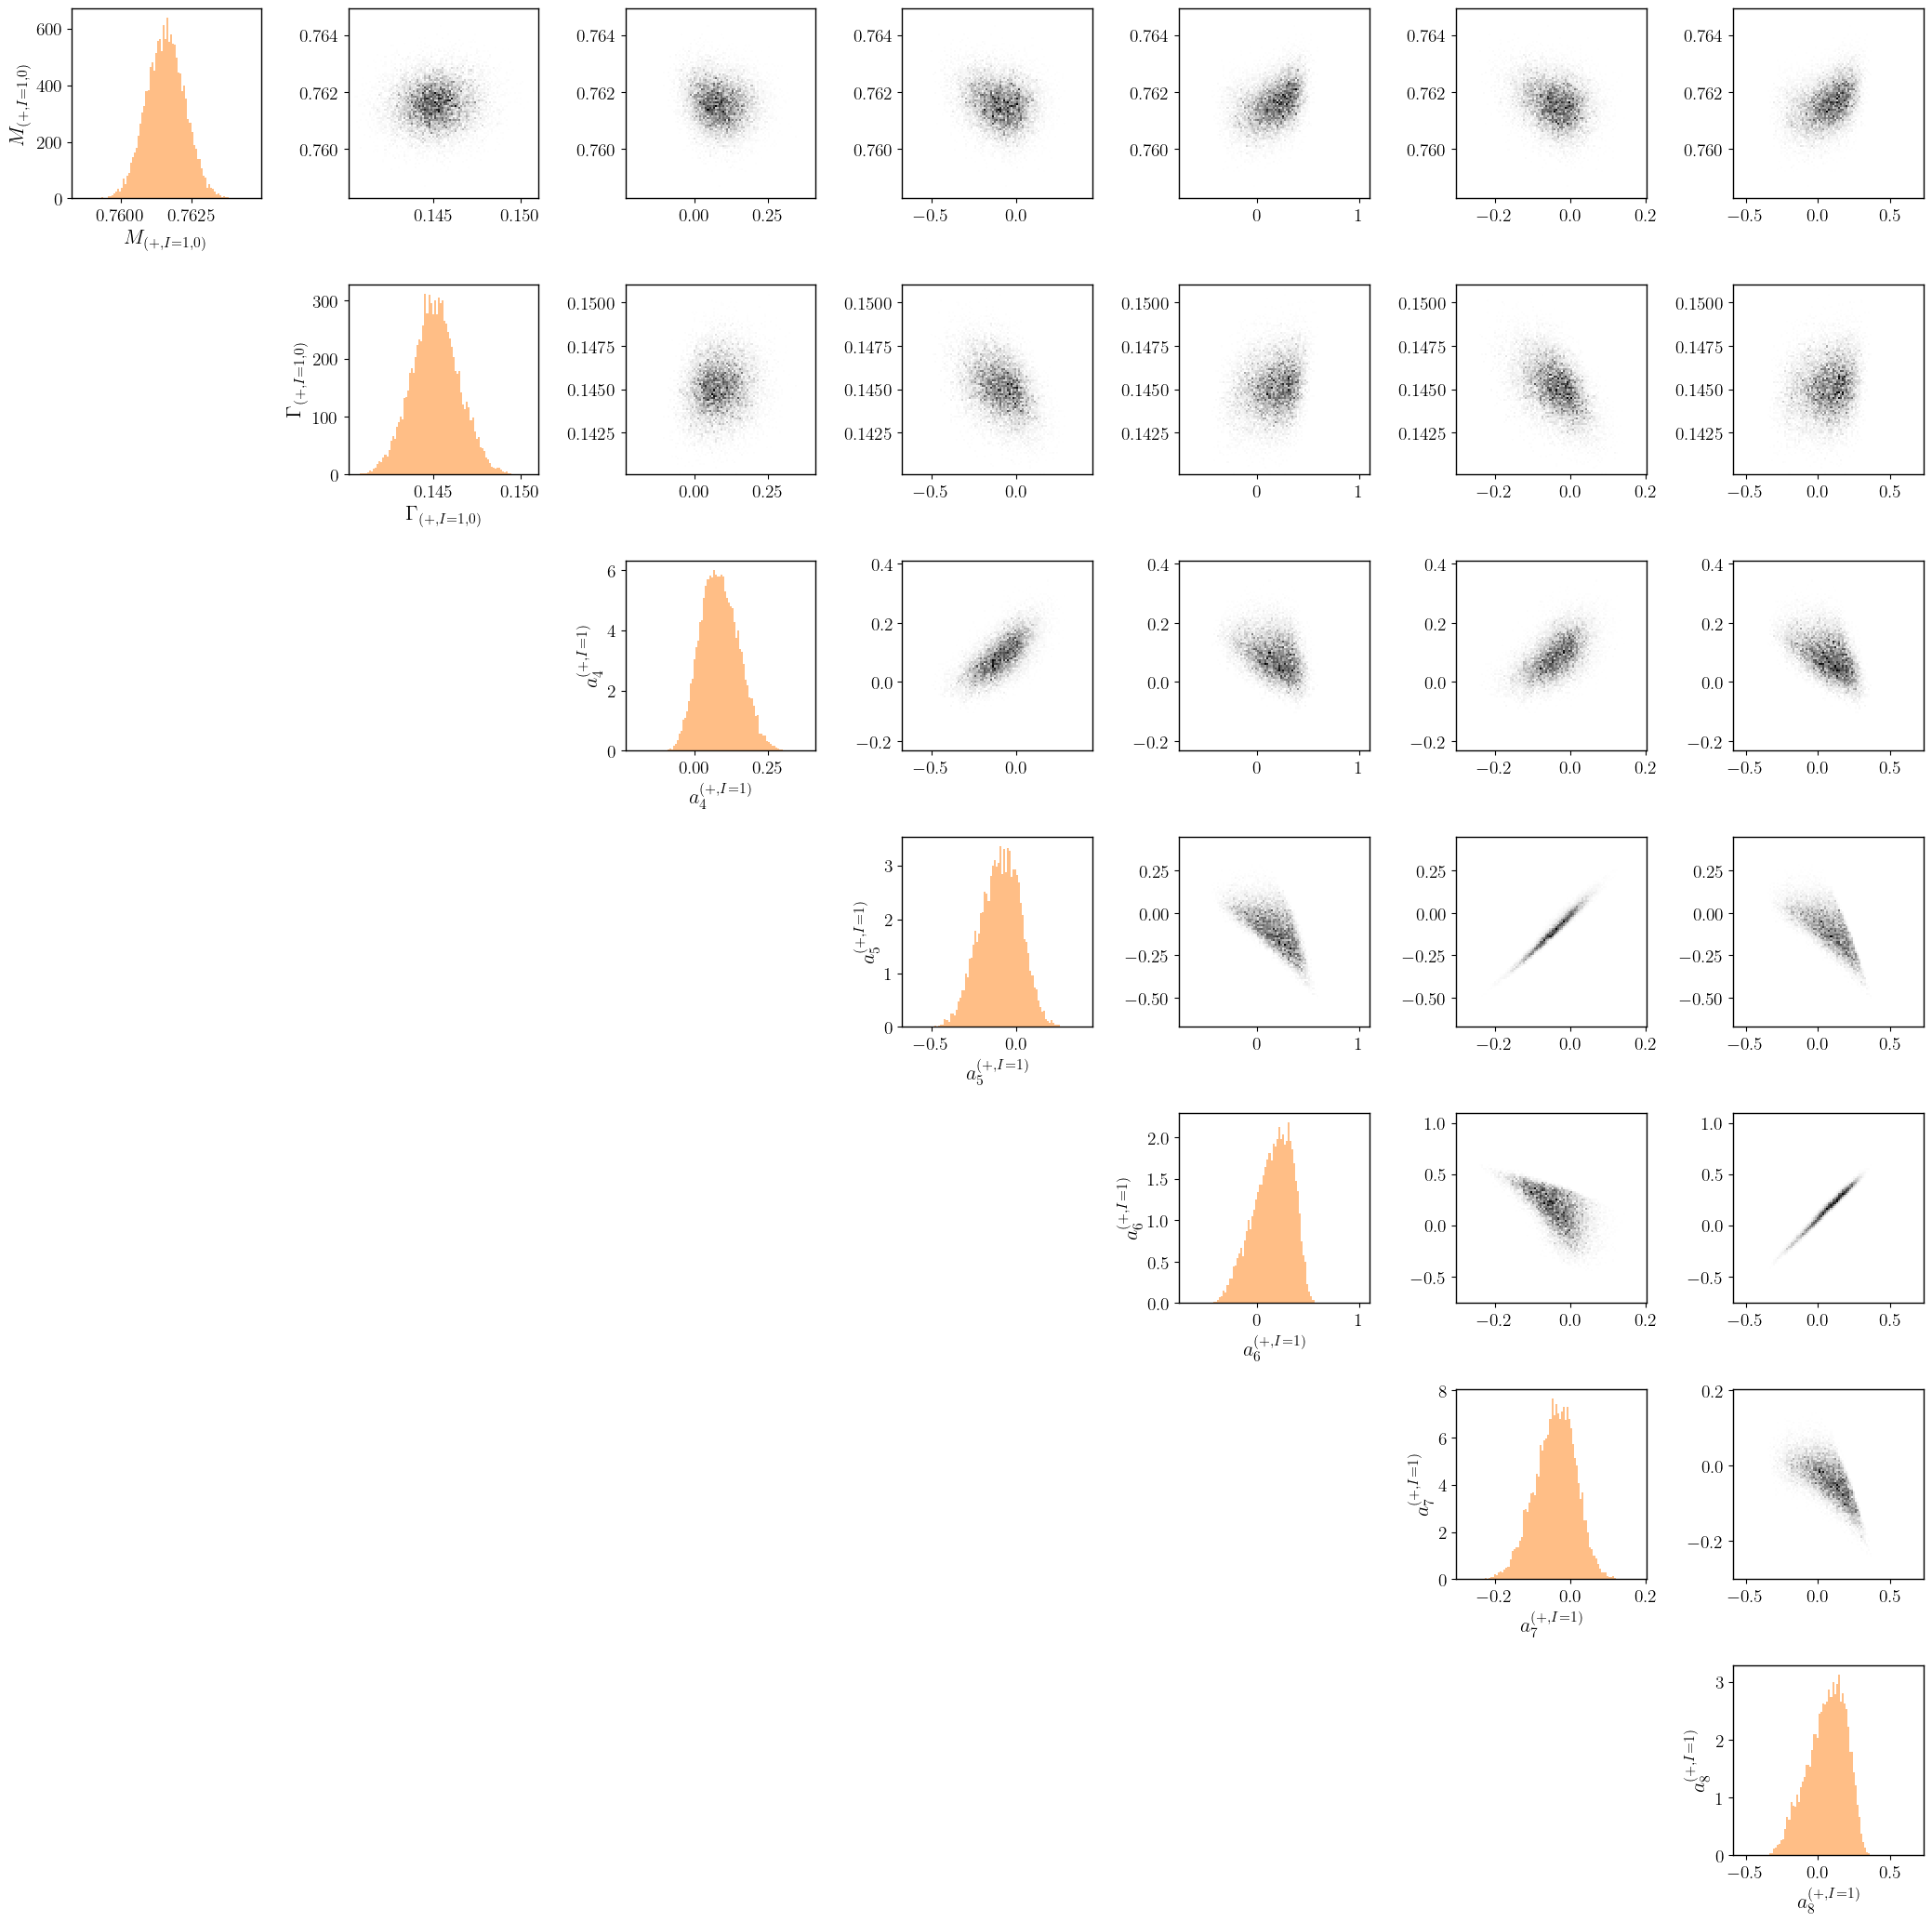

In [161]:
eos.tasks.corner_plot(af, posterior, base_directory=BASE_DIRECTORY)

In [67]:
print(f"rho mass  = {np.average(f.samples[:,0], weights=f.weights):.4f} ± {wstd(f.samples[:,0], weights=f.weights):.4f}")
print(f"rho width = {np.average(f.samples[:,1], weights=f.weights):.4f} ± {wstd(f.samples[:,1], weights=f.weights):.4f}")

rho mass  = 0.7616 ± 0.0007
rho width = 0.1451 ± 0.0014


Computing KDE for samples of variables '0->pipi::M_(+,1,0)@BHKMNR2026' and '0->pipi::Gamma_(+,1,0)@BHKMNR2026'


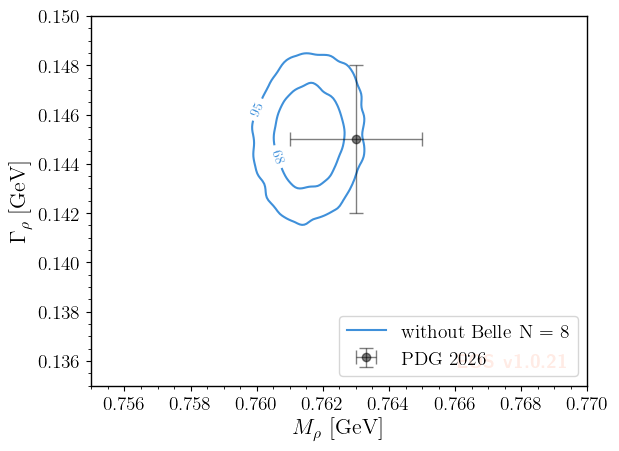

In [68]:
figure_args = {
'watermark': { 'position': 'lower right' },
'plot': {
    'xaxis': { 'label': r'$M_\rho$', 'unit': '$\\mathrm{GeV}$', 'range': [0.755, 0.77] },
    'yaxis': { 'label': r'$\Gamma_\rho$', 'unit': '$\\mathrm{GeV}$', 'range': [ 0.135, 0.15] },
    'legend': { 'position': 'lower right' },
    'items': [
    { 'type': 'kde2D', 'label': 'without Belle N = 8', 'color': colors[0],
      'levels': [68, 95], 'contours': ['lines', 'labels'],
      'datafile': 'data/'+posterior+'/samples',
      'variables': ['0->pipi::M_(+,1,0)@BHKMNR2026', '0->pipi::Gamma_(+,1,0)@BHKMNR2026']
    },
    {'type': 'errorbars', 'positions': [[0.763, 0.145]], 'xerrors': [0.002], 'yerrors': [0.003], 'label': 'PDG 2026', 'color': 'black'}
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

In [166]:
# Dispersive bound computation
eos.tasks.predict_observables(af, posterior, "FF-fp-I1-dispersive-bound", base_directory=BASE_DIRECTORY)
preds = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-FF-fp-I1-dispersive-bound'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8-wi…

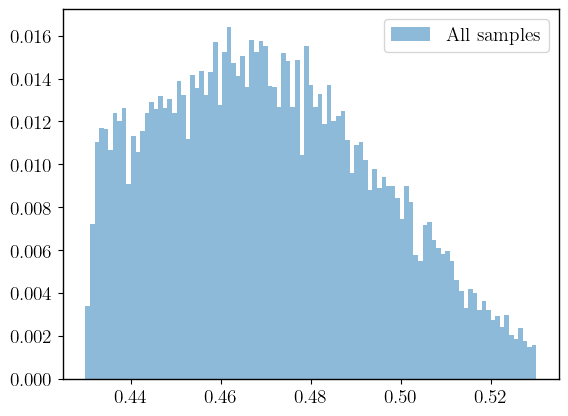

In [167]:
plt.hist(preds.samples, weights=preds.weights, bins=np.linspace(0.43,0.53,100), alpha=0.5, label='All samples')
plt.legend()
plt.show()

In [168]:
disp_values = np.array(preds.samples[:,0])
disp_mean   = np.average(disp_values, weights=preds.weights)
disp_std    = wstd(disp_values, weights=preds.weights)
print(f"Dispersive bound is {disp_mean:.4f} ± {disp_std:.4f}")

Dispersive bound is 0.4717 ± 0.0246


In [102]:
eos.tasks.predict_observables(af, posterior, "FF-fp2-I1-all", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8-wi…

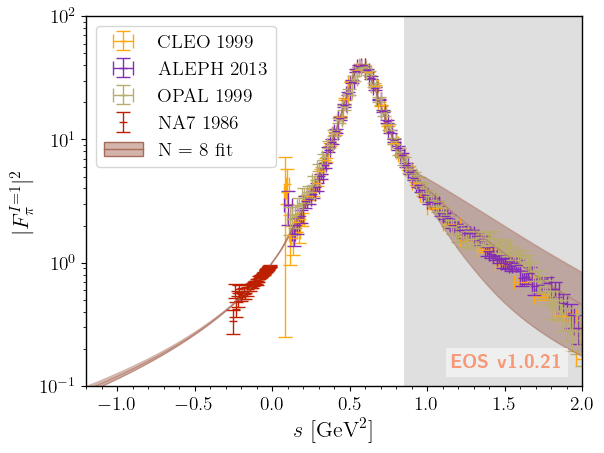

In [103]:
figure_args = {
'watermark': { 'position': 'lower right' },
'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [-1.2, 2.0] },
    'yaxis': { 'label': r'$|F^{I=1}_\pi|^2$', 'range': [ 0.1, 100.0], 'scale': 'log' },
    'legend': { 'position': 'upper left' },
    'items': [
    { 'type': 'constraint', 'label': 'CLEO 1999', 'color': colors[1],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',
        'constraints': '0->pipi::Abs{f_+}^2@CLEO:2000B',
    },
    { 'type': 'constraint', 'label': 'ALEPH 2013', 'color': colors[4],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',
        'constraints': '0->pipi::Abs{f_+}^2@ALEPH:2013A',
    },
    { 'type': 'constraint', 'label': 'OPAL 1999', 'color': colors[7],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',
        'constraints': '0->pipi::Abs{f_+}^2@OPAL:1999A',
    },
    { 'type': 'constraint', 'label': 'NA7 1986', 'color': colors[2],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2)',
        'constraints': '0->pipi::Abs{f_+}^2@NA7:1986A',
    },
    { 'type': 'uncertainty', 'label': 'N = 8 fit', 'color': colors[5],
        'variable': 'q2', 'range': [-1.2, 2.0], 'interpolation': 'cubic',
        'datafile': 'data/'+posterior+'/pred-FF-fp2-I1-all', 'resolution': 300
    },
    { 'type': 'band', 'color': 'gray', 'alpha': 0.25, 'x': [sIn, 2.0], 'y': [0.0, 100]}
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

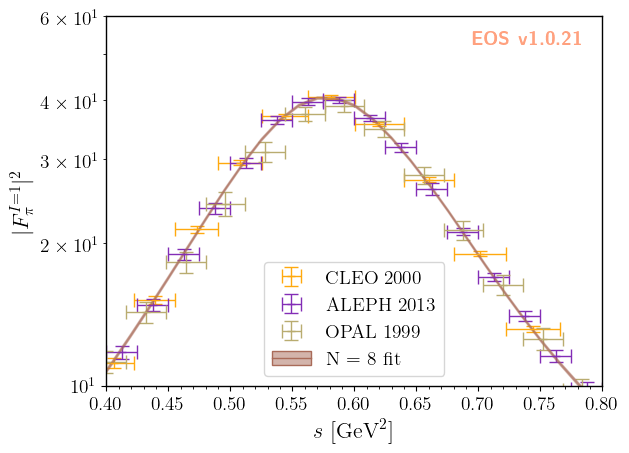

In [104]:
figure_args = {
'watermark': { 'position': 'upper right' },
'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [0.4, 0.8] },
    'yaxis': { 'label': r'$|F^{I=1}_\pi|^2$', 'range': [ 10.0, 60.0], 'scale': 'log' },
    'legend': { 'position': 'lower center' },
    'items': [
    { 'type': 'constraint', 'label': 'CLEO 2000', 'color': colors[1],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',
        'constraints': '0->pipi::Abs{f_+}^2@CLEO:2000B',
    },
    { 'type': 'constraint', 'label': 'ALEPH 2013', 'color': colors[4],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',
        'constraints': '0->pipi::Abs{f_+}^2@ALEPH:2013A',
    },
    { 'type': 'constraint', 'label': 'OPAL 1999', 'color': colors[7],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',
        'constraints': '0->pipi::Abs{f_+}^2@OPAL:1999A',
    },
    { 'type': 'uncertainty', 'label': 'N = 8 fit', 'color': colors[5],
        'variable': 'q2', 'range': [-1.2, 2.0], 'interpolation': 'cubic',
        'datafile': 'data/'+posterior+'/pred-FF-fp2-I1-all', 'resolution': 300
    }
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

In [172]:
get_gof(analysis, start_point)
param_dict = {p.name(): p.evaluate() for p in analysis.parameters}

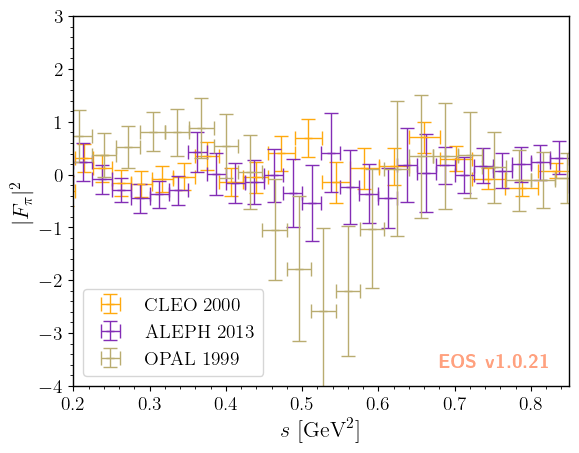

In [173]:
figure_args = {
'watermark': { 'position': 'lower right' },
'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [0.2, sIn] },
    'yaxis': { 'label': r'$|F_\pi|^2$', 'range': [ -4, 3], 'scale': 'linear' },
    'legend': { 'position': 'lower left' },
    'items': [
        { 'type': 'constraint-residue', 'label': 'CLEO 2000', 'parameters': param_dict, 'options': {"form-factors": "BHKMNR2026"},
          'color': colors[1], 'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)', 'style': 'delta', 'constraints': '0->pipi::Abs{f_+}^2@CLEO:2000B',
        },
        { 'type': 'constraint-residue', 'label': 'ALEPH 2013', 'parameters': param_dict, 'options': {"form-factors": "BHKMNR2026"},
          'color': colors[4], 'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',  'style': 'delta', 'constraints': '0->pipi::Abs{f_+}^2@ALEPH:2013A',
        },
        { 'type': 'constraint-residue', 'label': 'OPAL 1999', 'parameters': param_dict, 'options': {"form-factors": "BHKMNR2026"},
          'color': colors[7], 'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)', 'style': 'delta', 'constraints': '0->pipi::Abs{f_+}^2@OPAL:1999A',
        }
        ]
        }
        }
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

In [174]:
eos.tasks.predict_observables(af, posterior, "FF-arg-fp-I1-timelike", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8-wi…

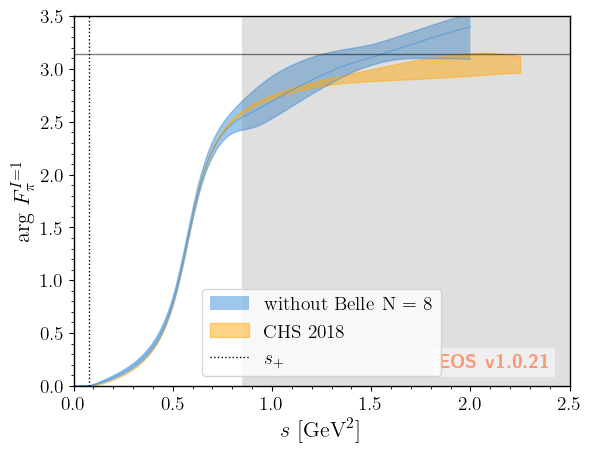

In [122]:
figure_args = {
  'watermark': { 'position': 'lower right' },
  'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [0.0, 2.5] },
    'yaxis': { 'label': r'arg $F^{I=1}_\pi$', 'range': [0.0 , 3.5] },
    'legend': { 'position': 'lower right' },
    'items': [
      { 'type': 'uncertainty', 'label': 'without Belle N = 8', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-FF-arg-fp-I1-timelike', 'color': colors[0]
      },
      { 'type': 'band', 'color': 'gray', 'alpha': 0.25, 'x': [sIn, 2.5], 'y': [0.0, 3.5]},
      { 'type': 'expression', 'expression': 'np.pi', 'range': [0, 2.5], 'color': 'k'}
    ]
  }
}

figure = eos.figure.FigureFactory.from_dict(**figure_args)

q2_over_mpisquared, phase, err = np.loadtxt("scripts/d11-central.txt", skiprows=1, unpack=True)
q2 = q2_over_mpisquared * mpi**2
figure.draw()

ax = figure._ax
ax.fill_between(q2, phase - err, phase + err, label="CHS 2018", alpha=0.5, color=colors[1])

ax.axvline(x=sPlus, color='k', linestyle=':', linewidth=1.0, label=r'$s_+$')

ax.legend(loc="lower center")

In [176]:
get_gof(analysis, start_point)
analysis.parameters.dump('data/'+posterior+'/mode-default/parameters.yaml')

Handling item to plot 0->pipi::Arg{f_+}(Re{psi},Im{psi})@BHKMNR2026 in the complex plane
Overriding parameters from file
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,2)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(0,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(0,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,2)@KSvD2025' with central value '0'
[parameters.override] Overriding existing p

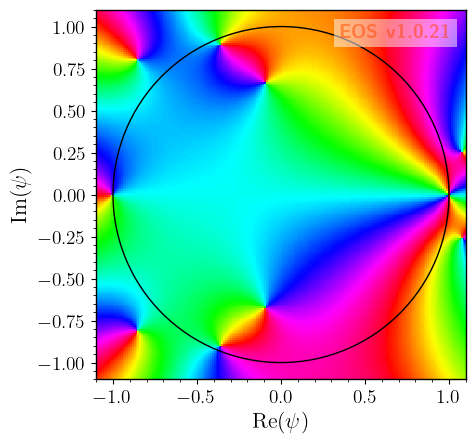

In [ ]:
figure_args = {
'plot': {
    'xaxis': { 'label': r'$\mathrm{Re}(\psi)$', 'range': [-1.1, 1.1] },
    'yaxis': { 'label': r'$\mathrm{Im}(\psi)$', 'range': [-1.1, 1.1] },
    # 'legend': { 'position': 'upper left' },
    'items': [
    { 'type': 'complex-plane','colormap': 'hsv', 'ranges': ((-1.1, +1.1), (-1.1, +1.1)),
        'variables': ["Re{psi}", "Im{psi}"], 'observable': "0->pipi::Arg{f_+}(Re{psi},Im{psi})@BHKMNR2026",
        'fixed_parameters_from_file': 'data/'+posterior+'/mode-default/parameters.yaml', 'resolution': 200
    }
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()
circle = plt.Circle((0, 0), 1.0, color='k', fill=False)
figure._ax.add_patch(circle)
figure._ax.set_aspect("equal", adjustable="box")


In [105]:
eos.tasks.predict_observables(af, posterior, "real-partial-wave-I1", base_directory=BASE_DIRECTORY)
eos.tasks.predict_observables(af, posterior, "imag-partial-wave-I1", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8-wi…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8-wi…

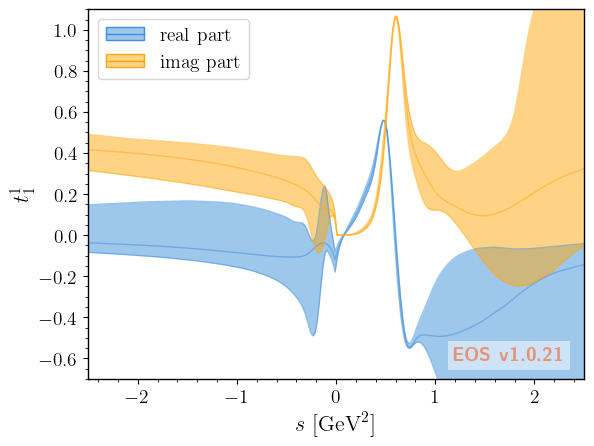

In [106]:
figure_args = {
  'watermark': { 'position': 'lower right' },
  'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [-2.5, 2.5] },
    'yaxis': { 'label': '$t_1^1$', 'range': [-0.7, 1.1]},
    'legend': { 'position': 'upper left' },
    'items': [
      { 'type': 'uncertainty', 'label': 'real part', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-real-partial-wave-I1'
      },
      { 'type': 'uncertainty', 'label': 'imag part', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-imag-partial-wave-I1'
      },
    ]
  }
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

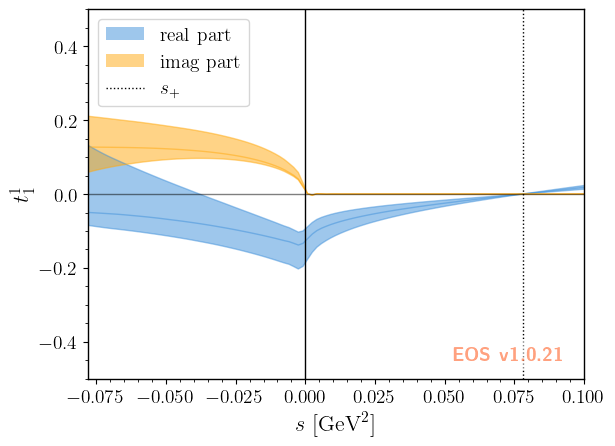

In [107]:
figure_args = {
  'watermark': { 'position': 'lower right' },
  'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [-sPlus, 0.1] },
    'yaxis': { 'label': '$t_1^1$', 'range': [-0.5, 0.5]},
    'legend': { 'position': 'upper left' },
    'items': [
      { 'type': 'uncertainty', 'label': 'real part', 'interpolation': 'cubic', 'resolution': 3000,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-real-partial-wave-I1'
      },
      { 'type': 'uncertainty', 'label': 'imag part', 'interpolation': 'cubic', 'resolution': 3000,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-imag-partial-wave-I1'
      },
      { 'type': 'expression', 'expression': '0', 'range': [-sPlus, 0.1], 'color': 'k'}
    ]
  }
}

figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()
ax = figure._ax
ax.axvline( x=0.0, color='k', linewidth=1.0)
ax.axvline( x=sPlus, color='k', linestyle=':', linewidth=1.0, label=r'$s_+$')
ax.legend(loc='upper left')

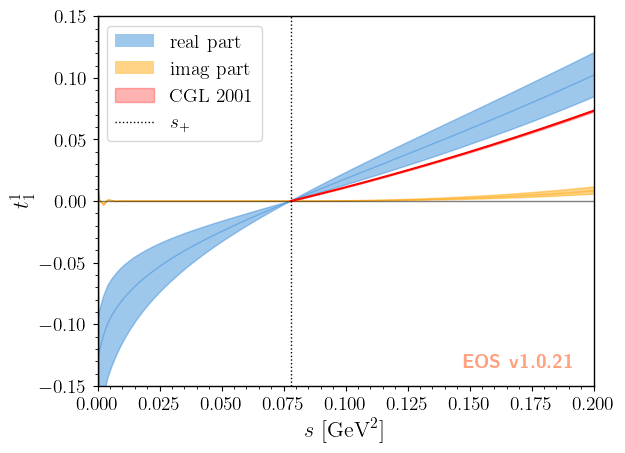

In [109]:
with np.load(theory_path) as saved:
    s_theory = saved['s']
    t_theory_samples = saved['t11']

# Calculate the band; the theory samples have equal weights.
t_lower, t_median, t_upper = np.quantile(
    t_theory_samples,
    [0.15865, 0.5, 0.84135],
    axis=0
)


figure_args = {
  'watermark': { 'position': 'lower right' },
  'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [0, 0.2] },
    'yaxis': { 'label': '$t_1^1$', 'range': [-0.15, 0.15]},
    'legend': { 'position': 'upper left' },
    'items': [
      { 'type': 'uncertainty', 'label': 'real part', 'interpolation': 'cubic', 'resolution': 3000,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-real-partial-wave-I1'
      },
      { 'type': 'uncertainty', 'label': 'imag part', 'interpolation': 'cubic', 'resolution': 3000,
        'variable': 'q2', 'datafile': 'data/'+posterior+'/pred-imag-partial-wave-I1'
      },
      { 'type': 'expression', 'expression': '0', 'range': [0, 0.2], 'color': 'k'}
    ]
  }
}

figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()
ax = figure._ax
# Add the theory band and median to the same axes.
ax.fill_between(
    s_theory,
    t_lower,
    t_upper,
    color='red',
    alpha=0.3,
    label='CGL 2001'
)

ax.plot(
    s_theory,
    t_median,
    color='red',
    linewidth=1.5
)

ax.axvline(x=0.0, color='k', linewidth=1.0)
ax.axvline(
    x=sPlus,
    color='k',
    linestyle=':',
    linewidth=1.0,
    label=r'$s_+$'
)

# Include the theory band and reference line in the legend.
ax.legend(loc='upper left')

In [110]:
# Analytic value of a11 and b11
eos.tasks.predict_observables(af, posterior, "FF-fp-I1-scattering-length-params", base_directory=BASE_DIRECTORY)
sl_params = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-FF-fp-I1-scattering-length-params'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8-wi…

In [111]:
a11_values, b11_values = calculate_sl_values(sl_params)
(a11_mean, a11_std, b11_mean, b11_std) = summarize_sl_values("without Belle N = 8", a11_values, b11_values, sl_params.weights)

without Belle N = 8 a11 = 0.0649 ± 0.0189
without Belle N = 8 b11 = -0.0060 ± 0.0077


In [112]:
sl_samples_path = save_sl_samples(posterior, a11_values, b11_values, sl_params.weights)

Computing KDE for samples of variables 'derived::a11' and 'derived::b11'


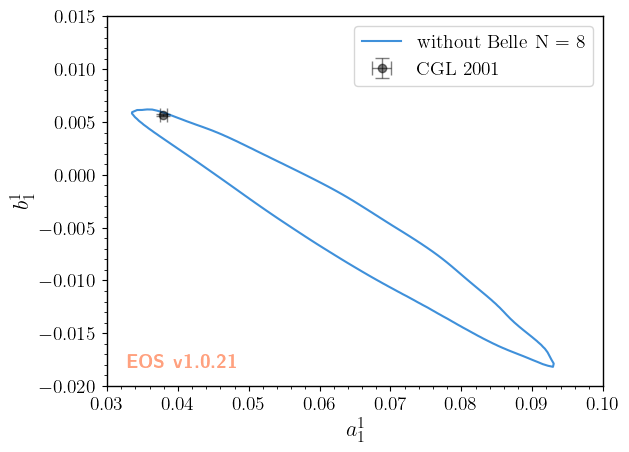

In [114]:
xrange = [0.03, 0.1]
yrange = [-0.02, 0.015]

figure_args = {
'watermark': { 'position': 'lower left' },
'plot': {
    'xaxis': { 'label': r'$a_1^1$', 'range': xrange },
    'yaxis': { 'label': r'$b_1^1$', 'range': yrange },
    'legend': { 'position': 'upper right' },
    'items': [
    { 'type': 'kde2D', 'label': 'without Belle N = 8', 'color': colors[0],
      'levels': [68], 'contours': ['lines'], 'bandwidth': 1.0,
      'datafile': sl_samples_path, 'xrange': xrange, 'yrange': yrange,
      'variables': ['derived::a11', 'derived::b11']
    },
    {'type': 'errorbars', 'positions': [[0.0379, 0.00567]], 'xerrors': [0.0005], 'yerrors': [0.00013], 'label': 'CGL 2001', 'color': 'black'}
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

In [184]:
# Charge radius
eos.tasks.predict_observables(af, posterior, "FF-fp-I1-pion-charge-radius-param", base_directory=BASE_DIRECTORY)
fprime_values = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-FF-fp-I1-pion-charge-radius-param'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8-wi…

In [185]:
charge_radius_squared_values = np.array(list(map(charge_radius_squared_calculator, fprime_values.samples[:, 0])))
radius_mean = np.average(charge_radius_squared_values, weights=fprime_values.weights)
radius_std  = wstd(charge_radius_squared_values, weights=fprime_values.weights)
print(f"<r^2> = {radius_mean:.4f} ± {radius_std:.4f} fm^2")

<r^2> = 0.4372 ± 0.0057 fm^2


In [123]:
# Residue at the rho pole
eos.tasks.predict_observables(af, posterior, "re-rho-residue-psi", base_directory=BASE_DIRECTORY)
re_res_psi = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-re-rho-residue-psi'))
eos.tasks.predict_observables(af, posterior, "im-rho-residue-psi", base_directory=BASE_DIRECTORY)
im_res_psi = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-im-rho-residue-psi'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8-wi…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8-wi…

In [124]:
re_res = re_res_psi.samples[:,0]
im_res = im_res_psi.samples[:,0]
M      = f.samples[:,0]
Gamma  = f.samples[:,1]

print(len(re_res), len(im_res), len(M), len(Gamma)) # check that they have the same length

15571 15571 15571 15571


In [125]:
data = []

for r, i, m, g in zip(re_res, im_res, M, Gamma):
    data.append([r, i, m, g])
with open("residues_psi_wBelle8.wl", "w") as file:
    lines = [f"{{{r}, {i}, {m}, {g}}}" for r, i, m, g in data]
    file.write("{\n" + ",\n".join(lines) + "\n}")

In [ ]:
data = np.loadtxt("residues_s_wBelle8.csv", delimiter=",", ndmin=2,)

res_s = data[:, 0] + 1j * data[:, 1]

# Weighted complex mean
res_s_mean = np.average(res_s, weights=f.weights)

# Weighted standard deviations of the real and imaginary parts
std_re = np.sqrt(np.average((res_s.real - res_s_mean.real)**2, weights=f.weights))
std_im = np.sqrt(np.average((res_s.imag - res_s_mean.imag)**2, weights=f.weights))

print(
    f"residue at s_rho is "
    f"({res_s_mean.real:.4f} ± {std_re:.4f}) "
    f"+ i * ({res_s_mean.imag:.4f} ± {std_im:.4f})"
)

residue at s_rho is (-0.6876 ± 0.0168) + i * (0.1410 ± 0.0271)


In [127]:
# Computing g_{rho pi pi} and g_{rho gamma}
f_at_s_rho       = np.array([get_f_rho(s, analysis) for s in f.samples])
f_at_s_rho_value = f_at_s_rho[:,0] + 1j * f_at_s_rho[:,1]

In [128]:
s_rho       = (M - 1j * Gamma / 2)**2
g_rho_gamma = np.sqrt(24j * np.pi * s_rho / f_at_s_rho_value / res_s / (np.sqrt(1 - sPlus / s_rho))**3)
g_rho_pi_pi = (- res_s / s_rho) * g_rho_gamma

In [129]:
g_rho_gamma_mean = np.average(g_rho_gamma, weights=f.weights)
g_rho_gamma_std  = wstd(g_rho_gamma, weights=f.weights)
print(f"g_rho_gamma =  ({np.real(g_rho_gamma_mean):.4f} ± {np.real(g_rho_gamma_std):.4f}) + i * ({np.imag(g_rho_gamma_mean):.4f} ± {np.imag(g_rho_gamma_std):.4f})")

g_rho_pi_pi_mean = np.average(g_rho_pi_pi, weights=f.weights)
g_rho_pi_pi_std  = wstd(g_rho_pi_pi, weights=f.weights)
print(f"g_rho_pi_pi =  ({np.real(g_rho_pi_pi_mean):.4f} ± {np.real(g_rho_pi_pi_std):.4f}) + i * ({np.imag(g_rho_pi_pi_mean):.4f} ± {np.imag(g_rho_pi_pi_std):.4f})")

g_rho_gamma =  (4.9328 ± 0.0118) + i * (-0.2406 ± 0.0069)
g_rho_pi_pi =  (5.9118 ± 0.0964) + i * (-0.3608 ± 0.2368)


In [130]:
eos.tasks.predict_observables(af, posterior, "a_0", base_directory=BASE_DIRECTORY)
eos.tasks.predict_observables(af, posterior, "a_1", base_directory=BASE_DIRECTORY)
eos.tasks.predict_observables(af, posterior, "a_2", base_directory=BASE_DIRECTORY)
eos.tasks.predict_observables(af, posterior, "a_3", base_directory=BASE_DIRECTORY)

a0 = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-a_0'))
a1 = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-a_1'))
a2 = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-a_2'))
a3 = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', posterior, 'pred-a_3'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8-wi…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8-wi…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8-wi…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8-wi…

In [131]:
all_coefs = np.column_stack([a0.samples, a1.samples, a2.samples, a3.samples,
                                                     f.samples[:,2], f.samples[:,3], f.samples[:,4], f.samples[:,5], f.samples[:,6]])
np.shape(all_coefs)

(15571, 9)

In [132]:
# Compute weighted median and asymmetric 1-sigma intervals for each coefficient
n_coefs = all_coefs.shape[1]
labels = [f'$a_{i}$' for i in range(n_coefs)]

medians   = np.array([quantile_1D(all_coefs[:,i], f.weights, 0.50) for i in range(n_coefs)])
lo_1sigma = np.array([quantile_1D(all_coefs[:,i], f.weights, 0.16) for i in range(n_coefs)])
hi_1sigma = np.array([quantile_1D(all_coefs[:,i], f.weights, 0.84) for i in range(n_coefs)])

err_low  = medians - lo_1sigma   # downward bar length
err_high = hi_1sigma - medians   # upward bar length


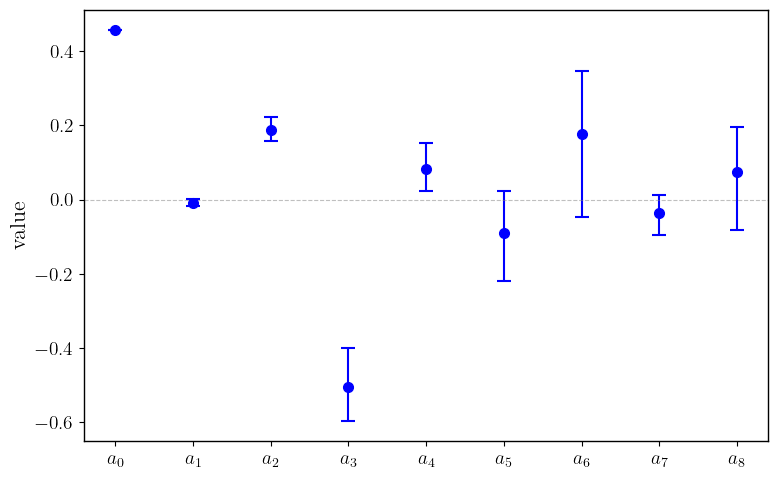

In [133]:
fig, ax = plt.subplots(figsize=(8, 5))
xs = np.arange(n_coefs)

ax.errorbar(xs, medians,
            yerr=[err_low, err_high],
            fmt='o', capsize=5, capthick=1.5, elinewidth=1.5,
            markersize=7, color='b', ecolor='b')

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xticks(xs)
ax.set_xticklabels(labels)
ax.set_ylabel('value')
plt.tight_layout()
plt.show()